In [4]:
from __future__ import annotations

import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

PIPELINE_VERSION = "notebook7_cell1_validate_baseline_handoffs_v2"
DOLLAR_YEAR = 2022
AGGREGATE_ATOL_USD = 0.01
EXPECTED_TAIL_WARNING_IDS = {
    "extreme_return_period_tail_support_documented",
    "extreme_return_period_tail_support_carried_forward",
}
HEADLINE_RETURN_PERIODS = [100, 250, 500, 1000, 2500, 5000, 10000]


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "07_baseline_results_and_validation.ipynb").exists():
            return candidate
        if (
            candidate
            / "data"
            / "metadata"
            / "notebook_6_insurance_terms"
            / "notebook_6_final_handoff.json"
        ).exists():
            return candidate
    raise FileNotFoundError(
        "Could not identify the project root. Run Notebook 7 from the "
        "seismic-correlation-insurance-loss repository."
    )


def load_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(
        json.dumps(payload, indent=2, sort_keys=True),
        encoding="utf-8",
    )
    temporary.replace(path)


def sha256_file(path: Path, chunk_bytes: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while block := handle.read(chunk_bytes):
            digest.update(block)
    return digest.hexdigest()


def resolve_recorded_path(project_root: Path, recorded_path: str | Path) -> Path:
    direct = Path(recorded_path)
    if direct.exists():
        return direct

    normalized = str(recorded_path).replace("\\", "/")
    marker = "/data/"
    position = normalized.lower().find(marker)
    if position >= 0:
        candidate = project_root / Path(normalized[position + 1 :])
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Recorded path does not exist: {recorded_path}")


def parse_bool_series(values: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(values):
        return values.fillna(False).astype(bool)

    normalized = values.astype(str).str.strip().str.lower()
    mapping = {
        "true": True,
        "1": True,
        "yes": True,
        "pass": True,
        "passed": True,
        "false": False,
        "0": False,
        "no": False,
        "fail": False,
        "failed": False,
    }
    parsed = normalized.map(mapping)
    if parsed.isna().any():
        bad = sorted(normalized.loc[parsed.isna()].unique().tolist())
        raise ValueError(f"Unrecognized Boolean values: {bad}")
    return parsed.astype(bool)


def append_check(
    rows: list[dict[str, Any]],
    check_id: str,
    passed: bool,
    detail: str,
    severity: str = "critical",
) -> None:
    rows.append(
        {
            "check_id": check_id,
            "severity": severity,
            "passed": bool(passed),
            "detail": detail,
        }
    )


def inspect_validation(
    path: Path,
    allowed_warning_ids: set[str] | None = None,
) -> dict[str, Any]:
    table = pd.read_csv(path)
    required = {"check_id", "severity", "passed", "detail"}
    missing = sorted(required.difference(table.columns))
    if missing:
        raise KeyError(f"Validation file {path} is missing columns: {missing}")

    table["passed"] = parse_bool_series(table["passed"])
    severity = table["severity"].astype(str).str.strip().str.lower()
    critical_failures = table.loc[severity.eq("critical") & ~table["passed"]].copy()
    warnings = table.loc[severity.eq("warning") & ~table["passed"]].copy()
    allowed = allowed_warning_ids or set()
    warning_ids = set(warnings["check_id"].astype(str).tolist())

    return {
        "critical_failures": critical_failures,
        "warnings": warnings,
        "unexpected_warning_ids": sorted(warning_ids.difference(allowed)),
        "critical_checks": int(severity.eq("critical").sum()),
    }


def validate_recorded_output(
    project_root: Path,
    record: dict[str, Any],
) -> tuple[Path, bool, str]:
    path = resolve_recorded_path(project_root, record["path"])
    expected_hash = str(record.get("sha256", "")).strip().lower()
    actual_hash = sha256_file(path)
    passed = len(expected_hash) == 64 and actual_hash == expected_hash
    detail = (
        f"path={path}; expected_sha256={expected_hash}; "
        f"actual_sha256={actual_hash}"
    )
    return path, passed, detail


def ensure_numeric(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        frame[column] = pd.to_numeric(frame[column], errors="raise")


def monotonic_non_decreasing(values: pd.Series, tolerance: float = 0.01) -> bool:
    array = values.to_numpy(dtype=np.float64)
    return bool(np.all(np.diff(array) >= -tolerance))


PROJECT_ROOT = find_project_root()
NB5_METADATA_DIR = PROJECT_ROOT / "data" / "metadata" / "notebook_5_damage_loss"
NB6_METADATA_DIR = PROJECT_ROOT / "data" / "metadata" / "notebook_6_insurance_terms"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "notebook_7_baseline_results_validation"
METADATA_DIR = PROJECT_ROOT / "data" / "metadata" / "notebook_7_baseline_results_validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

NB5_SUMMARY_PATH = NB5_METADATA_DIR / "notebook_5_cell_12_summary.json"
NB5_VALIDATION_PATH = NB5_METADATA_DIR / "notebook_5_cell_12_validation.csv"
NB6_HANDOFF_PATH = NB6_METADATA_DIR / "notebook_6_final_handoff.json"
NB6_SUMMARY_PATH = NB6_METADATA_DIR / "notebook_6_cell_8_summary.json"
NB6_VALIDATION_PATH = NB6_METADATA_DIR / "notebook_6_cell_8_validation.csv"

HEADLINE_METRICS_PATH = OUTPUT_DIR / "notebook_7_baseline_headline_metrics.csv"
LOSS_FLOW_PATH = OUTPUT_DIR / "notebook_7_baseline_loss_flow.csv"
HEADLINE_PML_PATH = OUTPUT_DIR / "notebook_7_baseline_headline_pml.csv"
ASSUMPTIONS_PATH = OUTPUT_DIR / "notebook_7_baseline_model_assumptions.csv"
INPUT_MANIFEST_PATH = OUTPUT_DIR / "notebook_7_baseline_input_manifest.csv"
VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_1_validation.csv"
SUMMARY_PATH = METADATA_DIR / "notebook_7_cell_1_summary.json"
INPUT_HANDOFF_PATH = METADATA_DIR / "notebook_7_input_handoff.json"

validation_rows: list[dict[str, Any]] = []

for check_id, path in [
    ("notebook5_cell12_summary_exists", NB5_SUMMARY_PATH),
    ("notebook5_cell12_validation_exists", NB5_VALIDATION_PATH),
    ("notebook6_final_handoff_exists", NB6_HANDOFF_PATH),
    ("notebook6_cell8_summary_exists", NB6_SUMMARY_PATH),
    ("notebook6_cell8_validation_exists", NB6_VALIDATION_PATH),
]:
    append_check(
        validation_rows,
        check_id,
        path.exists() and path.stat().st_size > 0,
        str(path),
    )

nb5_summary = load_json(NB5_SUMMARY_PATH)
nb6_handoff = load_json(NB6_HANDOFF_PATH)
nb6_summary = load_json(NB6_SUMMARY_PATH)

append_check(
    validation_rows,
    "notebook5_cell12_summary_reports_critical_success",
    bool(nb5_summary.get("all_critical_checks_passed", False)),
    f"pipeline_version={nb5_summary.get('pipeline_version')}",
)
append_check(
    validation_rows,
    "notebook6_cell8_summary_reports_critical_success",
    bool(nb6_summary.get("all_critical_checks_passed", False)),
    f"pipeline_version={nb6_summary.get('pipeline_version')}",
)
append_check(
    validation_rows,
    "notebook6_final_handoff_status_complete",
    str(nb6_handoff.get("status", "")).strip().lower() == "complete",
    f"status={nb6_handoff.get('status')}",
)

for name, path in [
    ("notebook5_cell12", NB5_VALIDATION_PATH),
    ("notebook6_cell8", NB6_VALIDATION_PATH),
]:
    inspected = inspect_validation(
        path,
        allowed_warning_ids=EXPECTED_TAIL_WARNING_IDS,
    )
    append_check(
        validation_rows,
        f"{name}_has_no_critical_failures",
        inspected["critical_failures"].empty,
        (
            f"critical_checks={inspected['critical_checks']}; "
            f"critical_failures={len(inspected['critical_failures'])}"
        ),
    )
    append_check(
        validation_rows,
        f"{name}_has_no_unexpected_warnings",
        len(inspected["unexpected_warning_ids"]) == 0,
        f"unexpected_warning_ids={inspected['unexpected_warning_ids']}",
    )

append_check(
    validation_rows,
    "project_phase_is_no_spatial_correlation_baseline",
    nb6_handoff.get("project", {}).get("phase")
    == "phase_1_no_spatial_correlation_baseline",
    f"phase={nb6_handoff.get('project', {}).get('phase')}",
)
append_check(
    validation_rows,
    "dollar_year_is_2022",
    int(nb6_handoff.get("project", {}).get("dollar_year", -1)) == DOLLAR_YEAR,
    f"dollar_year={nb6_handoff.get('project', {}).get('dollar_year')}",
)

resolved_final_outputs: dict[str, Path] = {}
for output_name in [
    "loss_flow_summary",
    "pml_comparison",
    "headline_pml_table",
    "model_assumptions",
    "output_manifest",
]:
    record = nb6_handoff["final_outputs"][output_name]
    path, passed, detail = validate_recorded_output(PROJECT_ROOT, record)
    resolved_final_outputs[output_name] = path
    append_check(
        validation_rows,
        f"notebook6_{output_name}_hash_matches_handoff",
        passed,
        detail,
    )

source_manifest = pd.read_csv(resolved_final_outputs["output_manifest"])
required_manifest_columns = {
    "category",
    "output_name",
    "source_cell",
    "path",
    "exists",
    "size_bytes",
    "sha256",
}
append_check(
    validation_rows,
    "notebook6_output_manifest_schema_complete",
    required_manifest_columns.issubset(source_manifest.columns),
    f"missing={sorted(required_manifest_columns.difference(source_manifest.columns))}",
)

manifest_audit_rows: list[dict[str, Any]] = []
for row in source_manifest.to_dict(orient="records"):
    resolved = resolve_recorded_path(PROJECT_ROOT, row["path"])
    actual_hash = sha256_file(resolved)
    expected_hash = str(row["sha256"]).strip().lower()
    size_bytes = int(resolved.stat().st_size)
    manifest_audit_rows.append(
        {
            "category": row["category"],
            "output_name": row["output_name"],
            "source_cell": row["source_cell"],
            "source_path": str(resolved),
            "size_bytes": size_bytes,
            "expected_sha256": expected_hash,
            "actual_sha256": actual_hash,
            "hash_matches": actual_hash == expected_hash,
            "source_rows": row.get("rows"),
        }
    )

input_manifest = pd.DataFrame(manifest_audit_rows)
input_manifest.to_csv(INPUT_MANIFEST_PATH, index=False)
append_check(
    validation_rows,
    "all_notebook6_manifest_hashes_reproduced",
    input_manifest["hash_matches"].astype(bool).all(),
    (
        "mismatched="
        f"{input_manifest.loc[~input_manifest['hash_matches'], 'source_path'].tolist()}"
    ),
)
append_check(
    validation_rows,
    "all_notebook6_manifest_files_nonempty",
    (input_manifest["size_bytes"].astype(np.int64) > 0).all(),
    f"manifest_rows={len(input_manifest)}",
)

loss_flow = pd.read_csv(resolved_final_outputs["loss_flow_summary"])
pml_comparison = pd.read_csv(resolved_final_outputs["pml_comparison"])
headline_pml = pd.read_csv(resolved_final_outputs["headline_pml_table"])
assumptions = pd.read_csv(resolved_final_outputs["model_assumptions"])

required_loss_flow_columns = {
    "stage_order",
    "loss_measure",
    "aal_2022_usd",
    "share_of_ground_up_aal",
    "share_of_gross_insured_aal",
    "maximum_aep_loss_2022_usd",
    "maximum_oep_loss_2022_usd",
}
required_pml_columns = {
    "return_period_years",
    "ground_up_aep_pml_2022_usd",
    "gross_insured_aep_pml_2022_usd",
    "uninsured_aep_pml_2022_usd",
    "ceded_aep_pml_2022_usd",
    "net_retained_aep_pml_2022_usd",
    "ground_up_oep_pml_2022_usd",
    "gross_insured_oep_pml_2022_usd",
    "uninsured_oep_pml_2022_usd",
    "ceded_oep_pml_2022_usd",
    "net_retained_oep_pml_2022_usd",
    "minimum_supporting_descending_rank",
    "tail_support_flag",
}
append_check(
    validation_rows,
    "loss_flow_schema_complete",
    required_loss_flow_columns.issubset(loss_flow.columns),
    f"missing={sorted(required_loss_flow_columns.difference(loss_flow.columns))}",
)
append_check(
    validation_rows,
    "pml_comparison_schema_complete",
    required_pml_columns.issubset(pml_comparison.columns),
    f"missing={sorted(required_pml_columns.difference(pml_comparison.columns))}",
)
append_check(
    validation_rows,
    "headline_pml_schema_complete",
    required_pml_columns.issubset(headline_pml.columns),
    f"missing={sorted(required_pml_columns.difference(headline_pml.columns))}",
)
append_check(
    validation_rows,
    "assumption_registry_nonempty",
    len(assumptions) > 0,
    f"rows={len(assumptions)}",
)

loss_flow_numeric = [
    "stage_order",
    "aal_2022_usd",
    "share_of_ground_up_aal",
    "share_of_gross_insured_aal",
    "maximum_aep_loss_2022_usd",
    "maximum_oep_loss_2022_usd",
]
ensure_numeric(loss_flow, loss_flow_numeric)

pml_numeric = [
    column
    for column in pml_comparison.columns
    if column.endswith("_2022_usd")
    or column.endswith("_share_aep")
    or column.endswith("_share_oep")
    or column.startswith("layer_limit_utilization")
    or column in {
        "return_period_years",
        "target_annual_exceedance_probability",
        "minimum_supporting_descending_rank",
    }
]
ensure_numeric(pml_comparison, pml_numeric)
ensure_numeric(headline_pml, [column for column in pml_numeric if column in headline_pml])

expected_loss_measures = {
    "ground_up",
    "uninsured",
    "gross_insured",
    "ceded",
    "net_retained",
}
append_check(
    validation_rows,
    "loss_flow_measures_complete",
    set(loss_flow["loss_measure"].astype(str)) == expected_loss_measures,
    f"loss_measures={loss_flow['loss_measure'].tolist()}",
)
append_check(
    validation_rows,
    "loss_flow_measure_rows_unique",
    not loss_flow["loss_measure"].duplicated().any(),
    f"rows={len(loss_flow)}",
)

loss_flow_indexed = loss_flow.set_index("loss_measure")
ground_up_aal = float(loss_flow_indexed.loc["ground_up", "aal_2022_usd"])
gross_aal = float(loss_flow_indexed.loc["gross_insured", "aal_2022_usd"])
uninsured_aal = float(loss_flow_indexed.loc["uninsured", "aal_2022_usd"])
ceded_aal = float(loss_flow_indexed.loc["ceded", "aal_2022_usd"])
retained_aal = float(loss_flow_indexed.loc["net_retained", "aal_2022_usd"])

append_check(
    validation_rows,
    "ground_up_aal_conserves_to_gross_and_uninsured",
    abs(ground_up_aal - gross_aal - uninsured_aal) <= AGGREGATE_ATOL_USD,
    f"difference={ground_up_aal - gross_aal - uninsured_aal:.6f}",
)
append_check(
    validation_rows,
    "gross_insured_aal_conserves_to_ceded_and_retained",
    abs(gross_aal - ceded_aal - retained_aal) <= AGGREGATE_ATOL_USD,
    f"difference={gross_aal - ceded_aal - retained_aal:.6f}",
)
append_check(
    validation_rows,
    "all_aal_measures_positive",
    min(ground_up_aal, gross_aal, uninsured_aal, ceded_aal, retained_aal) > 0.0,
    (
        f"ground_up={ground_up_aal:.6f}; gross={gross_aal:.6f}; "
        f"uninsured={uninsured_aal:.6f}; ceded={ceded_aal:.6f}; "
        f"retained={retained_aal:.6f}"
    ),
)

handoff_aal = nb6_handoff["aal_2022_usd"]
for measure, value in [
    ("ground_up", ground_up_aal),
    ("gross_insured", gross_aal),
    ("uninsured", uninsured_aal),
    ("ceded", ceded_aal),
    ("net_retained", retained_aal),
]:
    expected = float(handoff_aal[measure])
    append_check(
        validation_rows,
        f"{measure}_aal_matches_notebook6_handoff",
        abs(value - expected) <= AGGREGATE_ATOL_USD,
        f"table={value:.6f}; handoff={expected:.6f}; difference={value - expected:.6f}",
    )

pml_comparison = pml_comparison.sort_values("return_period_years").reset_index(drop=True)
headline_pml = headline_pml.sort_values("return_period_years").reset_index(drop=True)
append_check(
    validation_rows,
    "headline_return_periods_complete",
    headline_pml["return_period_years"].astype(int).tolist()
    == HEADLINE_RETURN_PERIODS,
    f"return_periods={headline_pml['return_period_years'].astype(int).tolist()}",
)
append_check(
    validation_rows,
    "headline_return_periods_have_adequate_tail_support",
    headline_pml["minimum_supporting_descending_rank"].ge(20).all()
    and headline_pml["tail_support_flag"].eq(
        "adequate_order_statistic_support"
    ).all(),
    (
        "minimum_rank="
        f"{int(headline_pml['minimum_supporting_descending_rank'].min())}"
    ),
)

pml_loss_columns = [
    column for column in required_pml_columns if column.endswith("_2022_usd")
]
append_check(
    validation_rows,
    "all_pml_values_nonnegative",
    (pml_comparison[pml_loss_columns] >= 0.0).all().all(),
    f"minimum={float(pml_comparison[pml_loss_columns].min().min()):.6f}",
)
for column in sorted(pml_loss_columns):
    append_check(
        validation_rows,
        f"{column}_nondecreasing_with_return_period",
        monotonic_non_decreasing(pml_comparison[column]),
        (
            f"minimum_step="
            f"{float(pml_comparison[column].diff().dropna().min()):.6f}"
        ),
    )

for curve_type in ["aep", "oep"]:
    ground = pml_comparison[f"ground_up_{curve_type}_pml_2022_usd"]
    gross = pml_comparison[f"gross_insured_{curve_type}_pml_2022_usd"]
    uninsured = pml_comparison[f"uninsured_{curve_type}_pml_2022_usd"]
    ceded = pml_comparison[f"ceded_{curve_type}_pml_2022_usd"]
    retained = pml_comparison[f"net_retained_{curve_type}_pml_2022_usd"]
    append_check(
        validation_rows,
        f"{curve_type}_pml_loss_ordering_bounded",
        (
            (gross <= ground + AGGREGATE_ATOL_USD).all()
            and (uninsured <= ground + AGGREGATE_ATOL_USD).all()
            and (ceded <= gross + AGGREGATE_ATOL_USD).all()
            and (retained <= gross + AGGREGATE_ATOL_USD).all()
        ),
        "gross,uninsured<=ground_up and ceded,retained<=gross_insured",
    )

thin_tail_periods = pml_comparison.loc[
    pml_comparison["tail_support_flag"].eq("thin_tail_support"),
    "return_period_years",
].astype(int).tolist()
append_check(
    validation_rows,
    "thin_tail_return_periods_carried_forward",
    thin_tail_periods == [200000, 500000, 1000000, 2000000],
    f"thin_tail_return_periods={thin_tail_periods}",
    severity="warning",
)

loss_flow.sort_values("stage_order").to_csv(LOSS_FLOW_PATH, index=False)
headline_pml.to_csv(HEADLINE_PML_PATH, index=False)
assumptions.to_csv(ASSUMPTIONS_PATH, index=False)

annual_catalog = nb6_handoff["annual_catalog"]
portfolio = nb6_handoff["portfolio"]
policy = nb6_handoff["policy_scenario"]
layer = nb6_handoff["reinsurance_scenario"]
shares = nb6_handoff["aal_shares"]
maximum_losses = nb6_handoff["maximum_annual_losses_2022_usd"]

headline_metrics = pd.DataFrame(
    [
        {
            "metric_group": "portfolio",
            "metric": "portfolio_buildings",
            "value": int(portfolio["buildings"]),
            "unit": "buildings",
            "description": "Buildings in the Seaside W2 portfolio",
        },
        {
            "metric_group": "portfolio",
            "metric": "portfolio_replacement_value",
            "value": float(portfolio["replacement_value_2022_usd"]),
            "unit": "2022 USD",
            "description": "Total modeled building replacement value",
        },
        {
            "metric_group": "catalog",
            "metric": "catalog_years",
            "value": int(annual_catalog["declared_duration_years"]),
            "unit": "years",
            "description": "Annual stochastic catalog duration",
        },
        {
            "metric_group": "catalog",
            "metric": "catalog_occurrences",
            "value": int(annual_catalog["occurrences"]),
            "unit": "occurrences",
            "description": "Earthquake occurrences in the catalog",
        },
        {
            "metric_group": "catalog",
            "metric": "occupied_years",
            "value": int(annual_catalog["occupied_years"]),
            "unit": "years",
            "description": "Catalog years containing at least one occurrence",
        },
        {
            "metric_group": "catalog",
            "metric": "multiple_event_years",
            "value": int(annual_catalog["multiple_event_years"]),
            "unit": "years",
            "description": "Catalog years containing multiple occurrences",
        },
        {
            "metric_group": "aal",
            "metric": "ground_up_aal",
            "value": ground_up_aal,
            "unit": "2022 USD/year",
            "description": "Average annual total repair loss before insurance",
        },
        {
            "metric_group": "aal",
            "metric": "gross_insured_aal",
            "value": gross_aal,
            "unit": "2022 USD/year",
            "description": "Average annual insurer liability before reinsurance",
        },
        {
            "metric_group": "aal",
            "metric": "uninsured_aal",
            "value": uninsured_aal,
            "unit": "2022 USD/year",
            "description": "Average annual loss not recovered under the policy",
        },
        {
            "metric_group": "aal",
            "metric": "ceded_aal",
            "value": ceded_aal,
            "unit": "2022 USD/year",
            "description": "Average annual loss transferred to the XoL layer",
        },
        {
            "metric_group": "aal",
            "metric": "net_retained_aal",
            "value": retained_aal,
            "unit": "2022 USD/year",
            "description": "Average annual insurer loss after reinsurance",
        },
        {
            "metric_group": "shares",
            "metric": "insurance_recovery_share_of_ground_up",
            "value": float(shares["insurance_recovery_share_of_ground_up"]),
            "unit": "fraction",
            "description": "Gross insured AAL divided by ground-up AAL",
        },
        {
            "metric_group": "shares",
            "metric": "ceded_share_of_gross_insured",
            "value": float(shares["ceded_share_of_gross_insured"]),
            "unit": "fraction",
            "description": "Ceded AAL divided by gross insured AAL",
        },
        {
            "metric_group": "policy",
            "metric": "building_deductible_share",
            "value": float(policy["deductible_percent_of_replacement_value"]),
            "unit": "fraction of replacement value",
            "description": "Synthetic per-building, per-occurrence deductible",
        },
        {
            "metric_group": "reinsurance",
            "metric": "xol_attachment",
            "value": float(layer["attachment_2022_usd"]),
            "unit": "2022 USD",
            "description": "500-year gross insured OEP attachment",
        },
        {
            "metric_group": "reinsurance",
            "metric": "xol_limit",
            "value": float(layer["limit_2022_usd"]),
            "unit": "2022 USD",
            "description": "Occurrence XoL layer limit",
        },
        {
            "metric_group": "reinsurance",
            "metric": "xol_exhaustion",
            "value": float(layer["exhaustion_2022_usd"]),
            "unit": "2022 USD",
            "description": "2,500-year gross insured OEP exhaustion",
        },
        {
            "metric_group": "maximum_loss",
            "metric": "maximum_ground_up_aep",
            "value": float(maximum_losses["ground_up_aep"]),
            "unit": "2022 USD",
            "description": "Maximum annual aggregate ground-up loss",
        },
        {
            "metric_group": "maximum_loss",
            "metric": "maximum_gross_insured_aep",
            "value": float(maximum_losses["gross_insured_aep"]),
            "unit": "2022 USD",
            "description": "Maximum annual aggregate gross insured loss",
        },
        {
            "metric_group": "maximum_loss",
            "metric": "maximum_ceded_aep",
            "value": float(maximum_losses["ceded_aep"]),
            "unit": "2022 USD",
            "description": "Maximum annual aggregate ceded loss",
        },
        {
            "metric_group": "maximum_loss",
            "metric": "maximum_net_retained_aep",
            "value": float(maximum_losses["net_retained_aep"]),
            "unit": "2022 USD",
            "description": "Maximum annual aggregate net retained loss",
        },
    ]
)
headline_metrics.to_csv(HEADLINE_METRICS_PATH, index=False)

for output_path, check_id in [
    (HEADLINE_METRICS_PATH, "headline_metrics_output_exists"),
    (LOSS_FLOW_PATH, "loss_flow_output_exists"),
    (HEADLINE_PML_PATH, "headline_pml_output_exists"),
    (ASSUMPTIONS_PATH, "assumptions_output_exists"),
    (INPUT_MANIFEST_PATH, "input_manifest_output_exists"),
]:
    append_check(
        validation_rows,
        check_id,
        output_path.exists() and output_path.stat().st_size > 0,
        str(output_path),
    )

reporting_outputs = {
    "headline_metrics": HEADLINE_METRICS_PATH,
    "loss_flow": LOSS_FLOW_PATH,
    "headline_pml": HEADLINE_PML_PATH,
    "model_assumptions": ASSUMPTIONS_PATH,
    "input_manifest": INPUT_MANIFEST_PATH,
}

input_handoff = {
    "pipeline_version": PIPELINE_VERSION,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "status": "complete",
    "project": {
        "name": "seismic-correlation-insurance-loss",
        "phase": "phase_1_no_spatial_correlation_baseline",
        "notebook": "07_baseline_results_and_validation.ipynb",
        "scope": "validated baseline results and reporting dataset assembly",
        "currency": "USD",
        "dollar_year": DOLLAR_YEAR,
    },
    "source_handoffs": {
        "notebook_5_cell_12_summary": {
            "path": str(NB5_SUMMARY_PATH),
            "sha256": sha256_file(NB5_SUMMARY_PATH),
        },
        "notebook_6_final_handoff": {
            "path": str(NB6_HANDOFF_PATH),
            "sha256": sha256_file(NB6_HANDOFF_PATH),
        },
        "notebook_6_cell_8_summary": {
            "path": str(NB6_SUMMARY_PATH),
            "sha256": sha256_file(NB6_SUMMARY_PATH),
        },
    },
    "annual_catalog": annual_catalog,
    "portfolio": portfolio,
    "policy_scenario": policy,
    "reinsurance_scenario": layer,
    "aal_2022_usd": handoff_aal,
    "aal_shares": shares,
    "maximum_annual_losses_2022_usd": maximum_losses,
    "headline_return_periods_years": HEADLINE_RETURN_PERIODS,
    "thin_tail_return_periods_years": thin_tail_periods,
    "reporting_outputs": {
        name: {
            "path": str(path),
            "sha256": sha256_file(path),
            "rows": int(len(pd.read_csv(path))),
        }
        for name, path in reporting_outputs.items()
    },
    "next_stage": (
        "Create portfolio, AAL, exceedance-curve, PML, and reinsurance figures "
        "from the validated reporting tables."
    ),
}
write_json(INPUT_HANDOFF_PATH, input_handoff)

append_check(
    validation_rows,
    "input_handoff_output_exists",
    INPUT_HANDOFF_PATH.exists() and INPUT_HANDOFF_PATH.stat().st_size > 0,
    str(INPUT_HANDOFF_PATH),
)

validation = pd.DataFrame(validation_rows)
critical_failures = validation.loc[
    validation["severity"].astype(str).str.lower().eq("critical")
    & ~validation["passed"]
].copy()
warning_failures = validation.loc[
    validation["severity"].astype(str).str.lower().eq("warning")
    & ~validation["passed"]
].copy()
validation.to_csv(VALIDATION_PATH, index=False)

summary = {
    "pipeline_version": PIPELINE_VERSION,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "all_critical_checks_passed": critical_failures.empty,
    "annual_catalog": annual_catalog,
    "portfolio": portfolio,
    "policy_scenario_id": policy["policy_scenario_id"],
    "reinsurance_scenario_id": layer["layer_scenario_id"],
    "aal_2022_usd": handoff_aal,
    "aal_shares": shares,
    "headline_return_periods_years": HEADLINE_RETURN_PERIODS,
    "thin_tail_return_periods_years": thin_tail_periods,
    "outputs": {
        **{
            name: {
                "path": str(path),
                "sha256": sha256_file(path),
                "rows": int(len(pd.read_csv(path))),
            }
            for name, path in reporting_outputs.items()
        },
        "input_handoff": {
            "path": str(INPUT_HANDOFF_PATH),
            "sha256": sha256_file(INPUT_HANDOFF_PATH),
        },
        "validation": str(VALIDATION_PATH),
        "summary": str(SUMMARY_PATH),
    },
    "validation": {
        "critical_checks": int(
            validation["severity"].astype(str).str.lower().eq("critical").sum()
        ),
        "critical_failures": critical_failures.to_dict(orient="records"),
        "warnings": warning_failures.to_dict(orient="records"),
    },
    "notebook_status": "ready_for_reporting" if critical_failures.empty else "failed",
    "next_stage": input_handoff["next_stage"],
}
write_json(SUMMARY_PATH, summary)

if not critical_failures.empty:
    raise RuntimeError(
        "Notebook 7 Cell 1 failed critical validation. Review "
        f"{VALIDATION_PATH}."
    )

print()
print("=" * 78)
print("NOTEBOOK 7 CELL 1 BASELINE HANDOFF VALIDATION COMPLETE")
print("=" * 78)
print(f"Policy scenario:                 {policy['policy_scenario_id']}")
print(f"Reinsurance scenario:            {layer['layer_scenario_id']}")
print(f"Declared catalog years:          {int(annual_catalog['declared_duration_years']):,}")
print(f"Catalog occurrences:             {int(annual_catalog['occurrences']):,}")
print(f"Portfolio buildings:             {int(portfolio['buildings']):,}")
print(f"Portfolio replacement value:     ${float(portfolio['replacement_value_2022_usd']):,.0f}")
print(f"Ground-up AAL:                   ${ground_up_aal:,.2f}")
print(f"Gross insured AAL:               ${gross_aal:,.2f}")
print(f"Uninsured AAL:                   ${uninsured_aal:,.2f}")
print(f"Ceded AAL:                       ${ceded_aal:,.2f}")
print(f"Net retained AAL:                ${retained_aal:,.2f}")
print(f"Headline return periods:         {HEADLINE_RETURN_PERIODS}")
print(f"Validated source outputs:        {len(input_manifest):,}")
print(
    f"Critical validation checks:      "
    f"{int(validation['severity'].astype(str).str.lower().eq('critical').sum()):,}"
)
print(f"Critical failures:               {len(critical_failures):,}")
print(f"Warnings requiring review:       {len(warning_failures):,}")
print()
print("Headline metrics:")
print(f"  {HEADLINE_METRICS_PATH}")
print("Headline PML table:")
print(f"  {HEADLINE_PML_PATH}")
print("Input manifest:")
print(f"  {INPUT_MANIFEST_PATH}")
print("Notebook 7 input handoff:")
print(f"  {INPUT_HANDOFF_PATH}")
print("Validation:")
print(f"  {VALIDATION_PATH}")
print("Summary:")
print(f"  {SUMMARY_PATH}")
print()
print("Next: create the baseline portfolio and catastrophe-risk overview figures.")



NOTEBOOK 7 CELL 1 BASELINE HANDOFF VALIDATION COMPLETE
Policy scenario:                 baseline_full_coverage_10pct_deductible_v1
Reinsurance scenario:            baseline_occurrence_xol_500yr_to_2500yr_oep_v1
Declared catalog years:          2,000,000
Catalog occurrences:             10,630
Portfolio buildings:             470
Portfolio replacement value:     $384,236,605
Ground-up AAL:                   $195,922.45
Gross insured AAL:               $122,979.56
Uninsured AAL:                   $72,942.89
Ceded AAL:                       $63,676.60
Net retained AAL:                $59,302.96
Headline return periods:         [100, 250, 500, 1000, 2500, 5000, 10000]
Validated source outputs:        23
Critical validation checks:      57
Critical failures:               0
Warnings requiring review:       0

Headline metrics:
  c:\Users\USER\Documents\GitHub\seismic-correlation-insurance-loss\data\processed\notebook_7_baseline_results_validation\notebook_7_baseline_headline_metrics.csv
He

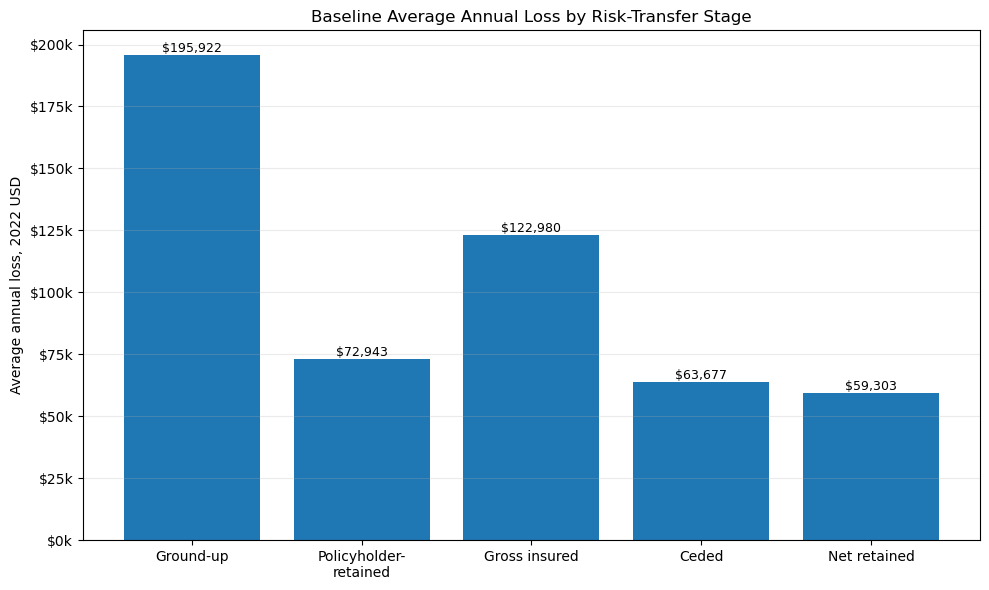

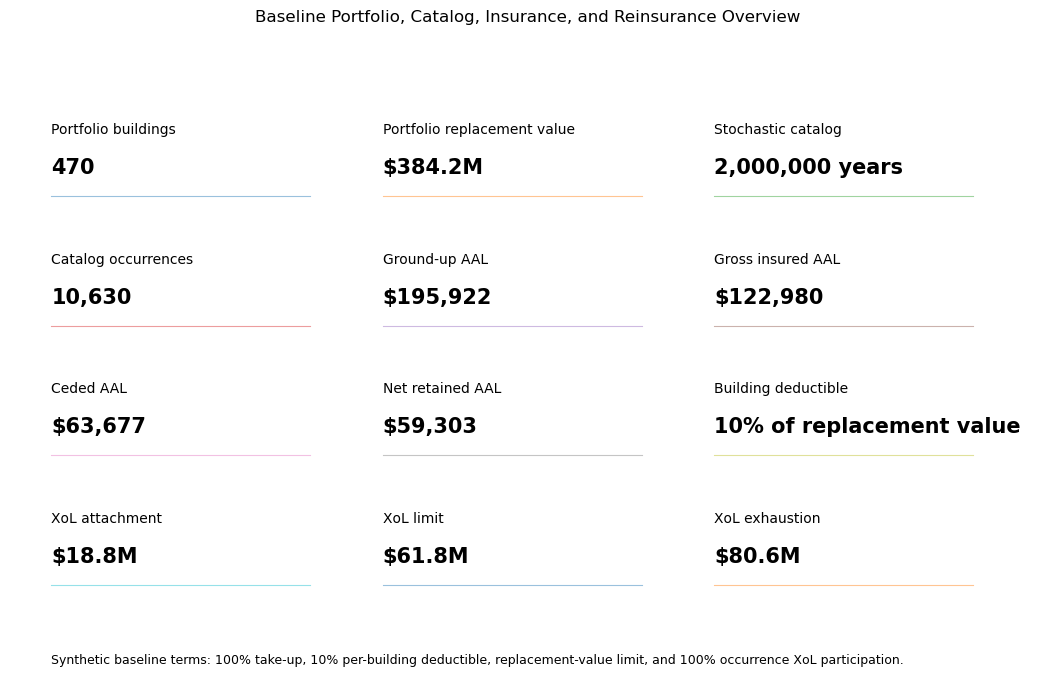

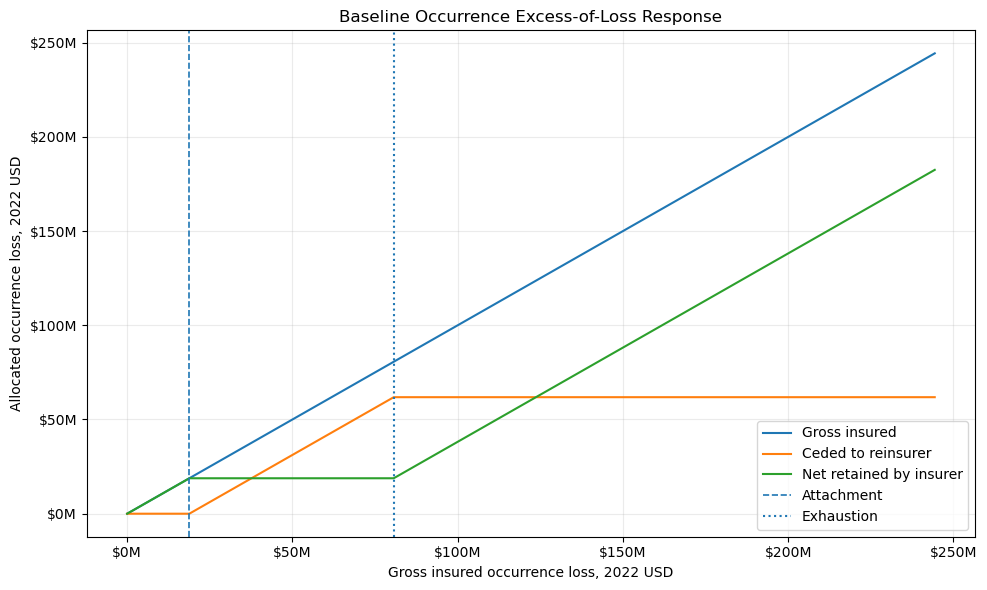


NOTEBOOK 7 CELL 2 BASELINE OVERVIEW FIGURES COMPLETE
Portfolio buildings:             470
Portfolio replacement value:     $384,236,605
Catalog years:                   2,000,000
Catalog occurrences:             10,630
Ground-up AAL:                   $195,922.45
Gross insured AAL:               $122,979.56
Ceded AAL:                       $63,676.60
Net retained AAL:                $59,302.96
Insurance recovery share:        62.7695%
Ceded share of gross insured:    51.7782%
Figures created:                 6
Critical validation checks:      23
Critical failures:               0
Warnings requiring review:       0

Overview table:
  data\processed\notebook_7_baseline_results_validation\notebook_7_baseline_overview_table.csv
Risk-transfer summary:
  data\processed\notebook_7_baseline_results_validation\notebook_7_baseline_risk_transfer_summary.csv
Figure manifest:
  data\processed\notebook_7_baseline_results_validation\notebook_7_cell_2_figure_manifest.csv
Validation:
  data\metadata\n

In [1]:
from pathlib import Path
import hashlib
import json
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    r"."
)

INPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_7_baseline_results_validation"
)
METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_7_baseline_results_validation"
)
PLOT_DIR = INPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

HEADLINE_METRICS_PATH = INPUT_DIR / "notebook_7_baseline_headline_metrics.csv"
LOSS_FLOW_PATH = INPUT_DIR / "notebook_7_baseline_loss_flow.csv"
MODEL_ASSUMPTIONS_PATH = INPUT_DIR / "notebook_7_baseline_model_assumptions.csv"
CELL1_SUMMARY_PATH = METADATA_DIR / "notebook_7_cell_1_summary.json"
CELL1_VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_1_validation.csv"

OVERVIEW_TABLE_PATH = INPUT_DIR / "notebook_7_baseline_overview_table.csv"
RISK_TRANSFER_TABLE_PATH = INPUT_DIR / "notebook_7_baseline_risk_transfer_summary.csv"
FIGURE_MANIFEST_PATH = INPUT_DIR / "notebook_7_cell_2_figure_manifest.csv"
VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_2_validation.csv"
SUMMARY_PATH = METADATA_DIR / "notebook_7_cell_2_summary.json"

AAL_FLOW_PNG = PLOT_DIR / "baseline_aal_loss_flow.png"
AAL_FLOW_PDF = PLOT_DIR / "baseline_aal_loss_flow.pdf"
OVERVIEW_PNG = PLOT_DIR / "baseline_portfolio_catalog_overview.png"
OVERVIEW_PDF = PLOT_DIR / "baseline_portfolio_catalog_overview.pdf"
XOL_RESPONSE_PNG = PLOT_DIR / "baseline_occurrence_xol_response.png"
XOL_RESPONSE_PDF = PLOT_DIR / "baseline_occurrence_xol_response.pdf"

AGGREGATE_TOLERANCE_USD = 0.01
FRACTION_TOLERANCE = 1e-12
MINIMUM_FIGURE_SIZE_BYTES = 5_000


def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_obj:
        while True:
            block = file_obj.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def parse_passed(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "1": True,
                "yes": True,
                "false": False,
                "0": False,
                "no": False,
            }
        )
    )


def usd_millions(value: float) -> str:
    return f"${value / 1_000_000:,.1f}M"


def usd_whole(value: float) -> str:
    return f"${value:,.0f}"


def metric_value(metrics: pd.DataFrame, metric: str) -> float:
    selected = metrics.loc[metrics["metric"].eq(metric), "value"]
    if len(selected) != 1:
        raise RuntimeError(
            f"Expected exactly one headline metric named {metric!r}; found {len(selected)}."
        )
    return float(selected.iloc[0])


def add_check(
    checks: list[dict],
    check_id: str,
    passed: bool,
    detail: str,
    severity: str = "critical",
) -> None:
    checks.append(
        {
            "check_id": check_id,
            "severity": severity,
            "passed": bool(passed),
            "detail": str(detail),
        }
    )


required_paths = [
    HEADLINE_METRICS_PATH,
    LOSS_FLOW_PATH,
    MODEL_ASSUMPTIONS_PATH,
    CELL1_SUMMARY_PATH,
    CELL1_VALIDATION_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Notebook 7 Cell 2 is missing required Cell 1 inputs:\n"
        + "\n".join(missing_paths)
    )

headline_metrics = pd.read_csv(HEADLINE_METRICS_PATH)
loss_flow = pd.read_csv(LOSS_FLOW_PATH)
model_assumptions = pd.read_csv(MODEL_ASSUMPTIONS_PATH)
cell1_summary = json.loads(CELL1_SUMMARY_PATH.read_text(encoding="utf-8"))
cell1_validation = pd.read_csv(CELL1_VALIDATION_PATH)
cell1_validation["passed"] = parse_passed(cell1_validation["passed"])

required_metric_columns = {"metric_group", "metric", "value", "unit", "description"}
required_loss_columns = {
    "stage_order",
    "loss_measure",
    "description",
    "aal_2022_usd",
    "share_of_ground_up_aal",
    "share_of_gross_insured_aal",
    "maximum_aep_loss_2022_usd",
    "maximum_oep_loss_2022_usd",
}
required_assumption_columns = {"assumption_group", "parameter", "value", "unit", "basis"}

checks: list[dict] = []
add_check(
    checks,
    "cell1_validation_has_no_critical_failures",
    not (
        cell1_validation["severity"].astype(str).str.lower().eq("critical")
        & cell1_validation["passed"].eq(False)
    ).any(),
    "Notebook 7 Cell 1 validation contains no failed critical checks.",
)
add_check(
    checks,
    "headline_metrics_schema_complete",
    required_metric_columns.issubset(headline_metrics.columns),
    f"columns={headline_metrics.columns.tolist()}",
)
add_check(
    checks,
    "loss_flow_schema_complete",
    required_loss_columns.issubset(loss_flow.columns),
    f"columns={loss_flow.columns.tolist()}",
)
add_check(
    checks,
    "model_assumptions_schema_complete",
    required_assumption_columns.issubset(model_assumptions.columns),
    f"columns={model_assumptions.columns.tolist()}",
)

expected_loss_measures = [
    "ground_up",
    "uninsured",
    "gross_insured",
    "ceded",
    "net_retained",
]
actual_loss_measures = (
    loss_flow.sort_values("stage_order")["loss_measure"].astype(str).tolist()
)
add_check(
    checks,
    "loss_flow_measures_and_order_expected",
    actual_loss_measures == expected_loss_measures,
    f"actual={actual_loss_measures}",
)
add_check(
    checks,
    "loss_flow_rows_unique",
    not loss_flow["loss_measure"].duplicated().any(),
    f"duplicate_rows={int(loss_flow['loss_measure'].duplicated().sum())}",
)

required_metrics = {
    "portfolio_buildings",
    "portfolio_replacement_value",
    "catalog_years",
    "catalog_occurrences",
    "occupied_years",
    "multiple_event_years",
    "ground_up_aal",
    "gross_insured_aal",
    "uninsured_aal",
    "ceded_aal",
    "net_retained_aal",
    "insurance_recovery_share_of_ground_up",
    "ceded_share_of_gross_insured",
    "building_deductible_share",
    "xol_attachment",
    "xol_limit",
    "xol_exhaustion",
    "maximum_ground_up_aep",
    "maximum_gross_insured_aep",
    "maximum_ceded_aep",
    "maximum_net_retained_aep",
}
missing_metrics = sorted(required_metrics - set(headline_metrics["metric"].astype(str)))
add_check(
    checks,
    "required_headline_metrics_present",
    not missing_metrics,
    f"missing_metrics={missing_metrics}",
)

if missing_metrics:
    validation = pd.DataFrame(checks)
    validation.to_csv(VALIDATION_PATH, index=False)
    raise RuntimeError(
        "Notebook 7 Cell 2 cannot continue because required headline metrics are missing."
    )

portfolio_buildings = int(round(metric_value(headline_metrics, "portfolio_buildings")))
portfolio_value = metric_value(headline_metrics, "portfolio_replacement_value")
catalog_years = int(round(metric_value(headline_metrics, "catalog_years")))
catalog_occurrences = int(round(metric_value(headline_metrics, "catalog_occurrences")))
occupied_years = int(round(metric_value(headline_metrics, "occupied_years")))
multiple_event_years = int(round(metric_value(headline_metrics, "multiple_event_years")))
ground_up_aal = metric_value(headline_metrics, "ground_up_aal")
gross_insured_aal = metric_value(headline_metrics, "gross_insured_aal")
uninsured_aal = metric_value(headline_metrics, "uninsured_aal")
ceded_aal = metric_value(headline_metrics, "ceded_aal")
net_retained_aal = metric_value(headline_metrics, "net_retained_aal")
insurance_recovery_share = metric_value(
    headline_metrics, "insurance_recovery_share_of_ground_up"
)
ceded_share = metric_value(headline_metrics, "ceded_share_of_gross_insured")
deductible_share = metric_value(headline_metrics, "building_deductible_share")
xol_attachment = metric_value(headline_metrics, "xol_attachment")
xol_limit = metric_value(headline_metrics, "xol_limit")
xol_exhaustion = metric_value(headline_metrics, "xol_exhaustion")
maximum_ground_up_aep = metric_value(headline_metrics, "maximum_ground_up_aep")
maximum_gross_insured_aep = metric_value(
    headline_metrics, "maximum_gross_insured_aep"
)
maximum_ceded_aep = metric_value(headline_metrics, "maximum_ceded_aep")
maximum_net_retained_aep = metric_value(
    headline_metrics, "maximum_net_retained_aep"
)

insurance_flow_error = abs(ground_up_aal - gross_insured_aal - uninsured_aal)
reinsurance_flow_error = abs(gross_insured_aal - ceded_aal - net_retained_aal)
exhaustion_error = abs(xol_exhaustion - xol_attachment - xol_limit)

add_check(
    checks,
    "aal_insurance_loss_flow_reconciles",
    insurance_flow_error <= AGGREGATE_TOLERANCE_USD,
    f"difference_2022_usd={insurance_flow_error:.6f}",
)
add_check(
    checks,
    "aal_reinsurance_loss_flow_reconciles",
    reinsurance_flow_error <= AGGREGATE_TOLERANCE_USD,
    f"difference_2022_usd={reinsurance_flow_error:.6f}",
)
add_check(
    checks,
    "xol_attachment_limit_exhaustion_reconcile",
    exhaustion_error <= AGGREGATE_TOLERANCE_USD,
    f"difference_2022_usd={exhaustion_error:.6f}",
)
add_check(
    checks,
    "headline_shares_bounded",
    (
        -FRACTION_TOLERANCE <= insurance_recovery_share <= 1 + FRACTION_TOLERANCE
        and -FRACTION_TOLERANCE <= ceded_share <= 1 + FRACTION_TOLERANCE
        and -FRACTION_TOLERANCE <= deductible_share <= 1 + FRACTION_TOLERANCE
    ),
    (
        f"insurance_recovery_share={insurance_recovery_share:.8f}; "
        f"ceded_share={ceded_share:.8f}; deductible_share={deductible_share:.8f}"
    ),
)
add_check(
    checks,
    "catalog_counts_logically_ordered",
    0 <= multiple_event_years <= occupied_years <= catalog_years,
    (
        f"multiple_event_years={multiple_event_years}; "
        f"occupied_years={occupied_years}; catalog_years={catalog_years}"
    ),
)
add_check(
    checks,
    "headline_counts_positive",
    portfolio_buildings > 0 and catalog_occurrences > 0 and catalog_years > 0,
    (
        f"portfolio_buildings={portfolio_buildings}; "
        f"catalog_occurrences={catalog_occurrences}; catalog_years={catalog_years}"
    ),
)
add_check(
    checks,
    "headline_monetary_values_nonnegative",
    all(
        value >= -AGGREGATE_TOLERANCE_USD
        for value in [
            portfolio_value,
            ground_up_aal,
            gross_insured_aal,
            uninsured_aal,
            ceded_aal,
            net_retained_aal,
            xol_attachment,
            xol_limit,
            xol_exhaustion,
            maximum_ground_up_aep,
            maximum_gross_insured_aep,
            maximum_ceded_aep,
            maximum_net_retained_aep,
        ]
    ),
    "All headline monetary values are nonnegative.",
)

loss_lookup = loss_flow.set_index("loss_measure")
flow_metric_errors = {
    "ground_up": abs(float(loss_lookup.loc["ground_up", "aal_2022_usd"]) - ground_up_aal),
    "gross_insured": abs(
        float(loss_lookup.loc["gross_insured", "aal_2022_usd"]) - gross_insured_aal
    ),
    "uninsured": abs(float(loss_lookup.loc["uninsured", "aal_2022_usd"]) - uninsured_aal),
    "ceded": abs(float(loss_lookup.loc["ceded", "aal_2022_usd"]) - ceded_aal),
    "net_retained": abs(
        float(loss_lookup.loc["net_retained", "aal_2022_usd"]) - net_retained_aal
    ),
}
add_check(
    checks,
    "loss_flow_matches_headline_metrics",
    max(flow_metric_errors.values()) <= AGGREGATE_TOLERANCE_USD,
    f"maximum_difference_2022_usd={max(flow_metric_errors.values()):.6f}",
)

overview_rows = [
    {
        "section": "Portfolio",
        "metric": "Buildings",
        "value": portfolio_buildings,
        "display_value": f"{portfolio_buildings:,}",
        "unit": "buildings",
    },
    {
        "section": "Portfolio",
        "metric": "Replacement value",
        "value": portfolio_value,
        "display_value": usd_millions(portfolio_value),
        "unit": "2022 USD",
    },
    {
        "section": "Catalog",
        "metric": "Catalog years",
        "value": catalog_years,
        "display_value": f"{catalog_years:,}",
        "unit": "years",
    },
    {
        "section": "Catalog",
        "metric": "Occurrences",
        "value": catalog_occurrences,
        "display_value": f"{catalog_occurrences:,}",
        "unit": "occurrences",
    },
    {
        "section": "Catalog",
        "metric": "Occupied years",
        "value": occupied_years,
        "display_value": f"{occupied_years:,}",
        "unit": "years",
    },
    {
        "section": "Catalog",
        "metric": "Multiple-event years",
        "value": multiple_event_years,
        "display_value": f"{multiple_event_years:,}",
        "unit": "years",
    },
    {
        "section": "Insurance",
        "metric": "Building deductible",
        "value": deductible_share,
        "display_value": f"{deductible_share:.0%}",
        "unit": "replacement value",
    },
    {
        "section": "Insurance",
        "metric": "Insurance recovery share",
        "value": insurance_recovery_share,
        "display_value": f"{insurance_recovery_share:.1%}",
        "unit": "ground-up AAL",
    },
    {
        "section": "Reinsurance",
        "metric": "XoL attachment",
        "value": xol_attachment,
        "display_value": usd_millions(xol_attachment),
        "unit": "2022 USD",
    },
    {
        "section": "Reinsurance",
        "metric": "XoL limit",
        "value": xol_limit,
        "display_value": usd_millions(xol_limit),
        "unit": "2022 USD",
    },
    {
        "section": "Reinsurance",
        "metric": "XoL exhaustion",
        "value": xol_exhaustion,
        "display_value": usd_millions(xol_exhaustion),
        "unit": "2022 USD",
    },
    {
        "section": "Reinsurance",
        "metric": "Ceded share",
        "value": ceded_share,
        "display_value": f"{ceded_share:.1%}",
        "unit": "gross insured AAL",
    },
]
overview_table = pd.DataFrame(overview_rows)
overview_table.to_csv(OVERVIEW_TABLE_PATH, index=False)

risk_transfer_table = pd.DataFrame(
    [
        {
            "loss_measure": "ground_up",
            "aal_2022_usd": ground_up_aal,
            "share_of_ground_up": 1.0,
            "share_of_gross_insured": np.nan,
        },
        {
            "loss_measure": "uninsured",
            "aal_2022_usd": uninsured_aal,
            "share_of_ground_up": uninsured_aal / ground_up_aal,
            "share_of_gross_insured": np.nan,
        },
        {
            "loss_measure": "gross_insured",
            "aal_2022_usd": gross_insured_aal,
            "share_of_ground_up": gross_insured_aal / ground_up_aal,
            "share_of_gross_insured": 1.0,
        },
        {
            "loss_measure": "ceded",
            "aal_2022_usd": ceded_aal,
            "share_of_ground_up": ceded_aal / ground_up_aal,
            "share_of_gross_insured": ceded_aal / gross_insured_aal,
        },
        {
            "loss_measure": "net_retained",
            "aal_2022_usd": net_retained_aal,
            "share_of_ground_up": net_retained_aal / ground_up_aal,
            "share_of_gross_insured": net_retained_aal / gross_insured_aal,
        },
    ]
)
risk_transfer_table.to_csv(RISK_TRANSFER_TABLE_PATH, index=False)

# Figure 1: headline AAL values.
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
plot_flow = loss_flow.sort_values("stage_order").copy()
labels = [
    "Ground-up",
    "Policyholder-\nretained",
    "Gross insured",
    "Ceded",
    "Net retained",
]
values = plot_flow["aal_2022_usd"].to_numpy(dtype=float)
bars = ax.bar(labels, values)
ax.set_title("Baseline Average Annual Loss by Risk-Transfer Stage")
ax.set_ylabel("Average annual loss, 2022 USD")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x / 1_000:,.0f}k"))
ax.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        usd_whole(value),
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(AAL_FLOW_PNG, dpi=220, bbox_inches="tight")
fig.savefig(AAL_FLOW_PDF, bbox_inches="tight")
plt.show()
plt.close(fig)

# Figure 2: compact portfolio and contract overview.
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111)
ax.axis("off")
ax.set_title("Baseline Portfolio, Catalog, Insurance, and Reinsurance Overview", pad=18)

cards = [
    ("Portfolio buildings", f"{portfolio_buildings:,}"),
    ("Portfolio replacement value", usd_millions(portfolio_value)),
    ("Stochastic catalog", f"{catalog_years:,} years"),
    ("Catalog occurrences", f"{catalog_occurrences:,}"),
    ("Ground-up AAL", usd_whole(ground_up_aal)),
    ("Gross insured AAL", usd_whole(gross_insured_aal)),
    ("Ceded AAL", usd_whole(ceded_aal)),
    ("Net retained AAL", usd_whole(net_retained_aal)),
    ("Building deductible", f"{deductible_share:.0%} of replacement value"),
    ("XoL attachment", usd_millions(xol_attachment)),
    ("XoL limit", usd_millions(xol_limit)),
    ("XoL exhaustion", usd_millions(xol_exhaustion)),
]
columns = 3
rows = math.ceil(len(cards) / columns)
for index, (label, value) in enumerate(cards):
    row = index // columns
    column = index % columns
    x = 0.04 + column * 0.32
    y = 0.88 - row * 0.205
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=10,
        ha="left",
        va="top",
    )
    ax.text(
        x,
        y - 0.055,
        value,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax.plot(
        [x, x + 0.25],
        [y - 0.115, y - 0.115],
        transform=ax.transAxes,
        linewidth=0.8,
        alpha=0.45,
    )
ax.text(
    0.04,
    0.02,
    "Synthetic baseline terms: 100% take-up, 10% per-building deductible, "
    "replacement-value limit, and 100% occurrence XoL participation.",
    transform=ax.transAxes,
    fontsize=9,
    ha="left",
    va="bottom",
)
fig.tight_layout()
fig.savefig(OVERVIEW_PNG, dpi=220, bbox_inches="tight")
fig.savefig(OVERVIEW_PDF, bbox_inches="tight")
plt.show()
plt.close(fig)

# Figure 3: occurrence XoL response.
maximum_gross_occurrence = float(
    loss_flow.loc[
        loss_flow["loss_measure"].eq("gross_insured"),
        "maximum_oep_loss_2022_usd",
    ].iloc[0]
)
response_maximum = max(maximum_gross_occurrence, xol_exhaustion * 1.15)
gross_grid = np.linspace(0.0, response_maximum, 1201)
ceded_grid = np.minimum(np.maximum(gross_grid - xol_attachment, 0.0), xol_limit)
retained_grid = gross_grid - ceded_grid

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.plot(gross_grid, gross_grid, label="Gross insured")
ax.plot(gross_grid, ceded_grid, label="Ceded to reinsurer")
ax.plot(gross_grid, retained_grid, label="Net retained by insurer")
ax.axvline(xol_attachment, linestyle="--", linewidth=1.2, label="Attachment")
ax.axvline(xol_exhaustion, linestyle=":", linewidth=1.5, label="Exhaustion")
ax.set_title("Baseline Occurrence Excess-of-Loss Response")
ax.set_xlabel("Gross insured occurrence loss, 2022 USD")
ax.set_ylabel("Allocated occurrence loss, 2022 USD")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x / 1_000_000:,.0f}M"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y / 1_000_000:,.0f}M"))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(XOL_RESPONSE_PNG, dpi=220, bbox_inches="tight")
fig.savefig(XOL_RESPONSE_PDF, bbox_inches="tight")
plt.show()
plt.close(fig)

figure_paths = [
    AAL_FLOW_PNG,
    AAL_FLOW_PDF,
    OVERVIEW_PNG,
    OVERVIEW_PDF,
    XOL_RESPONSE_PNG,
    XOL_RESPONSE_PDF,
]
figure_manifest = pd.DataFrame(
    [
        {
            "figure_name": path.stem,
            "format": path.suffix.lstrip("."),
            "path": str(path),
            "size_bytes": path.stat().st_size if path.exists() else 0,
            "sha256": sha256_file(path) if path.exists() else "",
        }
        for path in figure_paths
    ]
)
figure_manifest.to_csv(FIGURE_MANIFEST_PATH, index=False)

add_check(
    checks,
    "overview_table_written",
    OVERVIEW_TABLE_PATH.exists() and len(overview_table) == 12,
    f"rows={len(overview_table)}; path={OVERVIEW_TABLE_PATH}",
)
add_check(
    checks,
    "risk_transfer_table_written",
    RISK_TRANSFER_TABLE_PATH.exists() and len(risk_transfer_table) == 5,
    f"rows={len(risk_transfer_table)}; path={RISK_TRANSFER_TABLE_PATH}",
)
add_check(
    checks,
    "all_figures_created",
    all(path.exists() for path in figure_paths),
    f"missing={[str(path) for path in figure_paths if not path.exists()]}",
)
add_check(
    checks,
    "all_figures_nontrivial_size",
    all(path.stat().st_size >= MINIMUM_FIGURE_SIZE_BYTES for path in figure_paths),
    (
        "sizes="
        + str({path.name: path.stat().st_size for path in figure_paths if path.exists()})
    ),
)
add_check(
    checks,
    "figure_manifest_complete",
    len(figure_manifest) == len(figure_paths)
    and figure_manifest["sha256"].astype(str).str.len().eq(64).all(),
    f"rows={len(figure_manifest)}",
)
add_check(
    checks,
    "xol_response_conserves_gross_loss",
    float(np.max(np.abs(gross_grid - ceded_grid - retained_grid)))
    <= AGGREGATE_TOLERANCE_USD,
    (
        "maximum_difference_2022_usd="
        f"{float(np.max(np.abs(gross_grid - ceded_grid - retained_grid))):.6e}"
    ),
)
add_check(
    checks,
    "xol_ceded_response_bounded_by_limit",
    float(ceded_grid.min()) >= -AGGREGATE_TOLERANCE_USD
    and float(ceded_grid.max()) <= xol_limit + AGGREGATE_TOLERANCE_USD,
    f"ceded_range=({ceded_grid.min():.6f}, {ceded_grid.max():.6f})",
)
add_check(
    checks,
    "overview_values_match_cell1_summary",
    (
        abs(float(cell1_summary.get("ground_up_aal_2022_usd", ground_up_aal)) - ground_up_aal)
        <= AGGREGATE_TOLERANCE_USD
        and abs(
            float(cell1_summary.get("gross_insured_aal_2022_usd", gross_insured_aal))
            - gross_insured_aal
        )
        <= AGGREGATE_TOLERANCE_USD
        and abs(float(cell1_summary.get("ceded_aal_2022_usd", ceded_aal)) - ceded_aal)
        <= AGGREGATE_TOLERANCE_USD
        and abs(
            float(cell1_summary.get("net_retained_aal_2022_usd", net_retained_aal))
            - net_retained_aal
        )
        <= AGGREGATE_TOLERANCE_USD
    ),
    "Cell 2 headline AAL values match the Cell 1 summary.",
)

validation = pd.DataFrame(checks)
validation.to_csv(VALIDATION_PATH, index=False)
critical_failures = validation.loc[
    validation["severity"].astype(str).str.lower().eq("critical")
    & validation["passed"].eq(False)
]
warnings = validation.loc[
    validation["severity"].astype(str).str.lower().eq("warning")
    & validation["passed"].eq(False)
]

summary = {
    "cell": 2,
    "notebook": "07_baseline_results_and_validation.ipynb",
    "status": "complete" if critical_failures.empty else "failed",
    "portfolio_buildings": portfolio_buildings,
    "portfolio_replacement_value_2022_usd": portfolio_value,
    "catalog_years": catalog_years,
    "catalog_occurrences": catalog_occurrences,
    "ground_up_aal_2022_usd": ground_up_aal,
    "gross_insured_aal_2022_usd": gross_insured_aal,
    "uninsured_aal_2022_usd": uninsured_aal,
    "ceded_aal_2022_usd": ceded_aal,
    "net_retained_aal_2022_usd": net_retained_aal,
    "insurance_recovery_share": insurance_recovery_share,
    "ceded_share_of_gross_insured": ceded_share,
    "building_deductible_share": deductible_share,
    "xol_attachment_2022_usd": xol_attachment,
    "xol_limit_2022_usd": xol_limit,
    "xol_exhaustion_2022_usd": xol_exhaustion,
    "figures_created": [str(path) for path in figure_paths],
    "overview_table": str(OVERVIEW_TABLE_PATH),
    "risk_transfer_table": str(RISK_TRANSFER_TABLE_PATH),
    "figure_manifest": str(FIGURE_MANIFEST_PATH),
    "critical_validation_checks": int(
        validation["severity"].astype(str).str.lower().eq("critical").sum()
    ),
    "critical_failures": critical_failures[
        ["check_id", "detail", "passed", "severity"]
    ].to_dict(orient="records"),
    "warnings_requiring_review": warnings[
        ["check_id", "detail", "passed", "severity"]
    ].to_dict(orient="records"),
}
write_json(SUMMARY_PATH, summary)

if not critical_failures.empty:
    raise RuntimeError(
        "Notebook 7 Cell 2 failed critical validation. Review "
        f"{VALIDATION_PATH}."
    )

print()
print("=" * 78)
print("NOTEBOOK 7 CELL 2 BASELINE OVERVIEW FIGURES COMPLETE")
print("=" * 78)
print(f"Portfolio buildings:             {portfolio_buildings:,}")
print(f"Portfolio replacement value:     ${portfolio_value:,.0f}")
print(f"Catalog years:                   {catalog_years:,}")
print(f"Catalog occurrences:             {catalog_occurrences:,}")
print(f"Ground-up AAL:                   ${ground_up_aal:,.2f}")
print(f"Gross insured AAL:               ${gross_insured_aal:,.2f}")
print(f"Ceded AAL:                       ${ceded_aal:,.2f}")
print(f"Net retained AAL:                ${net_retained_aal:,.2f}")
print(f"Insurance recovery share:        {insurance_recovery_share:.4%}")
print(f"Ceded share of gross insured:    {ceded_share:.4%}")
print(f"Figures created:                 {len(figure_paths)}")
print(
    f"Critical validation checks:      "
    f"{int(validation['severity'].astype(str).str.lower().eq('critical').sum())}"
)
print(f"Critical failures:               {len(critical_failures)}")
print(f"Warnings requiring review:       {len(warnings)}")
print()
print("Overview table:")
print(f"  {OVERVIEW_TABLE_PATH}")
print("Risk-transfer summary:")
print(f"  {RISK_TRANSFER_TABLE_PATH}")
print("Figure manifest:")
print(f"  {FIGURE_MANIFEST_PATH}")
print("Validation:")
print(f"  {VALIDATION_PATH}")
print("Summary:")
print(f"  {SUMMARY_PATH}")
print()
print("Next: create the headline AEP and OEP PML comparison figures.")


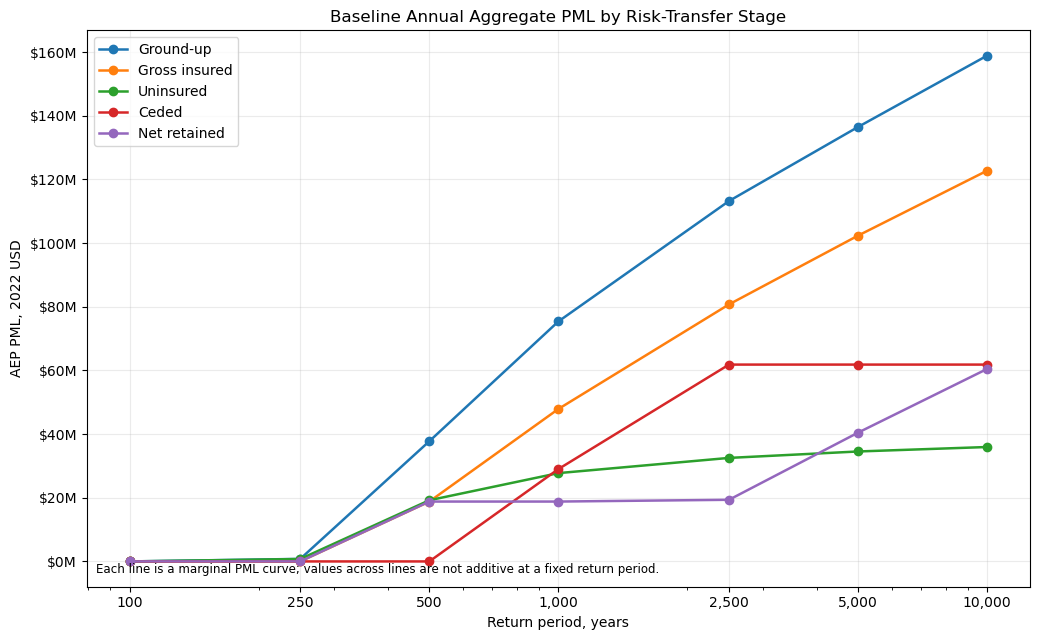

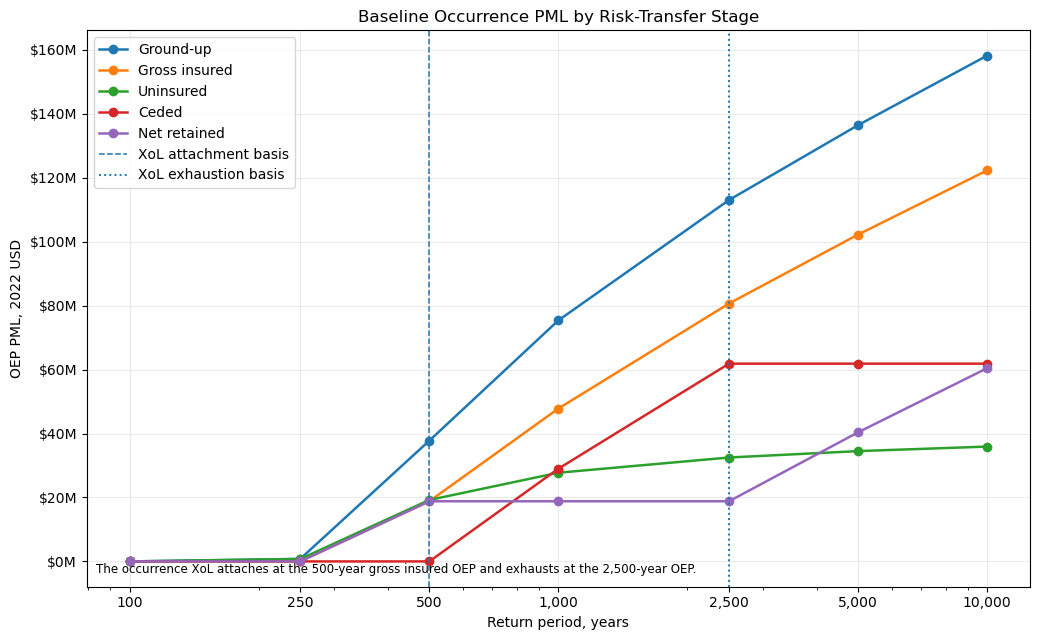

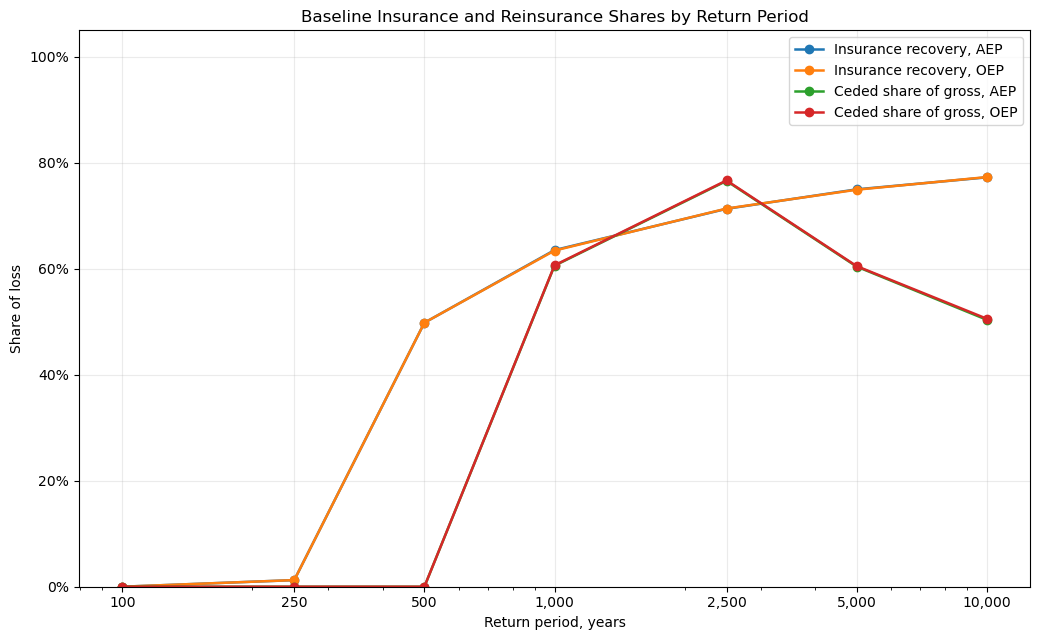


NOTEBOOK 7 CELL 3 HEADLINE PML FIGURES COMPLETE
Headline return periods:         [100, 250, 500, 1000, 2500, 5000, 10000]
Minimum supporting rank:         200
AEP reporting rows:              7
OEP reporting rows:              7
Figure files:                    6
Critical validation checks:      38
Critical failures:               0
Warnings requiring review:       0

AEP PML figure:
  C:\Users\USER\Documents\GitHub\seismic-correlation-insurance-loss\data\processed\notebook_7_baseline_results_validation\plots\baseline_headline_aep_pml.png
OEP PML figure:
  C:\Users\USER\Documents\GitHub\seismic-correlation-insurance-loss\data\processed\notebook_7_baseline_results_validation\plots\baseline_headline_oep_pml.png
Risk-transfer share figure:
  C:\Users\USER\Documents\GitHub\seismic-correlation-insurance-loss\data\processed\notebook_7_baseline_results_validation\plots\baseline_risk_transfer_shares_by_return_period.png
Validation:
  C:\Users\USER\Documents\GitHub\seismic-correlation-insuranc

In [6]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    r"."
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_7_baseline_results_validation"
)
METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_7_baseline_results_validation"
)
PLOT_DIR = RESULTS_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

HEADLINE_PML_PATH = RESULTS_DIR / "notebook_7_baseline_headline_pml.csv"
HEADLINE_METRICS_PATH = RESULTS_DIR / "notebook_7_baseline_headline_metrics.csv"
CELL1_VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_1_validation.csv"
CELL2_VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_2_validation.csv"

AEP_TABLE_PATH = RESULTS_DIR / "notebook_7_baseline_headline_aep_pml.csv"
OEP_TABLE_PATH = RESULTS_DIR / "notebook_7_baseline_headline_oep_pml.csv"
TRANSFER_TABLE_PATH = RESULTS_DIR / "notebook_7_baseline_risk_transfer_by_return_period.csv"
FIGURE_MANIFEST_PATH = RESULTS_DIR / "notebook_7_cell_3_figure_manifest.csv"
VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_3_validation.csv"
SUMMARY_PATH = METADATA_DIR / "notebook_7_cell_3_summary.json"

AEP_PNG = PLOT_DIR / "baseline_headline_aep_pml.png"
AEP_PDF = PLOT_DIR / "baseline_headline_aep_pml.pdf"
OEP_PNG = PLOT_DIR / "baseline_headline_oep_pml.png"
OEP_PDF = PLOT_DIR / "baseline_headline_oep_pml.pdf"
TRANSFER_PNG = PLOT_DIR / "baseline_risk_transfer_shares_by_return_period.png"
TRANSFER_PDF = PLOT_DIR / "baseline_risk_transfer_shares_by_return_period.pdf"

HEADLINE_RETURN_PERIODS = [100, 250, 500, 1000, 2500, 5000, 10000]
LOSS_MEASURES = [
    ("ground_up", "Ground-up"),
    ("gross_insured", "Gross insured"),
    ("uninsured", "Uninsured"),
    ("ceded", "Ceded"),
    ("net_retained", "Net retained"),
]
AGGREGATE_TOLERANCE_USD = 0.01
FRACTION_TOLERANCE = 1e-12
MONOTONIC_TOLERANCE_USD = 0.01
MINIMUM_SUPPORTING_RANK = 20
MINIMUM_FIGURE_SIZE_BYTES = 5_000


def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_obj:
        while True:
            block = file_obj.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def parse_passed(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "1": True,
                "yes": True,
                "false": False,
                "0": False,
                "no": False,
            }
        )
    )


def metric_value(metrics: pd.DataFrame, metric: str) -> float:
    selected = metrics.loc[metrics["metric"].eq(metric), "value"]
    if len(selected) != 1:
        raise RuntimeError(
            f"Expected exactly one headline metric named {metric!r}; found {len(selected)}."
        )
    return float(selected.iloc[0])


def add_check(
    checks: list[dict],
    check_id: str,
    passed: bool,
    detail: str,
    severity: str = "critical",
) -> None:
    checks.append(
        {
            "check_id": check_id,
            "severity": severity,
            "passed": bool(passed),
            "detail": str(detail),
        }
    )


def nondecreasing(values: np.ndarray, tolerance: float) -> bool:
    return bool(np.all(np.diff(values) >= -tolerance))


def usd_millions_axis(value: float, _: int) -> str:
    return f"${value / 1_000_000:,.0f}M"


required_paths = [
    HEADLINE_PML_PATH,
    HEADLINE_METRICS_PATH,
    CELL1_VALIDATION_PATH,
    CELL2_VALIDATION_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Notebook 7 Cell 3 is missing required inputs:\n" + "\n".join(missing_paths)
    )

headline_pml = pd.read_csv(HEADLINE_PML_PATH)
headline_metrics = pd.read_csv(HEADLINE_METRICS_PATH)
cell1_validation = pd.read_csv(CELL1_VALIDATION_PATH)
cell2_validation = pd.read_csv(CELL2_VALIDATION_PATH)
cell1_validation["passed"] = parse_passed(cell1_validation["passed"])
cell2_validation["passed"] = parse_passed(cell2_validation["passed"])

required_pml_columns = {
    "return_period_years",
    "target_annual_exceedance_probability",
    "ground_up_aep_pml_2022_usd",
    "gross_insured_aep_pml_2022_usd",
    "uninsured_aep_pml_2022_usd",
    "ceded_aep_pml_2022_usd",
    "net_retained_aep_pml_2022_usd",
    "ground_up_oep_pml_2022_usd",
    "gross_insured_oep_pml_2022_usd",
    "uninsured_oep_pml_2022_usd",
    "ceded_oep_pml_2022_usd",
    "net_retained_oep_pml_2022_usd",
    "insurance_recovery_share_aep",
    "insurance_recovery_share_oep",
    "ceded_share_of_gross_aep",
    "ceded_share_of_gross_oep",
    "layer_limit_utilization_aep",
    "layer_limit_utilization_oep",
    "minimum_supporting_descending_rank",
    "tail_support_flag",
}
required_metric_columns = {"metric_group", "metric", "value", "unit", "description"}

checks: list[dict] = []
for cell_name, validation in [
    ("cell1", cell1_validation),
    ("cell2", cell2_validation),
]:
    failed_critical = (
        validation["severity"].astype(str).str.lower().eq("critical")
        & validation["passed"].eq(False)
    )
    add_check(
        checks,
        f"{cell_name}_validation_has_no_critical_failures",
        not failed_critical.any(),
        f"failed_critical_checks={int(failed_critical.sum())}",
    )

add_check(
    checks,
    "headline_pml_schema_complete",
    required_pml_columns.issubset(headline_pml.columns),
    f"columns={headline_pml.columns.tolist()}",
)
add_check(
    checks,
    "headline_metrics_schema_complete",
    required_metric_columns.issubset(headline_metrics.columns),
    f"columns={headline_metrics.columns.tolist()}",
)

if not required_pml_columns.issubset(headline_pml.columns):
    validation = pd.DataFrame(checks)
    validation.to_csv(VALIDATION_PATH, index=False)
    raise RuntimeError("Notebook 7 Cell 3 cannot continue because the PML schema is incomplete.")

headline_pml["return_period_years"] = pd.to_numeric(
    headline_pml["return_period_years"], errors="raise"
).astype(int)
headline_pml = headline_pml.sort_values("return_period_years").reset_index(drop=True)

actual_return_periods = headline_pml["return_period_years"].tolist()
add_check(
    checks,
    "headline_return_periods_exact",
    actual_return_periods == HEADLINE_RETURN_PERIODS,
    f"actual={actual_return_periods}",
)
add_check(
    checks,
    "headline_return_periods_unique",
    not headline_pml["return_period_years"].duplicated().any(),
    f"duplicate_rows={int(headline_pml['return_period_years'].duplicated().sum())}",
)

expected_probabilities = 1.0 / headline_pml["return_period_years"].to_numpy(dtype=float)
probability_error = np.max(
    np.abs(
        headline_pml["target_annual_exceedance_probability"].to_numpy(dtype=float)
        - expected_probabilities
    )
)
add_check(
    checks,
    "annual_exceedance_probabilities_match_return_periods",
    probability_error <= FRACTION_TOLERANCE,
    f"maximum_absolute_error={probability_error:.3e}",
)

pml_columns = []
for measure, _ in LOSS_MEASURES:
    pml_columns.extend(
        [f"{measure}_aep_pml_2022_usd", f"{measure}_oep_pml_2022_usd"]
    )

numeric_pml = headline_pml[pml_columns].apply(pd.to_numeric, errors="raise")
add_check(
    checks,
    "headline_pml_values_finite",
    np.isfinite(numeric_pml.to_numpy(dtype=float)).all(),
    f"nonfinite_values={int((~np.isfinite(numeric_pml.to_numpy(dtype=float))).sum())}",
)
add_check(
    checks,
    "headline_pml_values_nonnegative",
    (numeric_pml.to_numpy(dtype=float) >= -AGGREGATE_TOLERANCE_USD).all(),
    f"minimum_value_2022_usd={numeric_pml.min().min():.6f}",
)

for measure, _ in LOSS_MEASURES:
    for curve in ["aep", "oep"]:
        column = f"{measure}_{curve}_pml_2022_usd"
        values = headline_pml[column].to_numpy(dtype=float)
        add_check(
            checks,
            f"{measure}_{curve}_pml_nondecreasing",
            nondecreasing(values, MONOTONIC_TOLERANCE_USD),
            f"minimum_increment_2022_usd={np.diff(values).min():.6f}",
        )

for measure, _ in LOSS_MEASURES:
    aep = headline_pml[f"{measure}_aep_pml_2022_usd"].to_numpy(dtype=float)
    oep = headline_pml[f"{measure}_oep_pml_2022_usd"].to_numpy(dtype=float)
    maximum_shortfall = float(np.max(oep - aep))
    add_check(
        checks,
        f"{measure}_aep_not_below_oep",
        maximum_shortfall <= AGGREGATE_TOLERANCE_USD,
        f"maximum_oep_minus_aep_2022_usd={maximum_shortfall:.6f}",
    )

for curve in ["aep", "oep"]:
    ground_up = headline_pml[f"ground_up_{curve}_pml_2022_usd"].to_numpy(float)
    gross = headline_pml[f"gross_insured_{curve}_pml_2022_usd"].to_numpy(float)
    uninsured = headline_pml[f"uninsured_{curve}_pml_2022_usd"].to_numpy(float)
    ceded = headline_pml[f"ceded_{curve}_pml_2022_usd"].to_numpy(float)
    retained = headline_pml[f"net_retained_{curve}_pml_2022_usd"].to_numpy(float)
    add_check(
        checks,
        f"{curve}_marginal_pml_hierarchy_bounded",
        (
            np.all(gross <= ground_up + AGGREGATE_TOLERANCE_USD)
            and np.all(uninsured <= ground_up + AGGREGATE_TOLERANCE_USD)
            and np.all(ceded <= gross + AGGREGATE_TOLERANCE_USD)
            and np.all(retained <= gross + AGGREGATE_TOLERANCE_USD)
        ),
        (
            f"max_gross_minus_ground_up={np.max(gross-ground_up):.6f}; "
            f"max_uninsured_minus_ground_up={np.max(uninsured-ground_up):.6f}; "
            f"max_ceded_minus_gross={np.max(ceded-gross):.6f}; "
            f"max_retained_minus_gross={np.max(retained-gross):.6f}"
        ),
    )

share_columns = [
    "insurance_recovery_share_aep",
    "insurance_recovery_share_oep",
    "ceded_share_of_gross_aep",
    "ceded_share_of_gross_oep",
]
shares = headline_pml[share_columns].apply(pd.to_numeric, errors="raise")
add_check(
    checks,
    "risk_transfer_shares_bounded",
    (
        shares.to_numpy(dtype=float) >= -FRACTION_TOLERANCE
    ).all()
    and (
        shares.to_numpy(dtype=float) <= 1.0 + FRACTION_TOLERANCE
    ).all(),
    f"range=({shares.min().min():.6f}, {shares.max().max():.6f})",
)

layer_utilization_oep = headline_pml["layer_limit_utilization_oep"].to_numpy(float)
layer_utilization_aep = headline_pml["layer_limit_utilization_aep"].to_numpy(float)
add_check(
    checks,
    "oep_layer_utilization_bounded_by_one",
    (
        np.min(layer_utilization_oep) >= -FRACTION_TOLERANCE
        and np.max(layer_utilization_oep) <= 1.0 + FRACTION_TOLERANCE
    ),
    f"range=({np.min(layer_utilization_oep):.6f}, {np.max(layer_utilization_oep):.6f})",
)
add_check(
    checks,
    "aep_layer_utilization_nonnegative",
    np.min(layer_utilization_aep) >= -FRACTION_TOLERANCE,
    f"minimum={np.min(layer_utilization_aep):.6f}",
)

support_ranks = headline_pml["minimum_supporting_descending_rank"].to_numpy(int)
add_check(
    checks,
    "headline_return_periods_have_adequate_order_statistic_support",
    np.min(support_ranks) >= MINIMUM_SUPPORTING_RANK,
    f"minimum_supporting_rank={int(np.min(support_ranks))}",
)
add_check(
    checks,
    "headline_tail_support_flags_adequate",
    headline_pml["tail_support_flag"].astype(str).eq(
        "adequate_order_statistic_support"
    ).all(),
    f"flags={sorted(headline_pml['tail_support_flag'].astype(str).unique().tolist())}",
)

required_metrics = {"xol_attachment", "xol_exhaustion", "xol_limit"}
missing_metrics = sorted(required_metrics - set(headline_metrics["metric"].astype(str)))
add_check(
    checks,
    "required_reinsurance_metrics_present",
    not missing_metrics,
    f"missing_metrics={missing_metrics}",
)
if missing_metrics:
    validation = pd.DataFrame(checks)
    validation.to_csv(VALIDATION_PATH, index=False)
    raise RuntimeError("Notebook 7 Cell 3 is missing required reinsurance metrics.")

xol_attachment = metric_value(headline_metrics, "xol_attachment")
xol_limit = metric_value(headline_metrics, "xol_limit")
xol_exhaustion = metric_value(headline_metrics, "xol_exhaustion")
add_check(
    checks,
    "xol_terms_reconcile",
    abs(xol_attachment + xol_limit - xol_exhaustion) <= AGGREGATE_TOLERANCE_USD,
    f"difference_2022_usd={abs(xol_attachment + xol_limit - xol_exhaustion):.6f}",
)

# PML values are marginal quantiles. They should not be added across loss measures.
aep_columns = ["return_period_years", "target_annual_exceedance_probability"]
oep_columns = ["return_period_years", "target_annual_exceedance_probability"]
for measure, _ in LOSS_MEASURES:
    aep_columns.append(f"{measure}_aep_pml_2022_usd")
    oep_columns.append(f"{measure}_oep_pml_2022_usd")

aep_table = headline_pml[aep_columns].copy()
oep_table = headline_pml[oep_columns].copy()
aep_table.to_csv(AEP_TABLE_PATH, index=False)
oep_table.to_csv(OEP_TABLE_PATH, index=False)

transfer_table = headline_pml[
    [
        "return_period_years",
        "target_annual_exceedance_probability",
        "insurance_recovery_share_aep",
        "insurance_recovery_share_oep",
        "ceded_share_of_gross_aep",
        "ceded_share_of_gross_oep",
        "layer_limit_utilization_aep",
        "layer_limit_utilization_oep",
        "minimum_supporting_descending_rank",
    ]
].copy()
transfer_table.to_csv(TRANSFER_TABLE_PATH, index=False)

fig = plt.figure(figsize=(10.5, 6.5))
ax = fig.add_subplot(111)
for measure, label in LOSS_MEASURES:
    ax.plot(
        headline_pml["return_period_years"],
        headline_pml[f"{measure}_aep_pml_2022_usd"],
        marker="o",
        linewidth=1.8,
        label=label,
    )
ax.set_xscale("log")
ax.set_xticks(HEADLINE_RETURN_PERIODS)
ax.set_xticklabels([f"{value:,}" for value in HEADLINE_RETURN_PERIODS])
ax.set_title("Baseline Annual Aggregate PML by Risk-Transfer Stage")
ax.set_xlabel("Return period, years")
ax.set_ylabel("AEP PML, 2022 USD")
ax.yaxis.set_major_formatter(FuncFormatter(usd_millions_axis))
ax.grid(alpha=0.25)
ax.legend()
ax.text(
    0.01,
    0.02,
    "Each line is a marginal PML curve; values across lines are not additive at a fixed return period.",
    transform=ax.transAxes,
    fontsize=8.5,
    ha="left",
    va="bottom",
)
fig.tight_layout()
fig.savefig(AEP_PNG, dpi=220, bbox_inches="tight")
fig.savefig(AEP_PDF, bbox_inches="tight")
plt.show()
plt.close(fig)

fig = plt.figure(figsize=(10.5, 6.5))
ax = fig.add_subplot(111)
for measure, label in LOSS_MEASURES:
    ax.plot(
        headline_pml["return_period_years"],
        headline_pml[f"{measure}_oep_pml_2022_usd"],
        marker="o",
        linewidth=1.8,
        label=label,
    )
ax.axvline(500, linestyle="--", linewidth=1.1, label="XoL attachment basis")
ax.axvline(2500, linestyle=":", linewidth=1.4, label="XoL exhaustion basis")
ax.set_xscale("log")
ax.set_xticks(HEADLINE_RETURN_PERIODS)
ax.set_xticklabels([f"{value:,}" for value in HEADLINE_RETURN_PERIODS])
ax.set_title("Baseline Occurrence PML by Risk-Transfer Stage")
ax.set_xlabel("Return period, years")
ax.set_ylabel("OEP PML, 2022 USD")
ax.yaxis.set_major_formatter(FuncFormatter(usd_millions_axis))
ax.grid(alpha=0.25)
ax.legend()
ax.text(
    0.01,
    0.02,
    "The occurrence XoL attaches at the 500-year gross insured OEP and exhausts at the 2,500-year OEP.",
    transform=ax.transAxes,
    fontsize=8.5,
    ha="left",
    va="bottom",
)
fig.tight_layout()
fig.savefig(OEP_PNG, dpi=220, bbox_inches="tight")
fig.savefig(OEP_PDF, bbox_inches="tight")
plt.show()
plt.close(fig)

fig = plt.figure(figsize=(10.5, 6.5))
ax = fig.add_subplot(111)
share_plot_columns = [
    ("insurance_recovery_share_aep", "Insurance recovery, AEP"),
    ("insurance_recovery_share_oep", "Insurance recovery, OEP"),
    ("ceded_share_of_gross_aep", "Ceded share of gross, AEP"),
    ("ceded_share_of_gross_oep", "Ceded share of gross, OEP"),
]
for column, label in share_plot_columns:
    ax.plot(
        headline_pml["return_period_years"],
        headline_pml[column],
        marker="o",
        linewidth=1.8,
        label=label,
    )
ax.set_xscale("log")
ax.set_xticks(HEADLINE_RETURN_PERIODS)
ax.set_xticklabels([f"{value:,}" for value in HEADLINE_RETURN_PERIODS])
ax.set_ylim(0, 1.05)
ax.set_title("Baseline Insurance and Reinsurance Shares by Return Period")
ax.set_xlabel("Return period, years")
ax.set_ylabel("Share of loss")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(TRANSFER_PNG, dpi=220, bbox_inches="tight")
fig.savefig(TRANSFER_PDF, bbox_inches="tight")
plt.show()
plt.close(fig)

figure_rows = []
for figure_name, figure_type, path in [
    ("baseline_headline_aep_pml", "png", AEP_PNG),
    ("baseline_headline_aep_pml", "pdf", AEP_PDF),
    ("baseline_headline_oep_pml", "png", OEP_PNG),
    ("baseline_headline_oep_pml", "pdf", OEP_PDF),
    ("baseline_risk_transfer_shares_by_return_period", "png", TRANSFER_PNG),
    ("baseline_risk_transfer_shares_by_return_period", "pdf", TRANSFER_PDF),
]:
    figure_rows.append(
        {
            "figure_name": figure_name,
            "file_type": figure_type,
            "path": str(path),
            "size_bytes": path.stat().st_size if path.exists() else 0,
            "sha256": sha256_file(path) if path.exists() else None,
        }
    )
figure_manifest = pd.DataFrame(figure_rows)
figure_manifest.to_csv(FIGURE_MANIFEST_PATH, index=False)

add_check(
    checks,
    "reporting_tables_written",
    all(path.exists() for path in [AEP_TABLE_PATH, OEP_TABLE_PATH, TRANSFER_TABLE_PATH]),
    "AEP, OEP, and risk-transfer reporting tables exist.",
)
add_check(
    checks,
    "reporting_table_row_counts_expected",
    len(aep_table) == len(HEADLINE_RETURN_PERIODS)
    and len(oep_table) == len(HEADLINE_RETURN_PERIODS)
    and len(transfer_table) == len(HEADLINE_RETURN_PERIODS),
    (
        f"aep_rows={len(aep_table)}; oep_rows={len(oep_table)}; "
        f"transfer_rows={len(transfer_table)}"
    ),
)
add_check(
    checks,
    "all_figure_files_written",
    figure_manifest["size_bytes"].gt(0).all(),
    f"missing_or_empty={int(figure_manifest['size_bytes'].le(0).sum())}",
)
add_check(
    checks,
    "all_figure_files_have_minimum_size",
    figure_manifest["size_bytes"].ge(MINIMUM_FIGURE_SIZE_BYTES).all(),
    f"minimum_size_bytes={int(figure_manifest['size_bytes'].min())}",
)
add_check(
    checks,
    "figure_hashes_unique_by_file",
    figure_manifest["sha256"].notna().all()
    and not figure_manifest[["path", "sha256"]].duplicated().any(),
    f"files={len(figure_manifest)}",
)

validation = pd.DataFrame(checks)
validation.to_csv(VALIDATION_PATH, index=False)
critical_failures = validation.loc[
    validation["severity"].astype(str).str.lower().eq("critical")
    & validation["passed"].eq(False)
]
warnings = validation.loc[
    validation["severity"].astype(str).str.lower().eq("warning")
    & validation["passed"].eq(False)
]

summary = {
    "cell": 3,
    "status": "complete" if critical_failures.empty else "failed",
    "headline_return_periods": HEADLINE_RETURN_PERIODS,
    "headline_pml_rows": int(len(headline_pml)),
    "minimum_supporting_descending_rank": int(np.min(support_ranks)),
    "xol_attachment_2022_usd": xol_attachment,
    "xol_limit_2022_usd": xol_limit,
    "xol_exhaustion_2022_usd": xol_exhaustion,
    "figure_files": int(len(figure_manifest)),
    "critical_validation_checks": int(
        validation["severity"].astype(str).str.lower().eq("critical").sum()
    ),
    "critical_failures": critical_failures.to_dict(orient="records"),
    "warnings_requiring_review": warnings.to_dict(orient="records"),
    "outputs": {
        "aep_table": str(AEP_TABLE_PATH),
        "oep_table": str(OEP_TABLE_PATH),
        "risk_transfer_table": str(TRANSFER_TABLE_PATH),
        "figure_manifest": str(FIGURE_MANIFEST_PATH),
        "validation": str(VALIDATION_PATH),
    },
}
write_json(SUMMARY_PATH, summary)

if not critical_failures.empty:
    raise RuntimeError(
        "Notebook 7 Cell 3 failed critical validation. Review "
        f"{VALIDATION_PATH}."
    )

print()
print("=" * 78)
print("NOTEBOOK 7 CELL 3 HEADLINE PML FIGURES COMPLETE")
print("=" * 78)
print(f"Headline return periods:         {HEADLINE_RETURN_PERIODS}")
print(f"Minimum supporting rank:         {int(np.min(support_ranks)):,}")
print(f"AEP reporting rows:              {len(aep_table):,}")
print(f"OEP reporting rows:              {len(oep_table):,}")
print(f"Figure files:                    {len(figure_manifest):,}")
print(f"Critical validation checks:      {len(validation):,}")
print(f"Critical failures:               {len(critical_failures):,}")
print(f"Warnings requiring review:       {len(warnings):,}")
print()
print("AEP PML figure:")
print(f"  {AEP_PNG}")
print("OEP PML figure:")
print(f"  {OEP_PNG}")
print("Risk-transfer share figure:")
print(f"  {TRANSFER_PNG}")
print("Validation:")
print(f"  {VALIDATION_PATH}")
print("Summary:")
print(f"  {SUMMARY_PATH}")
print()
print("Next: create source and loss-component contribution figures.")


In [2]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    r"."
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_7_baseline_results_validation"
)
METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_7_baseline_results_validation"
)
PLOT_DIR = RESULTS_DIR / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CELL1_VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_1_validation.csv"
CELL2_VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_2_validation.csv"
CELL3_VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_3_validation.csv"
HEADLINE_METRICS_PATH = RESULTS_DIR / "notebook_7_baseline_headline_metrics.csv"
INPUT_MANIFEST_PATH = RESULTS_DIR / "notebook_7_baseline_input_manifest.csv"

NOTEBOOK5_CELL12_SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_5_damage_loss"
    / "notebook_5_cell_12_summary.json"
)
NOTEBOOK6_CELL5_SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_6_insurance_terms"
    / "notebook_6_cell_5_summary.json"
)
NOTEBOOK6_CELL7_SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_6_insurance_terms"
    / "notebook_6_cell_7_summary.json"
)

COMPONENT_TABLE_PATH = (
    RESULTS_DIR / "notebook_7_baseline_ground_up_component_contributions.csv"
)
SOURCE_TABLE_PATH = RESULTS_DIR / "notebook_7_baseline_source_contributions.csv"
SOURCE_SHARE_TABLE_PATH = (
    RESULTS_DIR / "notebook_7_baseline_source_risk_transfer_shares.csv"
)
FIGURE_MANIFEST_PATH = RESULTS_DIR / "notebook_7_cell_4_figure_manifest.csv"
VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_4_validation.csv"
SUMMARY_PATH = METADATA_DIR / "notebook_7_cell_4_summary.json"

COMPONENT_PNG = PLOT_DIR / "baseline_ground_up_component_aal.png"
COMPONENT_PDF = PLOT_DIR / "baseline_ground_up_component_aal.pdf"
SOURCE_AAL_PNG = PLOT_DIR / "baseline_source_aal_contributions.png"
SOURCE_AAL_PDF = PLOT_DIR / "baseline_source_aal_contributions.pdf"
SOURCE_SHARE_PNG = PLOT_DIR / "baseline_source_risk_transfer_shares.png"
SOURCE_SHARE_PDF = PLOT_DIR / "baseline_source_risk_transfer_shares.pdf"

AGGREGATE_TOLERANCE_USD = 0.01
FRACTION_TOLERANCE = 1e-10
MINIMUM_FIGURE_SIZE_BYTES = 5_000
EXPECTED_COMPONENTS = [
    "structural",
    "nonstructural_drift_sensitive",
    "nonstructural_acceleration_sensitive",
]
LOSS_STAGES = [
    ("ground_up_aal_2022_usd", "Ground-up"),
    ("gross_insured_aal_2022_usd", "Gross insured"),
    ("uninsured_aal_2022_usd", "Uninsured"),
    ("ceded_aal_2022_usd", "Ceded"),
    ("net_retained_aal_2022_usd", "Net retained"),
]


def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_obj:
        while True:
            block = file_obj.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def resolve_recorded_path(project_root: Path, recorded_path: str | Path) -> Path:
    direct = Path(recorded_path)
    if direct.exists():
        return direct

    normalized = str(recorded_path).replace("\\", "/")
    marker = "/data/"
    position = normalized.lower().find(marker)
    if position >= 0:
        candidate = project_root / Path(normalized[position + 1 :])
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Recorded path does not exist: {recorded_path}")


def parse_passed(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "1": True,
                "yes": True,
                "pass": True,
                "passed": True,
                "false": False,
                "0": False,
                "no": False,
                "fail": False,
                "failed": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


def add_check(
    checks: list[dict],
    check_id: str,
    passed: bool,
    detail: str,
    severity: str = "critical",
) -> None:
    checks.append(
        {
            "check_id": check_id,
            "severity": severity,
            "passed": bool(passed),
            "detail": str(detail),
        }
    )


def metric_value(metrics: pd.DataFrame, metric: str) -> float:
    selected = metrics.loc[metrics["metric"].eq(metric), "value"]
    if len(selected) != 1:
        raise RuntimeError(
            f"Expected exactly one headline metric named {metric!r}; found {len(selected)}."
        )
    return float(selected.iloc[0])


def load_output_record(
    summary: dict,
    output_name: str,
) -> tuple[Path, str | None, int | None]:
    record = summary["outputs"][output_name]
    if isinstance(record, dict):
        path = resolve_recorded_path(PROJECT_ROOT, record["path"])
        expected_hash = record.get("sha256")
        expected_rows = record.get("rows")
    else:
        path = resolve_recorded_path(PROJECT_ROOT, record)
        expected_hash = None
        expected_rows = None
    return path, expected_hash, expected_rows


def humanize_source(value: str) -> str:
    text = str(value).strip().replace("_", " ").replace("-", " ")
    words = []
    for word in text.split():
        lower = word.lower()
        if lower in {"cascadia", "oregon", "washington", "california"}:
            words.append(lower.title())
        elif lower in {"xol", "oep", "aep"}:
            words.append(lower.upper())
        else:
            words.append(lower.capitalize())
    return " ".join(words)


def humanize_component(value: str) -> str:
    mapping = {
        "structural": "Structural",
        "nonstructural_drift_sensitive": "Nonstructural\ndrift-sensitive",
        "nonstructural_acceleration_sensitive": (
            "Nonstructural\nacceleration-sensitive"
        ),
    }
    return mapping.get(value, str(value).replace("_", " ").title())


def usd_axis(value: float, _: int) -> str:
    if abs(value) >= 1_000_000:
        return f"${value / 1_000_000:,.1f}M"
    if abs(value) >= 1_000:
        return f"${value / 1_000:,.0f}k"
    return f"${value:,.0f}"


def annotate_bars(ax, bars, formatter) -> None:
    maximum = max((bar.get_height() for bar in bars), default=0.0)
    offset = maximum * 0.02 if maximum > 0.0 else 0.01
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + offset,
            formatter(height),
            ha="center",
            va="bottom",
            fontsize=8,
        )


required_paths = [
    CELL1_VALIDATION_PATH,
    CELL2_VALIDATION_PATH,
    CELL3_VALIDATION_PATH,
    HEADLINE_METRICS_PATH,
    INPUT_MANIFEST_PATH,
    NOTEBOOK5_CELL12_SUMMARY_PATH,
    NOTEBOOK6_CELL5_SUMMARY_PATH,
    NOTEBOOK6_CELL7_SUMMARY_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Notebook 7 Cell 4 is missing required inputs:\n" + "\n".join(missing_paths)
    )

cell_validations = {}
for cell_number, path in [
    (1, CELL1_VALIDATION_PATH),
    (2, CELL2_VALIDATION_PATH),
    (3, CELL3_VALIDATION_PATH),
]:
    table = pd.read_csv(path)
    table["passed"] = parse_passed(table["passed"])
    cell_validations[cell_number] = table

headline_metrics = pd.read_csv(HEADLINE_METRICS_PATH)
input_manifest = pd.read_csv(INPUT_MANIFEST_PATH)
cell12_summary = json.loads(NOTEBOOK5_CELL12_SUMMARY_PATH.read_text(encoding="utf-8"))
cell5_summary = json.loads(NOTEBOOK6_CELL5_SUMMARY_PATH.read_text(encoding="utf-8"))
cell7_summary = json.loads(NOTEBOOK6_CELL7_SUMMARY_PATH.read_text(encoding="utf-8"))

component_path, component_hash, component_rows = load_output_record(
    cell12_summary, "component_aal_summary"
)
notebook5_source_path, notebook5_source_hash, notebook5_source_rows = (
    load_output_record(cell12_summary, "source_aal_summary")
)
insurance_source_path, insurance_source_hash, insurance_source_rows = (
    load_output_record(cell5_summary, "source_aal_summary")
)
reinsurance_source_path, reinsurance_source_hash, reinsurance_source_rows = (
    load_output_record(cell7_summary, "source_aal_summary")
)

component_aal = pd.read_csv(component_path)
notebook5_source = pd.read_csv(notebook5_source_path)
insurance_source = pd.read_csv(insurance_source_path)
reinsurance_source = pd.read_csv(reinsurance_source_path)

checks: list[dict] = []
for cell_number, validation in cell_validations.items():
    failed_critical = (
        validation["severity"].astype(str).str.lower().eq("critical")
        & validation["passed"].eq(False)
    )
    add_check(
        checks,
        f"cell{cell_number}_validation_has_no_critical_failures",
        not failed_critical.any(),
        f"failed_critical_checks={int(failed_critical.sum())}",
    )

for name, path, expected_hash, expected_rows, table in [
    ("component_aal", component_path, component_hash, component_rows, component_aal),
    (
        "notebook5_source_aal",
        notebook5_source_path,
        notebook5_source_hash,
        notebook5_source_rows,
        notebook5_source,
    ),
    (
        "insurance_source_aal",
        insurance_source_path,
        insurance_source_hash,
        insurance_source_rows,
        insurance_source,
    ),
    (
        "reinsurance_source_aal",
        reinsurance_source_path,
        reinsurance_source_hash,
        reinsurance_source_rows,
        reinsurance_source,
    ),
]:
    actual_hash = sha256_file(path)
    add_check(
        checks,
        f"{name}_hash_matches_source_summary",
        expected_hash is None or actual_hash == str(expected_hash).lower(),
        f"expected={expected_hash}; actual={actual_hash}",
    )
    add_check(
        checks,
        f"{name}_row_count_matches_source_summary",
        expected_rows is None or len(table) == int(expected_rows),
        f"expected={expected_rows}; actual={len(table)}",
    )
    add_check(
        checks,
        f"{name}_file_nonempty",
        path.stat().st_size > 0 and len(table) > 0,
        f"size_bytes={path.stat().st_size}; rows={len(table)}",
    )

required_metric_columns = {"metric_group", "metric", "value", "unit", "description"}
required_component_columns = {
    "component",
    "sampled_loss_total_2022_usd",
    "analytical_expected_loss_total_2022_usd",
    "sampled_aal_2022_usd",
    "analytical_expected_aal_2022_usd",
    "sampled_share_of_total_aal",
    "analytical_expected_share_of_total_aal",
}
required_notebook5_source_columns = {
    "source_type",
    "occurrences",
    "sampled_total_ground_up_aal_2022_usd",
    "analytical_expected_total_ground_up_aal_2022_usd",
    "sampled_aal_share",
    "analytical_expected_aal_share",
}
required_insurance_source_columns = {
    "source_type",
    "occurrences",
    "ground_up_aal_2022_usd",
    "gross_insured_aal_2022_usd",
    "uninsured_aal_2022_usd",
    "insurance_recovery_share",
    "share_of_portfolio_ground_up_aal",
    "share_of_portfolio_gross_insured_aal",
}
required_reinsurance_source_columns = {
    "source_type",
    "occurrences",
    "occurrences_above_attachment",
    "occurrences_at_or_above_exhaustion",
    "gross_insured_aal_2022_usd",
    "ceded_aal_2022_usd",
    "net_retained_aal_2022_usd",
    "ceded_share_of_source_gross",
    "share_of_portfolio_ceded_aal",
    "share_of_portfolio_net_retained_aal",
}

for name, table, required_columns in [
    ("headline_metrics", headline_metrics, required_metric_columns),
    ("component_aal", component_aal, required_component_columns),
    ("notebook5_source", notebook5_source, required_notebook5_source_columns),
    ("insurance_source", insurance_source, required_insurance_source_columns),
    ("reinsurance_source", reinsurance_source, required_reinsurance_source_columns),
]:
    missing = sorted(required_columns.difference(table.columns))
    add_check(
        checks,
        f"{name}_schema_complete",
        not missing,
        f"missing={missing}",
    )

critical_schema_missing = any(
    not required.issubset(table.columns)
    for table, required in [
        (headline_metrics, required_metric_columns),
        (component_aal, required_component_columns),
        (notebook5_source, required_notebook5_source_columns),
        (insurance_source, required_insurance_source_columns),
        (reinsurance_source, required_reinsurance_source_columns),
    ]
)
if critical_schema_missing:
    validation = pd.DataFrame(checks)
    validation.to_csv(VALIDATION_PATH, index=False)
    raise RuntimeError("Notebook 7 Cell 4 cannot continue because an input schema is incomplete.")

component_aal = component_aal.copy()
component_aal["component"] = component_aal["component"].astype(str).str.strip()
component_aal["component_label"] = component_aal["component"].map(humanize_component)
component_aal["sampled_minus_expected_aal_2022_usd"] = (
    component_aal["sampled_aal_2022_usd"]
    - component_aal["analytical_expected_aal_2022_usd"]
)
component_aal["sampled_expected_relative_difference"] = np.where(
    component_aal["analytical_expected_aal_2022_usd"].abs() > 0.0,
    component_aal["sampled_minus_expected_aal_2022_usd"]
    / component_aal["analytical_expected_aal_2022_usd"],
    0.0,
)
component_order = {component: index for index, component in enumerate(EXPECTED_COMPONENTS)}
component_aal["component_order"] = component_aal["component"].map(component_order)
component_aal = component_aal.sort_values("component_order").reset_index(drop=True)

add_check(
    checks,
    "ground_up_components_exact",
    component_aal["component"].tolist() == EXPECTED_COMPONENTS,
    f"actual={component_aal['component'].tolist()}",
)
add_check(
    checks,
    "ground_up_component_rows_unique",
    not component_aal["component"].duplicated().any(),
    f"duplicate_rows={int(component_aal['component'].duplicated().sum())}",
)

component_numeric_columns = [
    "sampled_aal_2022_usd",
    "analytical_expected_aal_2022_usd",
    "sampled_share_of_total_aal",
    "analytical_expected_share_of_total_aal",
]
component_numeric = component_aal[component_numeric_columns].apply(
    pd.to_numeric, errors="raise"
)
add_check(
    checks,
    "component_values_finite",
    np.isfinite(component_numeric.to_numpy(dtype=float)).all(),
    f"nonfinite_values={int((~np.isfinite(component_numeric.to_numpy(dtype=float))).sum())}",
)
add_check(
    checks,
    "component_aal_values_nonnegative",
    (
        component_aal[
            ["sampled_aal_2022_usd", "analytical_expected_aal_2022_usd"]
        ].to_numpy(dtype=float)
        >= -AGGREGATE_TOLERANCE_USD
    ).all(),
    (
        f"sampled_min={component_aal['sampled_aal_2022_usd'].min():.9f}; "
        f"expected_min={component_aal['analytical_expected_aal_2022_usd'].min():.9f}"
    ),
)
add_check(
    checks,
    "component_sampled_shares_sum_to_one",
    abs(float(component_aal["sampled_share_of_total_aal"].sum()) - 1.0)
    <= FRACTION_TOLERANCE,
    f"sum={component_aal['sampled_share_of_total_aal'].sum():.12f}",
)
add_check(
    checks,
    "component_expected_shares_sum_to_one",
    abs(float(component_aal["analytical_expected_share_of_total_aal"].sum()) - 1.0)
    <= FRACTION_TOLERANCE,
    f"sum={component_aal['analytical_expected_share_of_total_aal'].sum():.12f}",
)
add_check(
    checks,
    "component_shares_bounded",
    (
        component_aal[
            ["sampled_share_of_total_aal", "analytical_expected_share_of_total_aal"]
        ].to_numpy(dtype=float)
        >= -FRACTION_TOLERANCE
    ).all()
    and (
        component_aal[
            ["sampled_share_of_total_aal", "analytical_expected_share_of_total_aal"]
        ].to_numpy(dtype=float)
        <= 1.0 + FRACTION_TOLERANCE
    ).all(),
    (
        f"sampled_range=({component_aal['sampled_share_of_total_aal'].min():.6f}, "
        f"{component_aal['sampled_share_of_total_aal'].max():.6f}); "
        f"expected_range=({component_aal['analytical_expected_share_of_total_aal'].min():.6f}, "
        f"{component_aal['analytical_expected_share_of_total_aal'].max():.6f})"
    ),
)

ground_up_aal = metric_value(headline_metrics, "ground_up_aal")
gross_insured_aal = metric_value(headline_metrics, "gross_insured_aal")
uninsured_aal = metric_value(headline_metrics, "uninsured_aal")
ceded_aal = metric_value(headline_metrics, "ceded_aal")
net_retained_aal = metric_value(headline_metrics, "net_retained_aal")
expected_ground_up_aal = float(
    cell12_summary["risk_metrics"][
        "analytical_expected_total_ground_up_aal_2022_usd"
    ]
)

add_check(
    checks,
    "component_sampled_aal_reconciles_to_headline",
    abs(float(component_aal["sampled_aal_2022_usd"].sum()) - ground_up_aal)
    <= AGGREGATE_TOLERANCE_USD,
    (
        f"component_sum={component_aal['sampled_aal_2022_usd'].sum():.9f}; "
        f"headline={ground_up_aal:.9f}"
    ),
)
add_check(
    checks,
    "component_expected_aal_reconciles_to_notebook5",
    abs(
        float(component_aal["analytical_expected_aal_2022_usd"].sum())
        - expected_ground_up_aal
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        f"component_sum={component_aal['analytical_expected_aal_2022_usd'].sum():.9f}; "
        f"notebook5={expected_ground_up_aal:.9f}"
    ),
)

for table in [notebook5_source, insurance_source, reinsurance_source]:
    table["source_type"] = table["source_type"].astype(str).str.strip()

source_sets = [
    set(notebook5_source["source_type"]),
    set(insurance_source["source_type"]),
    set(reinsurance_source["source_type"]),
]
add_check(
    checks,
    "source_types_match_across_risk_stages",
    source_sets[0] == source_sets[1] == source_sets[2],
    f"notebook5={sorted(source_sets[0])}; insurance={sorted(source_sets[1])}; reinsurance={sorted(source_sets[2])}",
)
add_check(
    checks,
    "two_source_types_represented",
    len(source_sets[0]) == 2,
    f"source_types={sorted(source_sets[0])}",
)

source_table = (
    notebook5_source[
        [
            "source_type",
            "occurrences",
            "sampled_total_ground_up_aal_2022_usd",
            "analytical_expected_total_ground_up_aal_2022_usd",
            "sampled_aal_share",
            "analytical_expected_aal_share",
        ]
    ]
    .rename(
        columns={
            "occurrences": "occurrences_notebook5",
            "sampled_total_ground_up_aal_2022_usd": "ground_up_aal_2022_usd_notebook5",
            "analytical_expected_total_ground_up_aal_2022_usd": "analytical_expected_ground_up_aal_2022_usd",
            "sampled_aal_share": "ground_up_aal_share_notebook5",
            "analytical_expected_aal_share": "analytical_expected_ground_up_aal_share",
        }
    )
    .merge(
        insurance_source[
            [
                "source_type",
                "occurrences",
                "ground_up_aal_2022_usd",
                "gross_insured_aal_2022_usd",
                "uninsured_aal_2022_usd",
                "insurance_recovery_share",
                "share_of_portfolio_ground_up_aal",
                "share_of_portfolio_gross_insured_aal",
            ]
        ].rename(columns={"occurrences": "occurrences_insurance"}),
        on="source_type",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        reinsurance_source[
            [
                "source_type",
                "occurrences",
                "occurrences_above_attachment",
                "occurrences_at_or_above_exhaustion",
                "gross_insured_aal_2022_usd",
                "ceded_aal_2022_usd",
                "net_retained_aal_2022_usd",
                "ceded_share_of_source_gross",
                "share_of_portfolio_ceded_aal",
                "share_of_portfolio_net_retained_aal",
            ]
        ].rename(
            columns={
                "occurrences": "occurrences_reinsurance",
                "gross_insured_aal_2022_usd": "gross_insured_aal_2022_usd_reinsurance",
            }
        ),
        on="source_type",
        how="inner",
        validate="one_to_one",
    )
)
source_table["source_label"] = source_table["source_type"].map(humanize_source)
source_table["ground_up_source_share"] = np.where(
    ground_up_aal > 0.0,
    source_table["ground_up_aal_2022_usd"] / ground_up_aal,
    0.0,
)
source_table["gross_insured_source_share"] = np.where(
    gross_insured_aal > 0.0,
    source_table["gross_insured_aal_2022_usd"] / gross_insured_aal,
    0.0,
)
source_table["uninsured_source_share"] = np.where(
    uninsured_aal > 0.0,
    source_table["uninsured_aal_2022_usd"] / uninsured_aal,
    0.0,
)
source_table["ceded_source_share"] = np.where(
    ceded_aal > 0.0,
    source_table["ceded_aal_2022_usd"] / ceded_aal,
    0.0,
)
source_table["net_retained_source_share"] = np.where(
    net_retained_aal > 0.0,
    source_table["net_retained_aal_2022_usd"] / net_retained_aal,
    0.0,
)
source_table["net_retained_share_of_source_gross"] = np.where(
    source_table["gross_insured_aal_2022_usd"] > 0.0,
    source_table["net_retained_aal_2022_usd"]
    / source_table["gross_insured_aal_2022_usd"],
    0.0,
)
source_table["attachment_trigger_rate"] = np.where(
    source_table["occurrences_reinsurance"] > 0,
    source_table["occurrences_above_attachment"]
    / source_table["occurrences_reinsurance"],
    0.0,
)
source_table["exhaustion_rate"] = np.where(
    source_table["occurrences_reinsurance"] > 0,
    source_table["occurrences_at_or_above_exhaustion"]
    / source_table["occurrences_reinsurance"],
    0.0,
)
source_table = source_table.sort_values("source_type").reset_index(drop=True)

add_check(
    checks,
    "source_occurrence_counts_match_across_tables",
    (
        source_table["occurrences_notebook5"].astype(int)
        == source_table["occurrences_insurance"].astype(int)
    ).all()
    and (
        source_table["occurrences_insurance"].astype(int)
        == source_table["occurrences_reinsurance"].astype(int)
    ).all(),
    source_table[
        [
            "source_type",
            "occurrences_notebook5",
            "occurrences_insurance",
            "occurrences_reinsurance",
        ]
    ].to_dict(orient="records"),
)
add_check(
    checks,
    "source_ground_up_values_match_notebook5_and_insurance",
    np.max(
        np.abs(
            source_table["ground_up_aal_2022_usd_notebook5"].to_numpy(dtype=float)
            - source_table["ground_up_aal_2022_usd"].to_numpy(dtype=float)
        )
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        "maximum_difference="
        f"{np.max(np.abs(source_table['ground_up_aal_2022_usd_notebook5'] - source_table['ground_up_aal_2022_usd'])):.9f}"
    ),
)
add_check(
    checks,
    "source_gross_values_match_insurance_and_reinsurance",
    np.max(
        np.abs(
            source_table["gross_insured_aal_2022_usd"].to_numpy(dtype=float)
            - source_table[
                "gross_insured_aal_2022_usd_reinsurance"
            ].to_numpy(dtype=float)
        )
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        "maximum_difference="
        f"{np.max(np.abs(source_table['gross_insured_aal_2022_usd'] - source_table['gross_insured_aal_2022_usd_reinsurance'])):.9f}"
    ),
)
add_check(
    checks,
    "source_ground_up_loss_flow_reconciles",
    np.max(
        np.abs(
            source_table["ground_up_aal_2022_usd"].to_numpy(dtype=float)
            - source_table[
                ["gross_insured_aal_2022_usd", "uninsured_aal_2022_usd"]
            ].sum(axis=1).to_numpy(dtype=float)
        )
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        "maximum_difference="
        f"{np.max(np.abs(source_table['ground_up_aal_2022_usd'] - source_table[['gross_insured_aal_2022_usd', 'uninsured_aal_2022_usd']].sum(axis=1))):.9f}"
    ),
)
add_check(
    checks,
    "source_gross_loss_flow_reconciles",
    np.max(
        np.abs(
            source_table["gross_insured_aal_2022_usd"].to_numpy(dtype=float)
            - source_table[
                ["ceded_aal_2022_usd", "net_retained_aal_2022_usd"]
            ].sum(axis=1).to_numpy(dtype=float)
        )
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        "maximum_difference="
        f"{np.max(np.abs(source_table['gross_insured_aal_2022_usd'] - source_table[['ceded_aal_2022_usd', 'net_retained_aal_2022_usd']].sum(axis=1))):.9f}"
    ),
)

for column, headline_value in [
    ("ground_up_aal_2022_usd", ground_up_aal),
    ("gross_insured_aal_2022_usd", gross_insured_aal),
    ("uninsured_aal_2022_usd", uninsured_aal),
    ("ceded_aal_2022_usd", ceded_aal),
    ("net_retained_aal_2022_usd", net_retained_aal),
]:
    add_check(
        checks,
        f"source_{column}_reconciles_to_headline",
        abs(float(source_table[column].sum()) - headline_value)
        <= AGGREGATE_TOLERANCE_USD,
        f"source_sum={source_table[column].sum():.9f}; headline={headline_value:.9f}",
    )

source_value_columns = [column for column, _ in LOSS_STAGES]
source_share_columns = [
    "insurance_recovery_share",
    "ceded_share_of_source_gross",
    "net_retained_share_of_source_gross",
    "attachment_trigger_rate",
    "exhaustion_rate",
    "ground_up_source_share",
    "gross_insured_source_share",
    "uninsured_source_share",
    "ceded_source_share",
    "net_retained_source_share",
]
add_check(
    checks,
    "source_aal_values_finite_nonnegative",
    np.isfinite(source_table[source_value_columns].to_numpy(dtype=float)).all()
    and (
        source_table[source_value_columns].to_numpy(dtype=float)
        >= -AGGREGATE_TOLERANCE_USD
    ).all(),
    (
        f"minimum_value={source_table[source_value_columns].min().min():.9f}; "
        f"nonfinite={int((~np.isfinite(source_table[source_value_columns].to_numpy(dtype=float))).sum())}"
    ),
)
add_check(
    checks,
    "source_shares_bounded",
    np.isfinite(source_table[source_share_columns].to_numpy(dtype=float)).all()
    and (
        source_table[source_share_columns].to_numpy(dtype=float)
        >= -FRACTION_TOLERANCE
    ).all()
    and (
        source_table[source_share_columns].to_numpy(dtype=float)
        <= 1.0 + FRACTION_TOLERANCE
    ).all(),
    (
        f"minimum_share={source_table[source_share_columns].min().min():.9f}; "
        f"maximum_share={source_table[source_share_columns].max().max():.9f}"
    ),
)
add_check(
    checks,
    "source_stage_shares_sum_to_one",
    all(
        abs(float(source_table[column].sum()) - 1.0) <= FRACTION_TOLERANCE
        for column in [
            "ground_up_source_share",
            "gross_insured_source_share",
            "uninsured_source_share",
            "ceded_source_share",
            "net_retained_source_share",
        ]
    ),
    {
        column: float(source_table[column].sum())
        for column in [
            "ground_up_source_share",
            "gross_insured_source_share",
            "uninsured_source_share",
            "ceded_source_share",
            "net_retained_source_share",
        ]
    },
)

component_output_columns = [
    "component",
    "component_label",
    "sampled_aal_2022_usd",
    "analytical_expected_aal_2022_usd",
    "sampled_minus_expected_aal_2022_usd",
    "sampled_expected_relative_difference",
    "sampled_share_of_total_aal",
    "analytical_expected_share_of_total_aal",
]
component_output = component_aal[component_output_columns].copy()
component_output.to_csv(COMPONENT_TABLE_PATH, index=False)

source_output_columns = [
    "source_type",
    "source_label",
    "occurrences_notebook5",
    "occurrences_above_attachment",
    "occurrences_at_or_above_exhaustion",
    "ground_up_aal_2022_usd",
    "gross_insured_aal_2022_usd",
    "uninsured_aal_2022_usd",
    "ceded_aal_2022_usd",
    "net_retained_aal_2022_usd",
    "ground_up_source_share",
    "gross_insured_source_share",
    "uninsured_source_share",
    "ceded_source_share",
    "net_retained_source_share",
]
source_output = source_table[source_output_columns].copy()
source_output = source_output.rename(columns={"occurrences_notebook5": "occurrences"})
source_output.to_csv(SOURCE_TABLE_PATH, index=False)

portfolio_share_row = {
    "source_type": "portfolio",
    "source_label": "Portfolio",
    "insurance_recovery_share": (
        gross_insured_aal / ground_up_aal if ground_up_aal > 0.0 else 0.0
    ),
    "ceded_share_of_source_gross": (
        ceded_aal / gross_insured_aal if gross_insured_aal > 0.0 else 0.0
    ),
    "net_retained_share_of_source_gross": (
        net_retained_aal / gross_insured_aal if gross_insured_aal > 0.0 else 0.0
    ),
    "attachment_trigger_rate": np.nan,
    "exhaustion_rate": np.nan,
}
source_share_output = pd.concat(
    [
        source_table[
            [
                "source_type",
                "source_label",
                "insurance_recovery_share",
                "ceded_share_of_source_gross",
                "net_retained_share_of_source_gross",
                "attachment_trigger_rate",
                "exhaustion_rate",
            ]
        ],
        pd.DataFrame([portfolio_share_row]),
    ],
    ignore_index=True,
)
source_share_output.to_csv(SOURCE_SHARE_TABLE_PATH, index=False)

plt.close("all")

x = np.arange(len(component_output))
width = 0.36
fig, ax = plt.subplots(figsize=(10.5, 6.2))
sampled_bars = ax.bar(
    x - width / 2.0,
    component_output["sampled_aal_2022_usd"],
    width,
    label="Sampled AAL",
)
expected_bars = ax.bar(
    x + width / 2.0,
    component_output["analytical_expected_aal_2022_usd"],
    width,
    label="Analytical expected AAL",
)
ax.set_xticks(x)
ax.set_xticklabels(component_output["component_label"])
ax.set_ylabel("Average annual loss, 2022 USD")
ax.set_title("Ground-Up Average Annual Loss by Damage Component")
ax.yaxis.set_major_formatter(FuncFormatter(usd_axis))
ax.grid(axis="y", alpha=0.25)
ax.legend()
annotate_bars(ax, sampled_bars, lambda value: f"${value / 1_000:,.1f}k")
for index, share in enumerate(component_output["sampled_share_of_total_aal"]):
    ax.text(
        x[index] - width / 2.0,
        sampled_bars[index].get_height() * 0.5,
        f"{share:.1%}",
        ha="center",
        va="center",
        rotation=90,
        fontsize=8,
    )
fig.tight_layout()
fig.savefig(COMPONENT_PNG, dpi=220, bbox_inches="tight")
fig.savefig(COMPONENT_PDF, bbox_inches="tight")
plt.close(fig)

stage_labels = [label for _, label in LOSS_STAGES]
x = np.arange(len(LOSS_STAGES))
number_of_sources = len(source_table)
width = min(0.36, 0.78 / max(number_of_sources, 1))
fig, ax = plt.subplots(figsize=(11.5, 6.5))
source_bars = []
for source_index, row in source_table.iterrows():
    offset = (source_index - (number_of_sources - 1) / 2.0) * width
    values = [float(row[column]) for column, _ in LOSS_STAGES]
    bars = ax.bar(
        x + offset,
        values,
        width,
        label=row["source_label"],
    )
    source_bars.append(bars)
ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_ylabel("Average annual loss contribution, 2022 USD")
ax.set_title("Average Annual Loss Contribution by Earthquake Source Type")
ax.yaxis.set_major_formatter(FuncFormatter(usd_axis))
ax.grid(axis="y", alpha=0.25)
ax.legend()
for bars in source_bars:
    annotate_bars(ax, bars, lambda value: f"${value / 1_000:,.0f}k")
fig.tight_layout()
fig.savefig(SOURCE_AAL_PNG, dpi=220, bbox_inches="tight")
fig.savefig(SOURCE_AAL_PDF, bbox_inches="tight")
plt.close(fig)

share_plot = source_share_output.copy()
x = np.arange(len(share_plot))
width = 0.36
fig, ax = plt.subplots(figsize=(10.5, 6.2))
insurance_bars = ax.bar(
    x - width / 2.0,
    share_plot["insurance_recovery_share"],
    width,
    label="Insurance recovery share of ground-up AAL",
)
ceded_bars = ax.bar(
    x + width / 2.0,
    share_plot["ceded_share_of_source_gross"],
    width,
    label="Ceded share of gross insured AAL",
)
ax.set_xticks(x)
ax.set_xticklabels(share_plot["source_label"])
ax.set_ylabel("Share")
ax.set_title("Risk-Transfer Shares by Earthquake Source Type")
ax.set_ylim(0.0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", alpha=0.25)
ax.legend()
annotate_bars(ax, insurance_bars, lambda value: f"{value:.1%}")
annotate_bars(ax, ceded_bars, lambda value: f"{value:.1%}")
fig.tight_layout()
fig.savefig(SOURCE_SHARE_PNG, dpi=220, bbox_inches="tight")
fig.savefig(SOURCE_SHARE_PDF, bbox_inches="tight")
plt.close(fig)

figure_rows = []
for figure_name, figure_type, path in [
    ("ground_up_component_aal", "png", COMPONENT_PNG),
    ("ground_up_component_aal", "pdf", COMPONENT_PDF),
    ("source_aal_contributions", "png", SOURCE_AAL_PNG),
    ("source_aal_contributions", "pdf", SOURCE_AAL_PDF),
    ("source_risk_transfer_shares", "png", SOURCE_SHARE_PNG),
    ("source_risk_transfer_shares", "pdf", SOURCE_SHARE_PDF),
]:
    figure_rows.append(
        {
            "figure_name": figure_name,
            "file_type": figure_type,
            "path": str(path),
            "size_bytes": int(path.stat().st_size),
            "sha256": sha256_file(path),
        }
    )
figure_manifest = pd.DataFrame(figure_rows)
figure_manifest.to_csv(FIGURE_MANIFEST_PATH, index=False)

for output_path, check_id in [
    (COMPONENT_TABLE_PATH, "component_reporting_table_exists"),
    (SOURCE_TABLE_PATH, "source_reporting_table_exists"),
    (SOURCE_SHARE_TABLE_PATH, "source_share_reporting_table_exists"),
    (FIGURE_MANIFEST_PATH, "figure_manifest_exists"),
]:
    add_check(
        checks,
        check_id,
        output_path.exists() and output_path.stat().st_size > 0,
        str(output_path),
    )

add_check(
    checks,
    "all_figure_files_exist",
    all(Path(path).exists() for path in figure_manifest["path"]),
    f"figure_files={len(figure_manifest)}",
)
add_check(
    checks,
    "all_figure_files_have_minimum_size",
    figure_manifest["size_bytes"].ge(MINIMUM_FIGURE_SIZE_BYTES).all(),
    f"minimum_size_bytes={int(figure_manifest['size_bytes'].min())}",
)
add_check(
    checks,
    "figure_hashes_complete",
    figure_manifest["sha256"].astype(str).str.len().eq(64).all(),
    f"files={len(figure_manifest)}",
)
add_check(
    checks,
    "reporting_table_rows_expected",
    len(component_output) == 3
    and len(source_output) == 2
    and len(source_share_output) == 3,
    (
        f"components={len(component_output)}; sources={len(source_output)}; "
        f"source_share_rows={len(source_share_output)}"
    ),
)

validation = pd.DataFrame(checks)
validation.to_csv(VALIDATION_PATH, index=False)
critical_failures = validation.loc[
    validation["severity"].astype(str).str.lower().eq("critical")
    & validation["passed"].eq(False)
]
warnings = validation.loc[
    validation["severity"].astype(str).str.lower().eq("warning")
    & validation["passed"].eq(False)
]

largest_component = component_output.sort_values(
    "sampled_aal_2022_usd", ascending=False
).iloc[0]
largest_ground_up_source = source_output.sort_values(
    "ground_up_aal_2022_usd", ascending=False
).iloc[0]
largest_ceded_source = source_output.sort_values(
    "ceded_aal_2022_usd", ascending=False
).iloc[0]

summary = {
    "cell": 4,
    "status": "complete" if critical_failures.empty else "failed",
    "ground_up_aal_2022_usd": ground_up_aal,
    "analytical_expected_ground_up_aal_2022_usd": expected_ground_up_aal,
    "components": int(len(component_output)),
    "source_types": int(len(source_output)),
    "largest_sampled_aal_component": {
        "component": str(largest_component["component"]),
        "aal_2022_usd": float(largest_component["sampled_aal_2022_usd"]),
        "share_of_ground_up_aal": float(
            largest_component["sampled_share_of_total_aal"]
        ),
    },
    "largest_ground_up_source": {
        "source_type": str(largest_ground_up_source["source_type"]),
        "aal_2022_usd": float(largest_ground_up_source["ground_up_aal_2022_usd"]),
        "share_of_ground_up_aal": float(
            largest_ground_up_source["ground_up_source_share"]
        ),
    },
    "largest_ceded_source": {
        "source_type": str(largest_ceded_source["source_type"]),
        "aal_2022_usd": float(largest_ceded_source["ceded_aal_2022_usd"]),
        "share_of_ceded_aal": float(largest_ceded_source["ceded_source_share"]),
    },
    "figure_files": int(len(figure_manifest)),
    "critical_validation_checks": int(
        validation["severity"].astype(str).str.lower().eq("critical").sum()
    ),
    "critical_failures": critical_failures.to_dict(orient="records"),
    "warnings_requiring_review": warnings.to_dict(orient="records"),
    "outputs": {
        "component_contributions": str(COMPONENT_TABLE_PATH),
        "source_contributions": str(SOURCE_TABLE_PATH),
        "source_risk_transfer_shares": str(SOURCE_SHARE_TABLE_PATH),
        "figure_manifest": str(FIGURE_MANIFEST_PATH),
        "validation": str(VALIDATION_PATH),
    },
}
write_json(SUMMARY_PATH, summary)

if not critical_failures.empty:
    raise RuntimeError(
        "Notebook 7 Cell 4 failed critical validation. Review "
        f"{VALIDATION_PATH}."
    )

print()
print("=" * 78)
print("NOTEBOOK 7 CELL 4 SOURCE AND COMPONENT FIGURES COMPLETE")
print("=" * 78)
print(f"Ground-up components:              {len(component_output):,}")
print(f"Earthquake source types:           {len(source_output):,}")
print(
    "Largest ground-up component:     "
    f"{largest_component['component_label'].replace(chr(10), ' ')} "
    f"({largest_component['sampled_share_of_total_aal']:.2%})"
)
print(
    "Largest ground-up source:        "
    f"{largest_ground_up_source['source_label']} "
    f"({largest_ground_up_source['ground_up_source_share']:.2%})"
)
print(
    "Largest ceded-loss source:       "
    f"{largest_ceded_source['source_label']} "
    f"({largest_ceded_source['ceded_source_share']:.2%})"
)
print(f"Figure files:                      {len(figure_manifest):,}")
print(f"Critical validation checks:        {len(validation):,}")
print(f"Critical failures:                 {len(critical_failures):,}")
print(f"Warnings requiring review:         {len(warnings):,}")
print()
print("Ground-up component figure:")
print(f"  {COMPONENT_PNG}")
print("Source AAL contribution figure:")
print(f"  {SOURCE_AAL_PNG}")
print("Source risk-transfer share figure:")
print(f"  {SOURCE_SHARE_PNG}")
print("Validation:")
print(f"  {VALIDATION_PATH}")
print("Summary:")
print(f"  {SUMMARY_PATH}")
print()
print("Next: create full exceedance-curve and largest-loss event figures.")



NOTEBOOK 7 CELL 4 SOURCE AND COMPONENT FIGURES COMPLETE
Ground-up components:              3
Earthquake source types:           2
Largest ground-up component:     Nonstructural acceleration-sensitive (76.25%)
Largest ground-up source:        Interface (90.60%)
Largest ceded-loss source:       Interface (95.49%)
Figure files:                      6
Critical validation checks:        52
Critical failures:                 0
Warnings requiring review:         0

Ground-up component figure:
  data\processed\notebook_7_baseline_results_validation\plots\baseline_ground_up_component_aal.png
Source AAL contribution figure:
  data\processed\notebook_7_baseline_results_validation\plots\baseline_source_aal_contributions.png
Source risk-transfer share figure:
  data\processed\notebook_7_baseline_results_validation\plots\baseline_source_risk_transfer_shares.png
Validation:
  data\metadata\notebook_7_baseline_results_validation\notebook_7_cell_4_validation.csv
Summary:
  data\metadata\notebook_7_bas

In [8]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    r"."
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_7_baseline_results_validation"
)
METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_7_baseline_results_validation"
)
PLOT_DIR = RESULTS_DIR / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CELL_VALIDATION_PATHS = {
    cell: METADATA_DIR / f"notebook_7_cell_{cell}_validation.csv"
    for cell in [1, 2, 3, 4]
}
NOTEBOOK6_CELL5_SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_6_insurance_terms"
    / "notebook_6_cell_5_summary.json"
)
NOTEBOOK6_CELL7_SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_6_insurance_terms"
    / "notebook_6_cell_7_summary.json"
)

FULL_CURVE_PATH = RESULTS_DIR / "notebook_7_baseline_full_exceedance_curves.csv.gz"
LARGEST_EVENTS_PATH = RESULTS_DIR / "notebook_7_baseline_largest_occurrence_losses.csv"
LARGEST_YEARS_PATH = RESULTS_DIR / "notebook_7_baseline_largest_annual_losses.csv"
FIGURE_MANIFEST_PATH = RESULTS_DIR / "notebook_7_cell_5_figure_manifest.csv"
VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_5_validation.csv"
SUMMARY_PATH = METADATA_DIR / "notebook_7_cell_5_summary.json"

AEP_CURVE_PNG = PLOT_DIR / "baseline_full_aep_exceedance_curves.png"
AEP_CURVE_PDF = PLOT_DIR / "baseline_full_aep_exceedance_curves.pdf"
OEP_CURVE_PNG = PLOT_DIR / "baseline_full_oep_exceedance_curves.png"
OEP_CURVE_PDF = PLOT_DIR / "baseline_full_oep_exceedance_curves.pdf"
LARGEST_EVENTS_PNG = PLOT_DIR / "baseline_largest_occurrence_losses.png"
LARGEST_EVENTS_PDF = PLOT_DIR / "baseline_largest_occurrence_losses.pdf"

LOSS_MEASURES = [
    ("ground_up", "Ground-up"),
    ("gross_insured", "Gross insured"),
    ("uninsured", "Uninsured"),
    ("ceded", "Ceded"),
    ("net_retained", "Net retained"),
]
CURVE_TYPES = ["AEP", "OEP"]
TOP_EVENT_ROWS = 20
TOP_EVENT_PLOT_ROWS = 10
TOP_ANNUAL_ROWS = 20
AGGREGATE_TOLERANCE_USD = 0.01
PROBABILITY_TOLERANCE = 1e-12
MINIMUM_FIGURE_SIZE_BYTES = 5_000


def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_obj:
        while True:
            block = file_obj.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def resolve_recorded_path(project_root: Path, recorded_path: str | Path) -> Path:
    direct = Path(recorded_path)
    if direct.exists():
        return direct

    normalized = str(recorded_path).replace("\\", "/")
    marker = "/data/"
    position = normalized.lower().find(marker)
    if position >= 0:
        candidate = project_root / Path(normalized[position + 1 :])
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Recorded path does not exist: {recorded_path}")


def parse_passed(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "1": True,
                "yes": True,
                "pass": True,
                "passed": True,
                "false": False,
                "0": False,
                "no": False,
                "fail": False,
                "failed": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


def add_check(
    checks: list[dict],
    check_id: str,
    passed: bool,
    detail: str,
    severity: str = "critical",
) -> None:
    checks.append(
        {
            "check_id": check_id,
            "severity": severity,
            "passed": bool(passed),
            "detail": str(detail),
        }
    )


def load_output_record(
    summary: dict,
    output_name: str,
) -> tuple[Path, str | None, int | None]:
    record = summary["outputs"][output_name]
    if isinstance(record, dict):
        path = resolve_recorded_path(PROJECT_ROOT, record["path"])
        expected_hash = record.get("sha256")
        expected_rows = record.get("rows")
    else:
        path = resolve_recorded_path(PROJECT_ROOT, record)
        expected_hash = None
        expected_rows = None
    return path, expected_hash, expected_rows


def humanize_source(value: str) -> str:
    text = str(value).strip().replace("_", " ").replace("-", " ")
    return " ".join(word.capitalize() for word in text.split())


def usd_axis(value: float, _: int) -> str:
    absolute = abs(value)
    if absolute >= 1_000_000_000:
        return f"${value / 1_000_000_000:,.1f}B"
    if absolute >= 1_000_000:
        return f"${value / 1_000_000:,.0f}M"
    if absolute >= 1_000:
        return f"${value / 1_000:,.0f}k"
    return f"${value:,.0f}"


def return_period_axis(value: float, _: int) -> str:
    if value >= 1_000_000:
        return f"{value / 1_000_000:g}M"
    if value >= 1_000:
        return f"{value / 1_000:g}k"
    return f"{value:g}"


def load_and_validate_source(
    checks: list[dict],
    name: str,
    path: Path,
    expected_hash: str | None,
    expected_rows: int | None,
    compression: str | None = None,
) -> pd.DataFrame:
    table = pd.read_csv(path, compression=compression)
    actual_hash = sha256_file(path)
    add_check(
        checks,
        f"{name}_hash_matches_source_summary",
        expected_hash is None or actual_hash == str(expected_hash).lower(),
        f"expected={expected_hash}; actual={actual_hash}",
    )
    add_check(
        checks,
        f"{name}_row_count_matches_source_summary",
        expected_rows is None or len(table) == int(expected_rows),
        f"expected={expected_rows}; actual={len(table)}",
    )
    add_check(
        checks,
        f"{name}_file_nonempty",
        path.stat().st_size > 0 and len(table) > 0,
        f"size_bytes={path.stat().st_size}; rows={len(table)}",
    )
    return table


required_paths = list(CELL_VALIDATION_PATHS.values()) + [
    NOTEBOOK6_CELL5_SUMMARY_PATH,
    NOTEBOOK6_CELL7_SUMMARY_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Notebook 7 Cell 5 is missing required inputs:\n" + "\n".join(missing_paths)
    )

checks: list[dict] = []
for cell_number, path in CELL_VALIDATION_PATHS.items():
    validation = pd.read_csv(path)
    validation["passed"] = parse_passed(validation["passed"])
    failed_critical = (
        validation["severity"].astype(str).str.lower().eq("critical")
        & validation["passed"].eq(False)
    )
    add_check(
        checks,
        f"cell{cell_number}_validation_has_no_critical_failures",
        not failed_critical.any(),
        f"failed_critical_checks={int(failed_critical.sum())}",
    )

cell5_summary = json.loads(
    NOTEBOOK6_CELL5_SUMMARY_PATH.read_text(encoding="utf-8")
)
cell7_summary = json.loads(
    NOTEBOOK6_CELL7_SUMMARY_PATH.read_text(encoding="utf-8")
)
add_check(
    checks,
    "notebook6_cell5_summary_declares_success",
    bool(cell5_summary.get("all_critical_checks_passed", False)),
    f"all_critical_checks_passed={cell5_summary.get('all_critical_checks_passed')}",
)
add_check(
    checks,
    "notebook6_cell7_summary_declares_success",
    bool(cell7_summary.get("all_critical_checks_passed", False)),
    f"all_critical_checks_passed={cell7_summary.get('all_critical_checks_passed')}",
)

insurance_curve_path, insurance_curve_hash, insurance_curve_rows = load_output_record(
    cell5_summary, "exceedance_probability_curve"
)
reinsurance_curve_path, reinsurance_curve_hash, reinsurance_curve_rows = (
    load_output_record(cell7_summary, "exceedance_probability_curve")
)
occurrence_path, occurrence_hash, occurrence_rows = load_output_record(
    cell7_summary, "occurrence_reinsurance_loss"
)
annual_path, annual_hash, annual_rows = load_output_record(
    cell7_summary, "annual_loss_series"
)

insurance_curve = load_and_validate_source(
    checks,
    "insurance_exceedance_curve",
    insurance_curve_path,
    insurance_curve_hash,
    insurance_curve_rows,
    compression="gzip",
)
reinsurance_curve = load_and_validate_source(
    checks,
    "reinsurance_exceedance_curve",
    reinsurance_curve_path,
    reinsurance_curve_hash,
    reinsurance_curve_rows,
    compression="gzip",
)
occurrences = load_and_validate_source(
    checks,
    "reinsurance_occurrence_loss",
    occurrence_path,
    occurrence_hash,
    occurrence_rows,
    compression="gzip",
)
annual = load_and_validate_source(
    checks,
    "reinsurance_annual_loss_series",
    annual_path,
    annual_hash,
    annual_rows,
    compression="gzip",
)

required_curve_columns = {
    "loss_measure",
    "curve_type",
    "descending_rank",
    "annual_exceedance_probability",
    "return_period_years",
    "loss_2022_usd",
}
required_occurrence_columns = {
    "catalog_year",
    "occurrence_id",
    "source_type",
    "sampled_total_ground_up_loss_2022_usd",
    "gross_insured_loss_2022_usd",
    "uninsured_loss_2022_usd",
    "ceded_loss_2022_usd",
    "net_retained_loss_2022_usd",
    "attachment_triggered",
    "layer_exhausted",
}
required_annual_columns = {
    "catalog_year",
    "event_count",
    "zero_event_year",
    "triggering_occurrences",
    "exhausting_occurrences",
    "ground_up_aep_2022_usd",
    "ground_up_oep_2022_usd",
    "uninsured_aep_2022_usd",
    "uninsured_oep_2022_usd",
    "gross_insured_aep_2022_usd",
    "gross_insured_oep_2022_usd",
    "ceded_aep_2022_usd",
    "ceded_oep_2022_usd",
    "net_retained_aep_2022_usd",
    "net_retained_oep_2022_usd",
}
for name, table, required_columns in [
    ("insurance_curve", insurance_curve, required_curve_columns),
    ("reinsurance_curve", reinsurance_curve, required_curve_columns),
    ("occurrence_loss", occurrences, required_occurrence_columns),
    ("annual_loss", annual, required_annual_columns),
]:
    missing = sorted(required_columns.difference(table.columns))
    add_check(checks, f"{name}_schema_complete", not missing, f"missing={missing}")

if not (
    required_curve_columns.issubset(insurance_curve.columns)
    and required_curve_columns.issubset(reinsurance_curve.columns)
    and required_occurrence_columns.issubset(occurrences.columns)
    and required_annual_columns.issubset(annual.columns)
):
    pd.DataFrame(checks).to_csv(VALIDATION_PATH, index=False)
    raise RuntimeError("Notebook 7 Cell 5 cannot continue because an input schema is incomplete.")

declared_years = int(cell7_summary["annual_catalog"]["declared_duration_years"])
expected_occurrences = int(cell7_summary["annual_catalog"]["occurrences"])
attachment = float(cell7_summary["reinsurance_scenario"]["attachment_2022_usd"])
limit = float(cell7_summary["reinsurance_scenario"]["limit_2022_usd"])
exhaustion = float(cell7_summary["reinsurance_scenario"]["exhaustion_2022_usd"])

for table in [insurance_curve, reinsurance_curve]:
    table["loss_measure"] = table["loss_measure"].astype(str).str.strip()
    table["curve_type"] = table["curve_type"].astype(str).str.strip().str.upper()
    for column in [
        "descending_rank",
        "annual_exceedance_probability",
        "return_period_years",
        "loss_2022_usd",
    ]:
        table[column] = pd.to_numeric(table[column], errors="raise")
    table["descending_rank"] = table["descending_rank"].astype(np.int64)

add_check(
    checks,
    "insurance_curve_measures_expected",
    set(insurance_curve["loss_measure"].unique())
    == {"ground_up", "gross_insured", "uninsured"},
    f"actual={sorted(insurance_curve['loss_measure'].unique().tolist())}",
)
add_check(
    checks,
    "reinsurance_curve_measures_expected",
    set(reinsurance_curve["loss_measure"].unique())
    == {"gross_insured", "ceded", "net_retained"},
    f"actual={sorted(reinsurance_curve['loss_measure'].unique().tolist())}",
)
add_check(
    checks,
    "curve_types_expected",
    set(insurance_curve["curve_type"].unique()) == set(CURVE_TYPES)
    and set(reinsurance_curve["curve_type"].unique()) == set(CURVE_TYPES),
    (
        f"insurance={sorted(insurance_curve['curve_type'].unique().tolist())}; "
        f"reinsurance={sorted(reinsurance_curve['curve_type'].unique().tolist())}"
    ),
)

gross_insurance = insurance_curve.loc[
    insurance_curve["loss_measure"].eq("gross_insured")
].copy()
gross_reinsurance = reinsurance_curve.loc[
    reinsurance_curve["loss_measure"].eq("gross_insured")
].copy()
gross_compare = gross_insurance.merge(
    gross_reinsurance,
    on=["curve_type", "descending_rank"],
    how="outer",
    suffixes=("_insurance", "_reinsurance"),
    indicator=True,
    validate="one_to_one",
)
gross_loss_difference = np.abs(
    gross_compare["loss_2022_usd_insurance"]
    - gross_compare["loss_2022_usd_reinsurance"]
)
gross_probability_difference = np.abs(
    gross_compare["annual_exceedance_probability_insurance"]
    - gross_compare["annual_exceedance_probability_reinsurance"]
)
add_check(
    checks,
    "gross_insured_curves_reconcile_between_cells",
    gross_compare["_merge"].eq("both").all()
    and float(gross_loss_difference.max()) <= AGGREGATE_TOLERANCE_USD
    and float(gross_probability_difference.max()) <= PROBABILITY_TOLERANCE,
    (
        f"rows={len(gross_compare)}; unmatched={int((gross_compare['_merge'] != 'both').sum())}; "
        f"maximum_loss_difference={gross_loss_difference.max():.3e}; "
        f"maximum_probability_difference={gross_probability_difference.max():.3e}"
    ),
)

full_curve = pd.concat(
    [
        insurance_curve.loc[
            insurance_curve["loss_measure"].isin(
                ["ground_up", "gross_insured", "uninsured"]
            )
        ],
        reinsurance_curve.loc[
            reinsurance_curve["loss_measure"].isin(["ceded", "net_retained"])
        ],
    ],
    ignore_index=True,
)
label_map = dict(LOSS_MEASURES)
full_curve["loss_label"] = full_curve["loss_measure"].map(label_map)
full_curve = full_curve.sort_values(
    ["curve_type", "loss_measure", "descending_rank"]
).reset_index(drop=True)
full_curve.to_csv(FULL_CURVE_PATH, index=False, compression="gzip")

expected_pairs = {
    (measure, curve_type)
    for measure, _ in LOSS_MEASURES
    for curve_type in CURVE_TYPES
}
actual_pairs = set(
    zip(full_curve["loss_measure"], full_curve["curve_type"])
)
add_check(
    checks,
    "combined_curve_measure_type_pairs_complete",
    actual_pairs == expected_pairs,
    f"actual={sorted(actual_pairs)}",
)
add_check(
    checks,
    "combined_curve_keys_unique",
    not full_curve.duplicated(
        ["loss_measure", "curve_type", "descending_rank"]
    ).any(),
    (
        "duplicate_rows="
        f"{int(full_curve.duplicated(['loss_measure', 'curve_type', 'descending_rank']).sum())}"
    ),
)

for measure, _ in LOSS_MEASURES:
    for curve_type in CURVE_TYPES:
        subset = full_curve.loc[
            full_curve["loss_measure"].eq(measure)
            & full_curve["curve_type"].eq(curve_type)
        ].sort_values("descending_rank")
        ranks = subset["descending_rank"].to_numpy(dtype=np.int64)
        probabilities = subset["annual_exceedance_probability"].to_numpy(dtype=float)
        return_periods = subset["return_period_years"].to_numpy(dtype=float)
        losses = subset["loss_2022_usd"].to_numpy(dtype=float)
        expected_ranks = np.arange(1, len(subset) + 1, dtype=np.int64)
        add_check(
            checks,
            f"{measure}_{curve_type.lower()}_ranks_contiguous",
            np.array_equal(ranks, expected_ranks),
            f"rows={len(subset)}; final_rank={ranks[-1] if len(ranks) else None}",
        )
        add_check(
            checks,
            f"{measure}_{curve_type.lower()}_probability_equation",
            np.max(np.abs(probabilities - ranks / declared_years))
            <= PROBABILITY_TOLERANCE,
            (
                "maximum_error="
                f"{np.max(np.abs(probabilities - ranks / declared_years)):.3e}"
            ),
        )
        add_check(
            checks,
            f"{measure}_{curve_type.lower()}_return_period_equation",
            np.max(np.abs(return_periods - declared_years / ranks))
            <= 1e-8,
            (
                "maximum_error="
                f"{np.max(np.abs(return_periods - declared_years / ranks)):.3e}"
            ),
        )
        add_check(
            checks,
            f"{measure}_{curve_type.lower()}_losses_positive_finite_and_ordered",
            np.isfinite(losses).all()
            and np.all(losses > 0.0)
            and np.all(np.diff(losses) <= AGGREGATE_TOLERANCE_USD),
            (
                f"minimum_loss={losses.min() if len(losses) else np.nan:.6f}; "
                f"maximum_increase={np.diff(losses).max() if len(losses) > 1 else 0.0:.6f}"
            ),
        )

for measure, _ in LOSS_MEASURES:
    aep = full_curve.loc[
        full_curve["loss_measure"].eq(measure)
        & full_curve["curve_type"].eq("AEP")
    ][["descending_rank", "loss_2022_usd"]].rename(
        columns={"loss_2022_usd": "aep_loss"}
    )
    oep = full_curve.loc[
        full_curve["loss_measure"].eq(measure)
        & full_curve["curve_type"].eq("OEP")
    ][["descending_rank", "loss_2022_usd"]].rename(
        columns={"loss_2022_usd": "oep_loss"}
    )
    aligned = aep.merge(oep, on="descending_rank", how="inner", validate="one_to_one")
    add_check(
        checks,
        f"{measure}_aep_curve_not_below_oep_curve",
        np.all(
            aligned["aep_loss"].to_numpy(dtype=float)
            + AGGREGATE_TOLERANCE_USD
            >= aligned["oep_loss"].to_numpy(dtype=float)
        ),
        (
            f"ranks_compared={len(aligned)}; "
            f"minimum_difference={(aligned['aep_loss'] - aligned['oep_loss']).min():.6f}"
        ),
    )

for column in [
    "catalog_year",
    "sampled_total_ground_up_loss_2022_usd",
    "gross_insured_loss_2022_usd",
    "uninsured_loss_2022_usd",
    "ceded_loss_2022_usd",
    "net_retained_loss_2022_usd",
]:
    occurrences[column] = pd.to_numeric(occurrences[column], errors="raise")
occurrences["catalog_year"] = occurrences["catalog_year"].astype(np.int64)
occurrences["occurrence_id"] = occurrences["occurrence_id"].astype(str).str.strip()
occurrences["source_type"] = occurrences["source_type"].astype(str).str.strip()

occurrence_loss_columns = [
    "sampled_total_ground_up_loss_2022_usd",
    "gross_insured_loss_2022_usd",
    "uninsured_loss_2022_usd",
    "ceded_loss_2022_usd",
    "net_retained_loss_2022_usd",
]
occurrence_matrix = occurrences[occurrence_loss_columns].to_numpy(dtype=float)
add_check(
    checks,
    "occurrence_count_and_ids_match_summary",
    len(occurrences) == expected_occurrences and occurrences["occurrence_id"].is_unique,
    (
        f"rows={len(occurrences)}; expected={expected_occurrences}; "
        f"unique={occurrences['occurrence_id'].nunique()}"
    ),
)
add_check(
    checks,
    "occurrence_losses_finite_and_nonnegative",
    np.isfinite(occurrence_matrix).all() and np.all(occurrence_matrix >= 0.0),
    f"minimum_loss={occurrence_matrix.min():.6f}",
)
ground_up_error = np.abs(
    occurrences["sampled_total_ground_up_loss_2022_usd"]
    - occurrences["gross_insured_loss_2022_usd"]
    - occurrences["uninsured_loss_2022_usd"]
)
gross_error = np.abs(
    occurrences["gross_insured_loss_2022_usd"]
    - occurrences["ceded_loss_2022_usd"]
    - occurrences["net_retained_loss_2022_usd"]
)
add_check(
    checks,
    "occurrence_ground_up_loss_conservation",
    float(ground_up_error.max()) <= AGGREGATE_TOLERANCE_USD,
    f"maximum_error={ground_up_error.max():.3e}",
)
add_check(
    checks,
    "occurrence_reinsurance_loss_conservation",
    float(gross_error.max()) <= AGGREGATE_TOLERANCE_USD,
    f"maximum_error={gross_error.max():.3e}",
)

occurrences = occurrences.sort_values(
    ["sampled_total_ground_up_loss_2022_usd", "gross_insured_loss_2022_usd"],
    ascending=[False, False],
).reset_index(drop=True)
largest_events = occurrences.head(min(TOP_EVENT_ROWS, len(occurrences))).copy()
largest_events.insert(0, "ground_up_loss_rank", np.arange(1, len(largest_events) + 1))
largest_events["source_label"] = largest_events["source_type"].map(humanize_source)
largest_events["insurance_recovery_share"] = np.divide(
    largest_events["gross_insured_loss_2022_usd"],
    largest_events["sampled_total_ground_up_loss_2022_usd"],
    out=np.zeros(len(largest_events), dtype=float),
    where=largest_events["sampled_total_ground_up_loss_2022_usd"].to_numpy(dtype=float)
    > 0.0,
)
largest_events["ceded_share_of_gross"] = np.divide(
    largest_events["ceded_loss_2022_usd"],
    largest_events["gross_insured_loss_2022_usd"],
    out=np.zeros(len(largest_events), dtype=float),
    where=largest_events["gross_insured_loss_2022_usd"].to_numpy(dtype=float) > 0.0,
)
largest_events.to_csv(LARGEST_EVENTS_PATH, index=False)

add_check(
    checks,
    "largest_events_sorted_descending",
    np.all(
        np.diff(
            largest_events["sampled_total_ground_up_loss_2022_usd"].to_numpy(
                dtype=float
            )
        )
        <= AGGREGATE_TOLERANCE_USD
    ),
    f"rows={len(largest_events)}",
)
add_check(
    checks,
    "largest_events_rows_expected",
    len(largest_events) == min(TOP_EVENT_ROWS, expected_occurrences),
    f"actual={len(largest_events)}; expected={min(TOP_EVENT_ROWS, expected_occurrences)}",
)
add_check(
    checks,
    "largest_event_equals_maximum_occurrence_ground_up_loss",
    abs(
        float(largest_events.iloc[0]["sampled_total_ground_up_loss_2022_usd"])
        - float(occurrences["sampled_total_ground_up_loss_2022_usd"].max())
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        f"top={largest_events.iloc[0]['sampled_total_ground_up_loss_2022_usd']:.6f}; "
        f"maximum={occurrences['sampled_total_ground_up_loss_2022_usd'].max():.6f}"
    ),
)

for column in sorted(required_annual_columns.difference({"zero_event_year"})):
    annual[column] = pd.to_numeric(annual[column], errors="raise")
annual["catalog_year"] = annual["catalog_year"].astype(np.int64)
annual["event_count"] = annual["event_count"].astype(np.int64)
annual_matrix = annual[
    [
        "ground_up_aep_2022_usd",
        "gross_insured_aep_2022_usd",
        "uninsured_aep_2022_usd",
        "ceded_aep_2022_usd",
        "net_retained_aep_2022_usd",
    ]
].to_numpy(dtype=float)
add_check(
    checks,
    "annual_series_declared_year_count_matches",
    len(annual) == declared_years
    and int(annual["catalog_year"].min()) == 1
    and int(annual["catalog_year"].max()) == declared_years,
    (
        f"rows={len(annual)}; expected={declared_years}; "
        f"range=({annual['catalog_year'].min()}, {annual['catalog_year'].max()})"
    ),
)
add_check(
    checks,
    "annual_losses_finite_and_nonnegative",
    np.isfinite(annual_matrix).all() and np.all(annual_matrix >= 0.0),
    f"minimum_loss={annual_matrix.min():.6f}",
)
annual_ground_up_error = np.abs(
    annual["ground_up_aep_2022_usd"]
    - annual["gross_insured_aep_2022_usd"]
    - annual["uninsured_aep_2022_usd"]
)
annual_gross_error = np.abs(
    annual["gross_insured_aep_2022_usd"]
    - annual["ceded_aep_2022_usd"]
    - annual["net_retained_aep_2022_usd"]
)
add_check(
    checks,
    "annual_ground_up_loss_conservation",
    float(annual_ground_up_error.max()) <= AGGREGATE_TOLERANCE_USD,
    f"maximum_error={annual_ground_up_error.max():.3e}",
)
add_check(
    checks,
    "annual_reinsurance_loss_conservation",
    float(annual_gross_error.max()) <= AGGREGATE_TOLERANCE_USD,
    f"maximum_error={annual_gross_error.max():.3e}",
)

largest_years = annual.sort_values(
    ["ground_up_aep_2022_usd", "gross_insured_aep_2022_usd"],
    ascending=[False, False],
).head(min(TOP_ANNUAL_ROWS, len(annual))).copy()
largest_years.insert(0, "ground_up_aep_rank", np.arange(1, len(largest_years) + 1))
largest_years.to_csv(LARGEST_YEARS_PATH, index=False)
add_check(
    checks,
    "largest_annual_years_sorted_descending",
    np.all(
        np.diff(largest_years["ground_up_aep_2022_usd"].to_numpy(dtype=float))
        <= AGGREGATE_TOLERANCE_USD
    ),
    f"rows={len(largest_years)}",
)
add_check(
    checks,
    "largest_annual_year_equals_maximum_aep_loss",
    abs(
        float(largest_years.iloc[0]["ground_up_aep_2022_usd"])
        - float(annual["ground_up_aep_2022_usd"].max())
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        f"top={largest_years.iloc[0]['ground_up_aep_2022_usd']:.6f}; "
        f"maximum={annual['ground_up_aep_2022_usd'].max():.6f}"
    ),
)
add_check(
    checks,
    "largest_occurrence_matches_maximum_ground_up_oep",
    abs(
        float(largest_events.iloc[0]["sampled_total_ground_up_loss_2022_usd"])
        - float(annual["ground_up_oep_2022_usd"].max())
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        f"occurrence={largest_events.iloc[0]['sampled_total_ground_up_loss_2022_usd']:.6f}; "
        f"annual_oep={annual['ground_up_oep_2022_usd'].max():.6f}"
    ),
)

for curve_type, png_path, pdf_path, title in [
    (
        "AEP",
        AEP_CURVE_PNG,
        AEP_CURVE_PDF,
        "Full Annual Aggregate Loss Exceedance Curves",
    ),
    (
        "OEP",
        OEP_CURVE_PNG,
        OEP_CURVE_PDF,
        "Full Annual Occurrence Loss Exceedance Curves",
    ),
]:
    fig, ax = plt.subplots(figsize=(10.5, 6.5))
    for measure, label in LOSS_MEASURES:
        subset = full_curve.loc[
            full_curve["curve_type"].eq(curve_type)
            & full_curve["loss_measure"].eq(measure)
        ].sort_values("return_period_years")
        ax.plot(
            subset["return_period_years"],
            subset["loss_2022_usd"],
            linewidth=1.7,
            label=label,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Return period, years")
    ax.set_ylabel("Loss, 2022 USD")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(FuncFormatter(return_period_axis))
    ax.yaxis.set_major_formatter(FuncFormatter(usd_axis))
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

plot_events = largest_events.head(TOP_EVENT_PLOT_ROWS).copy()
plot_events = plot_events.iloc[::-1].reset_index(drop=True)
labels = []
for _, row in plot_events.iterrows():
    magnitude_text = ""
    if "magnitude" in plot_events.columns and pd.notna(row.get("magnitude")):
        magnitude_text = f", M{float(row['magnitude']):.1f}"
    labels.append(
        f"#{int(row['ground_up_loss_rank'])} {row['source_label']}{magnitude_text}, "
        f"Year {int(row['catalog_year'])}"
    )

y = np.arange(len(plot_events), dtype=float)
bar_height = 0.14
measure_columns = [
    ("sampled_total_ground_up_loss_2022_usd", "Ground-up"),
    ("gross_insured_loss_2022_usd", "Gross insured"),
    ("uninsured_loss_2022_usd", "Uninsured"),
    ("ceded_loss_2022_usd", "Ceded"),
    ("net_retained_loss_2022_usd", "Net retained"),
]
fig, ax = plt.subplots(figsize=(12.5, 8.0))
offsets = (np.arange(len(measure_columns)) - (len(measure_columns) - 1) / 2.0) * bar_height
for offset, (column, label) in zip(offsets, measure_columns):
    ax.barh(
        y + offset,
        plot_events[column].to_numpy(dtype=float),
        height=bar_height,
        label=label,
    )
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Occurrence loss, 2022 USD")
ax.set_title("Largest Catalog Occurrences and Risk-Transfer Outcomes")
ax.xaxis.set_major_formatter(FuncFormatter(usd_axis))
ax.grid(axis="x", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(LARGEST_EVENTS_PNG, dpi=220, bbox_inches="tight")
fig.savefig(LARGEST_EVENTS_PDF, bbox_inches="tight")
plt.close(fig)

figure_rows = []
for figure_name, file_type, path in [
    ("full_aep_exceedance_curves", "png", AEP_CURVE_PNG),
    ("full_aep_exceedance_curves", "pdf", AEP_CURVE_PDF),
    ("full_oep_exceedance_curves", "png", OEP_CURVE_PNG),
    ("full_oep_exceedance_curves", "pdf", OEP_CURVE_PDF),
    ("largest_occurrence_losses", "png", LARGEST_EVENTS_PNG),
    ("largest_occurrence_losses", "pdf", LARGEST_EVENTS_PDF),
]:
    figure_rows.append(
        {
            "figure_name": figure_name,
            "file_type": file_type,
            "path": str(path),
            "size_bytes": int(path.stat().st_size),
            "sha256": sha256_file(path),
        }
    )
figure_manifest = pd.DataFrame(figure_rows)
figure_manifest.to_csv(FIGURE_MANIFEST_PATH, index=False)

for output_path, check_id in [
    (FULL_CURVE_PATH, "combined_full_curve_output_exists"),
    (LARGEST_EVENTS_PATH, "largest_events_output_exists"),
    (LARGEST_YEARS_PATH, "largest_years_output_exists"),
    (FIGURE_MANIFEST_PATH, "figure_manifest_exists"),
]:
    add_check(
        checks,
        check_id,
        output_path.exists() and output_path.stat().st_size > 0,
        str(output_path),
    )
add_check(
    checks,
    "all_figure_files_exist",
    all(Path(path).exists() for path in figure_manifest["path"]),
    f"figure_files={len(figure_manifest)}",
)
add_check(
    checks,
    "all_figure_files_have_minimum_size",
    figure_manifest["size_bytes"].ge(MINIMUM_FIGURE_SIZE_BYTES).all(),
    f"minimum_size_bytes={int(figure_manifest['size_bytes'].min())}",
)
add_check(
    checks,
    "figure_hashes_complete",
    figure_manifest["sha256"].astype(str).str.len().eq(64).all(),
    f"files={len(figure_manifest)}",
)

validation = pd.DataFrame(checks)
validation.to_csv(VALIDATION_PATH, index=False)
critical_failures = validation.loc[
    validation["severity"].astype(str).str.lower().eq("critical")
    & validation["passed"].eq(False)
]
warnings = validation.loc[
    validation["severity"].astype(str).str.lower().eq("warning")
    & validation["passed"].eq(False)
]

largest_event = largest_events.iloc[0]
largest_year = largest_years.iloc[0]
summary = {
    "cell": 5,
    "status": "complete" if critical_failures.empty else "failed",
    "declared_catalog_years": declared_years,
    "catalog_occurrences": expected_occurrences,
    "exceedance_curve_rows": int(len(full_curve)),
    "largest_occurrence": {
        "occurrence_id": str(largest_event["occurrence_id"]),
        "catalog_year": int(largest_event["catalog_year"]),
        "source_type": str(largest_event["source_type"]),
        "magnitude": (
            float(largest_event["magnitude"])
            if "magnitude" in largest_events.columns
            and pd.notna(largest_event.get("magnitude"))
            else None
        ),
        "ground_up_loss_2022_usd": float(
            largest_event["sampled_total_ground_up_loss_2022_usd"]
        ),
        "gross_insured_loss_2022_usd": float(
            largest_event["gross_insured_loss_2022_usd"]
        ),
        "ceded_loss_2022_usd": float(largest_event["ceded_loss_2022_usd"]),
        "net_retained_loss_2022_usd": float(
            largest_event["net_retained_loss_2022_usd"]
        ),
    },
    "largest_annual_aggregate_loss": {
        "catalog_year": int(largest_year["catalog_year"]),
        "event_count": int(largest_year["event_count"]),
        "ground_up_aep_2022_usd": float(largest_year["ground_up_aep_2022_usd"]),
        "gross_insured_aep_2022_usd": float(
            largest_year["gross_insured_aep_2022_usd"]
        ),
        "ceded_aep_2022_usd": float(largest_year["ceded_aep_2022_usd"]),
        "net_retained_aep_2022_usd": float(
            largest_year["net_retained_aep_2022_usd"]
        ),
    },
    "reinsurance_layer": {
        "attachment_2022_usd": attachment,
        "limit_2022_usd": limit,
        "exhaustion_2022_usd": exhaustion,
    },
    "figure_files": int(len(figure_manifest)),
    "critical_validation_checks": int(
        validation["severity"].astype(str).str.lower().eq("critical").sum()
    ),
    "critical_failures": critical_failures.to_dict(orient="records"),
    "warnings_requiring_review": warnings.to_dict(orient="records"),
    "outputs": {
        "full_exceedance_curves": str(FULL_CURVE_PATH),
        "largest_occurrence_losses": str(LARGEST_EVENTS_PATH),
        "largest_annual_losses": str(LARGEST_YEARS_PATH),
        "figure_manifest": str(FIGURE_MANIFEST_PATH),
        "validation": str(VALIDATION_PATH),
    },
}
write_json(SUMMARY_PATH, summary)

if not critical_failures.empty:
    raise RuntimeError(
        "Notebook 7 Cell 5 failed critical validation. Review "
        f"{VALIDATION_PATH}."
    )

print()
print("=" * 78)
print("NOTEBOOK 7 CELL 5 FULL CURVES AND LARGEST EVENTS COMPLETE")
print("=" * 78)
print(f"Declared catalog years:            {declared_years:,}")
print(f"Catalog occurrences:               {expected_occurrences:,}")
print(f"Combined exceedance-curve rows:     {len(full_curve):,}")
print(f"Largest occurrence source:          {largest_event['source_label']}")
if "magnitude" in largest_events.columns and pd.notna(largest_event.get("magnitude")):
    print(f"Largest occurrence magnitude:       {float(largest_event['magnitude']):.2f}")
print(
    "Largest occurrence ground-up:      "
    f"${largest_event['sampled_total_ground_up_loss_2022_usd']:,.0f}"
)
print(
    "Largest occurrence gross insured:  "
    f"${largest_event['gross_insured_loss_2022_usd']:,.0f}"
)
print(
    "Largest occurrence ceded:           "
    f"${largest_event['ceded_loss_2022_usd']:,.0f}"
)
print(
    "Largest annual aggregate loss:      "
    f"${largest_year['ground_up_aep_2022_usd']:,.0f}"
)
print(f"Largest annual-loss event count:     {int(largest_year['event_count']):,}")
print(f"Figure files:                        {len(figure_manifest):,}")
print(f"Critical validation checks:          {len(validation):,}")
print(f"Critical failures:                   {len(critical_failures):,}")
print(f"Warnings requiring review:           {len(warnings):,}")
print()
print("Full AEP exceedance figure:")
print(f"  {AEP_CURVE_PNG}")
print("Full OEP exceedance figure:")
print(f"  {OEP_CURVE_PNG}")
print("Largest occurrence figure:")
print(f"  {LARGEST_EVENTS_PNG}")
print("Validation:")
print(f"  {VALIDATION_PATH}")
print("Summary:")
print(f"  {SUMMARY_PATH}")
print()
print("Next: create the final baseline results tables and notebook handoff.")



NOTEBOOK 7 CELL 5 FULL CURVES AND LARGEST EVENTS COMPLETE
Declared catalog years:            2,000,000
Catalog occurrences:               10,630
Combined exceedance-curve rows:     80,286
Largest occurrence source:          Interface
Largest occurrence magnitude:       9.34
Largest occurrence ground-up:      $282,749,468
Largest occurrence gross insured:  $244,325,807
Largest occurrence ceded:           $61,837,983
Largest annual aggregate loss:      $282,749,468
Largest annual-loss event count:     1
Figure files:                        6
Critical validation checks:          94
Critical failures:                   0
Warnings requiring review:           0

Full AEP exceedance figure:
  C:\Users\USER\Documents\GitHub\seismic-correlation-insurance-loss\data\processed\notebook_7_baseline_results_validation\plots\baseline_full_aep_exceedance_curves.png
Full OEP exceedance figure:
  C:\Users\USER\Documents\GitHub\seismic-correlation-insurance-loss\data\processed\notebook_7_baseline_results

In [12]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    r"."
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_7_baseline_results_validation"
)
METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "notebook_7_baseline_results_validation"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

CELL_VALIDATION_PATHS = {
    cell: METADATA_DIR / f"notebook_7_cell_{cell}_validation.csv"
    for cell in [1, 2, 3, 4, 5]
}
CELL_SUMMARY_PATHS = {
    cell: METADATA_DIR / f"notebook_7_cell_{cell}_summary.json"
    for cell in [1, 2, 3, 4, 5]
}
INPUT_HANDOFF_PATH = METADATA_DIR / "notebook_7_input_handoff.json"

HEADLINE_METRICS_PATH = RESULTS_DIR / "notebook_7_baseline_headline_metrics.csv"
LOSS_FLOW_PATH = RESULTS_DIR / "notebook_7_baseline_loss_flow.csv"
HEADLINE_PML_PATH = RESULTS_DIR / "notebook_7_baseline_headline_pml.csv"
MODEL_ASSUMPTIONS_PATH = RESULTS_DIR / "notebook_7_baseline_model_assumptions.csv"
INPUT_MANIFEST_PATH = RESULTS_DIR / "notebook_7_baseline_input_manifest.csv"
OVERVIEW_TABLE_PATH = RESULTS_DIR / "notebook_7_baseline_overview_table.csv"
RISK_TRANSFER_SUMMARY_PATH = RESULTS_DIR / "notebook_7_baseline_risk_transfer_summary.csv"
HEADLINE_AEP_PATH = RESULTS_DIR / "notebook_7_baseline_headline_aep_pml.csv"
HEADLINE_OEP_PATH = RESULTS_DIR / "notebook_7_baseline_headline_oep_pml.csv"
RISK_TRANSFER_RP_PATH = (
    RESULTS_DIR / "notebook_7_baseline_risk_transfer_by_return_period.csv"
)
COMPONENT_PATH = (
    RESULTS_DIR / "notebook_7_baseline_ground_up_component_contributions.csv"
)
SOURCE_PATH = RESULTS_DIR / "notebook_7_baseline_source_contributions.csv"
SOURCE_SHARE_PATH = RESULTS_DIR / "notebook_7_baseline_source_risk_transfer_shares.csv"
FULL_CURVE_PATH = RESULTS_DIR / "notebook_7_baseline_full_exceedance_curves.csv.gz"
LARGEST_EVENTS_PATH = RESULTS_DIR / "notebook_7_baseline_largest_occurrence_losses.csv"
LARGEST_YEARS_PATH = RESULTS_DIR / "notebook_7_baseline_largest_annual_losses.csv"

CELL_FIGURE_MANIFEST_PATHS = {
    cell: RESULTS_DIR / f"notebook_7_cell_{cell}_figure_manifest.csv"
    for cell in [2, 3, 4, 5]
}

EXECUTIVE_SUMMARY_PATH = RESULTS_DIR / "notebook_7_baseline_executive_summary.csv"
KEY_FINDINGS_PATH = RESULTS_DIR / "notebook_7_baseline_key_findings.csv"
VALIDATION_ROLLUP_PATH = RESULTS_DIR / "notebook_7_baseline_validation_rollup.csv"
FINAL_FIGURE_MANIFEST_PATH = RESULTS_DIR / "notebook_7_baseline_figure_manifest.csv"
FINAL_OUTPUT_MANIFEST_PATH = RESULTS_DIR / "notebook_7_baseline_output_manifest.csv"
RESULTS_DIGEST_PATH = RESULTS_DIR / "notebook_7_baseline_results_digest.md"
FINAL_HANDOFF_PATH = METADATA_DIR / "notebook_7_final_handoff.json"
VALIDATION_PATH = METADATA_DIR / "notebook_7_cell_6_validation.csv"
SUMMARY_PATH = METADATA_DIR / "notebook_7_cell_6_summary.json"

HEADLINE_RETURN_PERIODS = [100, 250, 500, 1000, 2500, 5000, 10000]
AGGREGATE_TOLERANCE_USD = 0.01
FRACTION_TOLERANCE = 1e-9
MINIMUM_FIGURE_SIZE_BYTES = 5_000
PIPELINE_VERSION = "notebook_7_baseline_results_validation_v2"


def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_obj:
        while True:
            block = file_obj.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def parse_passed(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "1": True,
                "yes": True,
                "pass": True,
                "passed": True,
                "false": False,
                "0": False,
                "no": False,
                "fail": False,
                "failed": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


def add_check(
    checks: list[dict],
    check_id: str,
    passed: bool,
    detail: str,
    severity: str = "critical",
) -> None:
    checks.append(
        {
            "check_id": check_id,
            "severity": severity,
            "passed": bool(passed),
            "detail": str(detail),
        }
    )


def resolve_recorded_path(project_root: Path, recorded_path: str | Path) -> Path:
    direct = Path(recorded_path)
    if direct.exists():
        return direct

    normalized = str(recorded_path).replace("\\", "/")
    marker = "/data/"
    position = normalized.lower().find(marker)
    if position >= 0:
        candidate = project_root / Path(normalized[position + 1 :])
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Recorded path does not exist: {recorded_path}")


def metric_value(table: pd.DataFrame, metric: str) -> float:
    rows = table.loc[table["metric"].astype(str).eq(metric), "value"]
    if len(rows) != 1:
        raise KeyError(f"Expected one headline metric named {metric}; found {len(rows)}")
    return float(rows.iloc[0])


def format_currency(value: float) -> str:
    return f"${value:,.2f}"


def format_percent(value: float) -> str:
    return f"{value:.2%}"


def file_record(
    category: str,
    output_name: str,
    path: Path,
    source_cell: str,
) -> dict:
    suffixes = "".join(path.suffixes).lower()
    if suffixes.endswith(".csv.gz"):
        file_type = "csv.gz"
        rows = int(len(pd.read_csv(path, compression="gzip")))
    elif path.suffix.lower() == ".csv":
        file_type = "csv"
        rows = int(len(pd.read_csv(path)))
    elif path.suffix.lower() == ".json":
        file_type = "json"
        rows = np.nan
    elif path.suffix.lower() in {".png", ".pdf", ".md"}:
        file_type = path.suffix.lower().lstrip(".")
        rows = np.nan
    else:
        file_type = path.suffix.lower().lstrip(".") or "file"
        rows = np.nan

    return {
        "category": category,
        "output_name": output_name,
        "source_cell": source_cell,
        "file_type": file_type,
        "path": str(path),
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
        "rows": rows,
    }


checks: list[dict] = []
validation_rollup_rows: list[dict] = []
cell_summaries: dict[int, dict] = {}

for cell in [1, 2, 3, 4, 5]:
    validation_path = CELL_VALIDATION_PATHS[cell]
    summary_path = CELL_SUMMARY_PATHS[cell]
    add_check(
        checks,
        f"cell_{cell}_validation_exists",
        validation_path.exists(),
        str(validation_path),
    )
    add_check(
        checks,
        f"cell_{cell}_summary_exists",
        summary_path.exists(),
        str(summary_path),
    )

    validation = pd.read_csv(validation_path)
    required_validation_columns = {"check_id", "severity", "passed", "detail"}
    add_check(
        checks,
        f"cell_{cell}_validation_schema_complete",
        required_validation_columns.issubset(validation.columns),
        f"columns={validation.columns.tolist()}",
    )
    validation["passed"] = parse_passed(validation["passed"])
    critical_mask = validation["severity"].astype(str).str.lower().eq("critical")
    warning_mask = validation["severity"].astype(str).str.lower().eq("warning")
    critical_failures = int((critical_mask & ~validation["passed"]).sum())
    warnings = int((warning_mask & ~validation["passed"]).sum())
    critical_checks = int(critical_mask.sum())

    add_check(
        checks,
        f"cell_{cell}_has_no_critical_failures",
        critical_failures == 0,
        f"critical_failures={critical_failures}",
    )
    add_check(
        checks,
        f"cell_{cell}_has_no_unresolved_warnings",
        warnings == 0,
        f"warnings={warnings}",
    )

    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    cell_summaries[cell] = summary
    summary_status = str(summary.get("status", "complete")).lower()
    summary_failures = summary.get("critical_failures", [])
    if isinstance(summary_failures, dict):
        summary_failures = [summary_failures]
    add_check(
        checks,
        f"cell_{cell}_summary_status_complete",
        summary_status in {"complete", "ready_for_reporting"}
        and len(summary_failures) == 0,
        f"status={summary_status}; recorded_failures={len(summary_failures)}",
    )

    validation_rollup_rows.append(
        {
            "cell": cell,
            "cell_name": {
                1: "Baseline handoff validation",
                2: "Portfolio and risk-transfer overview figures",
                3: "Headline AEP and OEP PML figures",
                4: "Source and damage-component figures",
                5: "Full exceedance curves and largest events",
            }[cell],
            "critical_checks": critical_checks,
            "critical_failures": critical_failures,
            "warnings_requiring_review": warnings,
            "validation_status": (
                "passed" if critical_failures == 0 and warnings == 0 else "failed"
            ),
            "validation_path": str(validation_path),
            "summary_path": str(summary_path),
            "validation_sha256": sha256_file(validation_path),
            "summary_sha256": sha256_file(summary_path),
        }
    )

validation_rollup = pd.DataFrame(validation_rollup_rows)
validation_rollup.to_csv(VALIDATION_ROLLUP_PATH, index=False)
add_check(
    checks,
    "all_cells_passed_final_rollup",
    validation_rollup["validation_status"].eq("passed").all(),
    f"statuses={validation_rollup['validation_status'].tolist()}",
)
add_check(
    checks,
    "validation_rollup_contains_five_cells",
    len(validation_rollup) == 5,
    f"rows={len(validation_rollup)}",
)

input_handoff = json.loads(INPUT_HANDOFF_PATH.read_text(encoding="utf-8"))
add_check(
    checks,
    "cell_1_input_handoff_status_complete",
    str(input_handoff.get("status", "")).lower() == "complete",
    f"status={input_handoff.get('status')}",
)

required_tables = {
    "headline_metrics": HEADLINE_METRICS_PATH,
    "loss_flow": LOSS_FLOW_PATH,
    "headline_pml": HEADLINE_PML_PATH,
    "model_assumptions": MODEL_ASSUMPTIONS_PATH,
    "input_manifest": INPUT_MANIFEST_PATH,
    "overview_table": OVERVIEW_TABLE_PATH,
    "risk_transfer_summary": RISK_TRANSFER_SUMMARY_PATH,
    "headline_aep": HEADLINE_AEP_PATH,
    "headline_oep": HEADLINE_OEP_PATH,
    "risk_transfer_by_return_period": RISK_TRANSFER_RP_PATH,
    "component_contributions": COMPONENT_PATH,
    "source_contributions": SOURCE_PATH,
    "source_risk_transfer_shares": SOURCE_SHARE_PATH,
    "full_exceedance_curves": FULL_CURVE_PATH,
    "largest_occurrence_losses": LARGEST_EVENTS_PATH,
    "largest_annual_losses": LARGEST_YEARS_PATH,
}
for name, path in required_tables.items():
    add_check(
        checks,
        f"{name}_exists",
        path.exists() and path.stat().st_size > 0,
        str(path),
    )

headline_metrics = pd.read_csv(HEADLINE_METRICS_PATH)
loss_flow = pd.read_csv(LOSS_FLOW_PATH)
headline_pml = pd.read_csv(HEADLINE_PML_PATH)
model_assumptions = pd.read_csv(MODEL_ASSUMPTIONS_PATH)
input_manifest = pd.read_csv(INPUT_MANIFEST_PATH)
component_table = pd.read_csv(COMPONENT_PATH)
source_table = pd.read_csv(SOURCE_PATH)
source_share_table = pd.read_csv(SOURCE_SHARE_PATH)
largest_events = pd.read_csv(LARGEST_EVENTS_PATH)
largest_years = pd.read_csv(LARGEST_YEARS_PATH)
full_curve = pd.read_csv(FULL_CURVE_PATH, compression="gzip")

add_check(
    checks,
    "cell_1_input_manifest_hashes_all_match",
    input_manifest["hash_matches"].astype(bool).all(),
    f"rows={len(input_manifest)}; mismatches={int((~input_manifest['hash_matches'].astype(bool)).sum())}",
)

required_metrics = {
    "portfolio_buildings",
    "portfolio_replacement_value",
    "catalog_years",
    "catalog_occurrences",
    "ground_up_aal",
    "gross_insured_aal",
    "uninsured_aal",
    "ceded_aal",
    "net_retained_aal",
    "insurance_recovery_share_of_ground_up",
    "ceded_share_of_gross_insured",
    "building_deductible_share",
    "xol_attachment",
    "xol_limit",
    "xol_exhaustion",
    "maximum_ground_up_aep",
    "maximum_gross_insured_aep",
    "maximum_ceded_aep",
}
add_check(
    checks,
    "headline_metrics_required_rows_present",
    required_metrics.issubset(set(headline_metrics["metric"].astype(str))),
    f"missing={sorted(required_metrics - set(headline_metrics['metric'].astype(str)))}",
)

portfolio_buildings = int(round(metric_value(headline_metrics, "portfolio_buildings")))
portfolio_value = metric_value(headline_metrics, "portfolio_replacement_value")
catalog_years = int(round(metric_value(headline_metrics, "catalog_years")))
catalog_occurrences = int(round(metric_value(headline_metrics, "catalog_occurrences")))
ground_up_aal = metric_value(headline_metrics, "ground_up_aal")
gross_insured_aal = metric_value(headline_metrics, "gross_insured_aal")
uninsured_aal = metric_value(headline_metrics, "uninsured_aal")
ceded_aal = metric_value(headline_metrics, "ceded_aal")
net_retained_aal = metric_value(headline_metrics, "net_retained_aal")
insurance_recovery_share = metric_value(
    headline_metrics, "insurance_recovery_share_of_ground_up"
)
ceded_share = metric_value(headline_metrics, "ceded_share_of_gross_insured")
deductible_share = metric_value(headline_metrics, "building_deductible_share")
attachment = metric_value(headline_metrics, "xol_attachment")
limit = metric_value(headline_metrics, "xol_limit")
exhaustion = metric_value(headline_metrics, "xol_exhaustion")
maximum_ground_up_aep = metric_value(headline_metrics, "maximum_ground_up_aep")
maximum_gross_insured_aep = metric_value(
    headline_metrics, "maximum_gross_insured_aep"
)
maximum_ceded_aep = metric_value(headline_metrics, "maximum_ceded_aep")

add_check(
    checks,
    "aal_ground_up_conservation",
    abs(ground_up_aal - gross_insured_aal - uninsured_aal)
    <= AGGREGATE_TOLERANCE_USD,
    f"difference={ground_up_aal - gross_insured_aal - uninsured_aal:.6e}",
)
add_check(
    checks,
    "aal_gross_insured_conservation",
    abs(gross_insured_aal - ceded_aal - net_retained_aal)
    <= AGGREGATE_TOLERANCE_USD,
    f"difference={gross_insured_aal - ceded_aal - net_retained_aal:.6e}",
)
add_check(
    checks,
    "insurance_recovery_share_reconciles",
    abs(insurance_recovery_share - gross_insured_aal / ground_up_aal)
    <= FRACTION_TOLERANCE,
    f"recorded={insurance_recovery_share:.12f}; calculated={gross_insured_aal / ground_up_aal:.12f}",
)
add_check(
    checks,
    "ceded_share_reconciles",
    abs(ceded_share - ceded_aal / gross_insured_aal) <= FRACTION_TOLERANCE,
    f"recorded={ceded_share:.12f}; calculated={ceded_aal / gross_insured_aal:.12f}",
)
add_check(
    checks,
    "xol_layer_arithmetic_reconciles",
    abs(attachment + limit - exhaustion) <= AGGREGATE_TOLERANCE_USD,
    f"attachment_plus_limit_minus_exhaustion={attachment + limit - exhaustion:.6e}",
)

add_check(
    checks,
    "headline_pml_return_periods_exact",
    headline_pml["return_period_years"].astype(int).tolist()
    == HEADLINE_RETURN_PERIODS,
    f"actual={headline_pml['return_period_years'].astype(int).tolist()}",
)
add_check(
    checks,
    "headline_pml_has_adequate_support",
    headline_pml["minimum_supporting_descending_rank"].ge(20).all()
    and headline_pml["tail_support_flag"]
    .astype(str)
    .eq("adequate_order_statistic_support")
    .all(),
    f"minimum_rank={int(headline_pml['minimum_supporting_descending_rank'].min())}",
)

pml_columns = [
    column
    for column in headline_pml.columns
    if column.endswith("_pml_2022_usd")
]
nonmonotonic_columns = []
for column in pml_columns:
    values = headline_pml[column].to_numpy(dtype=float)
    if np.any(np.diff(values) < -AGGREGATE_TOLERANCE_USD):
        nonmonotonic_columns.append(column)
add_check(
    checks,
    "headline_pml_curves_nondecreasing",
    len(nonmonotonic_columns) == 0,
    f"nonmonotonic_columns={nonmonotonic_columns}",
)

pml_by_rp = headline_pml.set_index("return_period_years")
add_check(
    checks,
    "xol_attachment_matches_500yr_gross_oep",
    abs(
        float(pml_by_rp.loc[500, "gross_insured_oep_pml_2022_usd"])
        - attachment
    )
    <= AGGREGATE_TOLERANCE_USD,
    f"difference={float(pml_by_rp.loc[500, 'gross_insured_oep_pml_2022_usd']) - attachment:.6e}",
)
add_check(
    checks,
    "xol_exhaustion_matches_2500yr_gross_oep",
    abs(
        float(pml_by_rp.loc[2500, "gross_insured_oep_pml_2022_usd"])
        - exhaustion
    )
    <= AGGREGATE_TOLERANCE_USD,
    f"difference={float(pml_by_rp.loc[2500, 'gross_insured_oep_pml_2022_usd']) - exhaustion:.6e}",
)
add_check(
    checks,
    "xol_limit_matches_2500yr_ceded_oep",
    abs(float(pml_by_rp.loc[2500, "ceded_oep_pml_2022_usd"]) - limit)
    <= AGGREGATE_TOLERANCE_USD,
    f"difference={float(pml_by_rp.loc[2500, 'ceded_oep_pml_2022_usd']) - limit:.6e}",
)

component_share_sum = float(component_table["sampled_share_of_total_aal"].sum())
source_ground_up_share_sum = float(source_table["ground_up_source_share"].sum())
source_ceded_share_sum = float(source_table["ceded_source_share"].sum())
add_check(
    checks,
    "ground_up_component_shares_sum_to_one",
    abs(component_share_sum - 1.0) <= FRACTION_TOLERANCE,
    f"sum={component_share_sum:.12f}",
)
add_check(
    checks,
    "ground_up_source_shares_sum_to_one",
    abs(source_ground_up_share_sum - 1.0) <= FRACTION_TOLERANCE,
    f"sum={source_ground_up_share_sum:.12f}",
)
add_check(
    checks,
    "ceded_source_shares_sum_to_one",
    abs(source_ceded_share_sum - 1.0) <= FRACTION_TOLERANCE,
    f"sum={source_ceded_share_sum:.12f}",
)

largest_component = component_table.sort_values(
    "sampled_aal_2022_usd", ascending=False
).iloc[0]
largest_ground_up_source = source_table.sort_values(
    "ground_up_aal_2022_usd", ascending=False
).iloc[0]
largest_ceded_source = source_table.sort_values(
    "ceded_aal_2022_usd", ascending=False
).iloc[0]
largest_event = largest_events.sort_values("ground_up_loss_rank").iloc[0]
largest_ground_up_year = largest_years.sort_values("ground_up_aep_rank").iloc[0]

add_check(
    checks,
    "largest_occurrence_matches_maximum_ground_up_oep",
    abs(
        float(largest_event["sampled_total_ground_up_loss_2022_usd"])
        - float(loss_flow.loc[loss_flow["loss_measure"].eq("ground_up"), "maximum_oep_loss_2022_usd"].iloc[0])
    )
    <= AGGREGATE_TOLERANCE_USD,
    f"largest_occurrence={float(largest_event['sampled_total_ground_up_loss_2022_usd']):.6f}",
)
add_check(
    checks,
    "largest_ground_up_year_matches_headline_maximum",
    abs(
        float(largest_ground_up_year["ground_up_aep_2022_usd"])
        - maximum_ground_up_aep
    )
    <= AGGREGATE_TOLERANCE_USD,
    (
        f"difference="
        f"{float(largest_ground_up_year['ground_up_aep_2022_usd']) - maximum_ground_up_aep:.6e}"
    ),
)

required_curve_columns = {
    "loss_measure",
    "curve_type",
    "descending_rank",
    "loss_2022_usd",
}
add_check(
    checks,
    "full_exceedance_curve_schema_complete",
    required_curve_columns.issubset(full_curve.columns),
    f"missing={sorted(required_curve_columns - set(full_curve.columns))}",
)

def maximum_aep_from_curve(loss_measure: str) -> float:
    rows = full_curve.loc[
        full_curve["loss_measure"].astype(str).eq(loss_measure)
        & full_curve["curve_type"].astype(str).str.upper().eq("AEP")
    ].copy()
    if rows.empty:
        raise KeyError(f"No AEP curve rows found for {loss_measure}")
    if "descending_rank" in rows.columns:
        rank_one = rows.loc[rows["descending_rank"].eq(1)]
        if len(rank_one) == 1:
            return float(rank_one["loss_2022_usd"].iloc[0])
    return float(rows["loss_2022_usd"].max())

curve_maxima = {
    "ground_up": maximum_aep_from_curve("ground_up"),
    "gross_insured": maximum_aep_from_curve("gross_insured"),
    "ceded": maximum_aep_from_curve("ceded"),
}
for measure, recorded_value in [
    ("ground_up", maximum_ground_up_aep),
    ("gross_insured", maximum_gross_insured_aep),
    ("ceded", maximum_ceded_aep),
]:
    curve_value = curve_maxima[measure]
    add_check(
        checks,
        f"maximum_{measure}_aep_matches_full_curve",
        abs(curve_value - recorded_value) <= AGGREGATE_TOLERANCE_USD,
        (
            f"curve={curve_value:.6f}; recorded={recorded_value:.6f}; "
            f"difference={curve_value - recorded_value:.6e}"
        ),
    )

figure_frames = []
for cell, manifest_path in CELL_FIGURE_MANIFEST_PATHS.items():
    manifest = pd.read_csv(manifest_path)
    required_figure_columns = {
        "figure_name",
        "path",
        "size_bytes",
        "sha256",
    }
    has_type_column = "file_type" in manifest.columns or "format" in manifest.columns
    add_check(
        checks,
        f"cell_{cell}_figure_manifest_schema_complete",
        required_figure_columns.issubset(manifest.columns) and has_type_column,
        f"columns={manifest.columns.tolist()}",
    )
    manifest = manifest.copy()
    if "file_type" not in manifest.columns:
        manifest["file_type"] = manifest["format"]
    manifest.insert(0, "source_cell", cell)
    resolved_paths = []
    actual_sizes = []
    actual_hashes = []
    for recorded_path in manifest["path"]:
        resolved = resolve_recorded_path(PROJECT_ROOT, recorded_path)
        resolved_paths.append(str(resolved))
        actual_sizes.append(int(resolved.stat().st_size))
        actual_hashes.append(sha256_file(resolved))
    manifest["resolved_path"] = resolved_paths
    manifest["actual_size_bytes"] = actual_sizes
    manifest["actual_sha256"] = actual_hashes
    manifest["hash_matches"] = (
        manifest["sha256"].astype(str).str.lower()
        == manifest["actual_sha256"].astype(str).str.lower()
    )
    manifest["size_matches"] = (
        manifest["size_bytes"].astype(int) == manifest["actual_size_bytes"].astype(int)
    )
    figure_frames.append(manifest)

final_figure_manifest = pd.concat(figure_frames, ignore_index=True)
final_figure_manifest.to_csv(FINAL_FIGURE_MANIFEST_PATH, index=False)
add_check(
    checks,
    "final_figure_manifest_contains_twenty_four_files",
    len(final_figure_manifest) == 24,
    f"files={len(final_figure_manifest)}",
)
add_check(
    checks,
    "all_figure_hashes_match",
    final_figure_manifest["hash_matches"].all(),
    f"mismatches={int((~final_figure_manifest['hash_matches']).sum())}",
)
add_check(
    checks,
    "all_figure_sizes_match",
    final_figure_manifest["size_matches"].all(),
    f"mismatches={int((~final_figure_manifest['size_matches']).sum())}",
)
add_check(
    checks,
    "all_figures_have_minimum_size",
    final_figure_manifest["actual_size_bytes"].ge(MINIMUM_FIGURE_SIZE_BYTES).all(),
    f"minimum_size={int(final_figure_manifest['actual_size_bytes'].min())}",
)
add_check(
    checks,
    "figure_paths_unique",
    final_figure_manifest["resolved_path"].nunique() == len(final_figure_manifest),
    f"unique={final_figure_manifest['resolved_path'].nunique()}; rows={len(final_figure_manifest)}",
)

executive_rows = [
    {
        "section": "Portfolio",
        "metric": "Buildings",
        "value": portfolio_buildings,
        "unit": "buildings",
        "interpretation": "W2 buildings in the modeled Seaside portfolio.",
    },
    {
        "section": "Portfolio",
        "metric": "Replacement value",
        "value": portfolio_value,
        "unit": "2022 USD",
        "interpretation": "Total modeled building replacement value.",
    },
    {
        "section": "Catalog",
        "metric": "Catalog duration",
        "value": catalog_years,
        "unit": "years",
        "interpretation": "Annual stochastic catalog duration used for AAL and PML.",
    },
    {
        "section": "Catalog",
        "metric": "Earthquake occurrences",
        "value": catalog_occurrences,
        "unit": "occurrences",
        "interpretation": "Interface and slab occurrences in the annual catalog.",
    },
    {
        "section": "AAL",
        "metric": "Ground-up AAL",
        "value": ground_up_aal,
        "unit": "2022 USD/year",
        "interpretation": "Average annual structural and nonstructural repair loss before insurance.",
    },
    {
        "section": "AAL",
        "metric": "Gross insured AAL",
        "value": gross_insured_aal,
        "unit": "2022 USD/year",
        "interpretation": "Average annual insurer liability after building policy terms.",
    },
    {
        "section": "AAL",
        "metric": "Uninsured AAL",
        "value": uninsured_aal,
        "unit": "2022 USD/year",
        "interpretation": "Average annual ground-up loss absorbed by the policyholder under the baseline deductible.",
    },
    {
        "section": "AAL",
        "metric": "Ceded AAL",
        "value": ceded_aal,
        "unit": "2022 USD/year",
        "interpretation": "Average annual gross insured loss transferred to the occurrence XoL layer.",
    },
    {
        "section": "AAL",
        "metric": "Net retained AAL",
        "value": net_retained_aal,
        "unit": "2022 USD/year",
        "interpretation": "Average annual insurer loss remaining after reinsurance.",
    },
    {
        "section": "Risk transfer",
        "metric": "Insurance recovery share",
        "value": insurance_recovery_share,
        "unit": "fraction",
        "interpretation": "Gross insured AAL divided by ground-up AAL.",
    },
    {
        "section": "Risk transfer",
        "metric": "Ceded share of gross insured AAL",
        "value": ceded_share,
        "unit": "fraction",
        "interpretation": "Ceded AAL divided by gross insured AAL.",
    },
    {
        "section": "Policy",
        "metric": "Building deductible",
        "value": deductible_share,
        "unit": "fraction of replacement value",
        "interpretation": "Synthetic per-building, per-occurrence deductible.",
    },
    {
        "section": "Reinsurance",
        "metric": "XoL attachment",
        "value": attachment,
        "unit": "2022 USD",
        "interpretation": "500-year gross insured OEP PML.",
    },
    {
        "section": "Reinsurance",
        "metric": "XoL limit",
        "value": limit,
        "unit": "2022 USD",
        "interpretation": "Occurrence layer limit between attachment and exhaustion.",
    },
    {
        "section": "Reinsurance",
        "metric": "XoL exhaustion",
        "value": exhaustion,
        "unit": "2022 USD",
        "interpretation": "2,500-year gross insured OEP PML.",
    },
    {
        "section": "Tail",
        "metric": "Largest occurrence ground-up loss",
        "value": float(largest_event["sampled_total_ground_up_loss_2022_usd"]),
        "unit": "2022 USD",
        "interpretation": "Largest ground-up occurrence loss in the two-million-year catalog.",
    },
    {
        "section": "Tail",
        "metric": "Largest occurrence gross insured loss",
        "value": float(largest_event["gross_insured_loss_2022_usd"]),
        "unit": "2022 USD",
        "interpretation": "Largest gross insured occurrence loss in the catalog.",
    },
    {
        "section": "Tail",
        "metric": "Largest annual ceded loss",
        "value": maximum_ceded_aep,
        "unit": "2022 USD",
        "interpretation": "Largest aggregate ceded loss across a catalog year.",
    },
]
executive_summary = pd.DataFrame(executive_rows)
executive_summary.to_csv(EXECUTIVE_SUMMARY_PATH, index=False)

largest_event_magnitude = (
    float(largest_event["magnitude"])
    if "magnitude" in largest_events.columns and pd.notna(largest_event.get("magnitude"))
    else np.nan
)
key_findings = pd.DataFrame(
    [
        {
            "finding_order": 1,
            "finding": "The baseline model produces a complete physical-to-financial loss flow.",
            "evidence": (
                f"Ground-up AAL {format_currency(ground_up_aal)}; gross insured AAL "
                f"{format_currency(gross_insured_aal)}; ceded AAL {format_currency(ceded_aal)}; "
                f"net retained AAL {format_currency(net_retained_aal)}."
            ),
            "interpretation": "The workflow connects hazard, damage, ground-up loss, policy terms, and occurrence reinsurance.",
            "caveat": "This is the Phase 1 no-spatial-correlation baseline.",
        },
        {
            "finding_order": 2,
            "finding": "Acceleration-sensitive nonstructural loss dominates ground-up AAL.",
            "evidence": (
                f"{str(largest_component['component_label']).replace(chr(10), ' ')} contributes "
                f"{format_percent(float(largest_component['sampled_share_of_total_aal']))} of sampled ground-up AAL."
            ),
            "interpretation": "Portfolio risk is driven more by acceleration-sensitive nonstructural repair than by structural repair.",
            "caveat": "Nonstructural fragilities use the documented direct-SA0P4 approximation.",
        },
        {
            "finding_order": 3,
            "finding": "Interface earthquakes dominate both physical and transferred risk.",
            "evidence": (
                f"{str(largest_ground_up_source['source_label'])} contributes "
                f"{format_percent(float(largest_ground_up_source['ground_up_source_share']))} of ground-up AAL and "
                f"{format_percent(float(largest_ceded_source['ceded_source_share']))} of ceded AAL."
            ),
            "interpretation": "The portfolio and reinsurance layer are most exposed to Cascadia interface events.",
            "caveat": "Source shares reflect this Seaside W2 portfolio and the accepted USGS catalog.",
        },
        {
            "finding_order": 4,
            "finding": "The 10 percent building deductible materially reduces insured loss.",
            "evidence": (
                f"The baseline policy recovers {format_percent(insurance_recovery_share)} of ground-up AAL, leaving "
                f"{format_currency(uninsured_aal)} per year uninsured."
            ),
            "interpretation": "Small and moderate building losses are substantially absorbed below the deductible.",
            "caveat": "Policy terms are transparent synthetic assumptions, not observed Seaside policies.",
        },
        {
            "finding_order": 5,
            "finding": "The occurrence XoL layer transfers slightly more than half of gross insured AAL.",
            "evidence": (
                f"The layer cedes {format_percent(ceded_share)} of gross insured AAL, from an attachment of "
                f"{format_currency(attachment)} to exhaustion at {format_currency(exhaustion)}."
            ),
            "interpretation": "The selected layer meaningfully reduces expected insurer loss while leaving lower losses retained.",
            "caveat": "No annual aggregate cap or reinstatement constraint is modeled.",
        },
        {
            "finding_order": 6,
            "finding": "The largest modeled loss is a major interface earthquake.",
            "evidence": (
                f"Largest occurrence: {str(largest_event['source_label'])}"
                + (f", M{largest_event_magnitude:.2f}" if np.isfinite(largest_event_magnitude) else "")
                + f", ground-up loss {format_currency(float(largest_event['sampled_total_ground_up_loss_2022_usd']))}."
            ),
            "interpretation": "Extreme portfolio loss is concentrated in a single severe Cascadia interface occurrence.",
            "caveat": "This event is a stochastic catalog realization, not a deterministic forecast.",
        },
        {
            "finding_order": 7,
            "finding": "AEP and OEP are nearly identical at the maximum loss in this catalog.",
            "evidence": (
                f"The largest annual aggregate ground-up loss is {format_currency(float(largest_ground_up_year['ground_up_aep_2022_usd']))} "
                f"and contains {int(largest_ground_up_year['event_count'])} occurrence."
            ),
            "interpretation": "The worst modeled year is dominated by one event rather than by accumulation from multiple events.",
            "caveat": "AEP and OEP may diverge at other return periods and in portfolios with more frequent events.",
        },
        {
            "finding_order": 8,
            "finding": "Headline PML reporting is restricted to well-supported return periods.",
            "evidence": (
                f"Reported return periods are {', '.join(f'{value:,}' for value in HEADLINE_RETURN_PERIODS)} years; "
                f"the minimum supporting descending rank is {int(headline_pml['minimum_supporting_descending_rank'].min()):,}."
            ),
            "interpretation": "The project avoids presenting thin-tail diagnostic points as primary results.",
            "caveat": "Return periods above 100,000 years remain available only as diagnostics in upstream outputs.",
        },
    ]
)
key_findings.to_csv(KEY_FINDINGS_PATH, index=False)

policy_id = str(input_handoff["policy_scenario"]["policy_scenario_id"])
reinsurance_id = str(input_handoff["reinsurance_scenario"]["layer_scenario_id"])
thin_tail_periods = [
    int(value) for value in input_handoff.get("thin_tail_return_periods_years", [])
]

results_digest = f"""# Baseline catastrophe-risk results digest

## Scope

This is the completed Phase 1 baseline for the `seismic-correlation-insurance-loss` project. It uses the accepted annual USGS event catalog and the no-spatial-correlation ground-motion workflow. All monetary values are in 2022 USD.

## Portfolio and catalog

- Buildings: {portfolio_buildings:,}
- Portfolio replacement value: {format_currency(portfolio_value)}
- Catalog duration: {catalog_years:,} years
- Catalog occurrences: {catalog_occurrences:,}

## Average annual loss flow

- Ground-up AAL: {format_currency(ground_up_aal)}
- Gross insured AAL: {format_currency(gross_insured_aal)}
- Uninsured AAL: {format_currency(uninsured_aal)}
- Ceded AAL: {format_currency(ceded_aal)}
- Net retained AAL: {format_currency(net_retained_aal)}
- Insurance recovery share: {format_percent(insurance_recovery_share)}
- Ceded share of gross insured AAL: {format_percent(ceded_share)}

## Baseline terms

- Policy scenario: `{policy_id}`
- Building deductible: {format_percent(deductible_share)} of replacement value, per building and per occurrence
- Reinsurance scenario: `{reinsurance_id}`
- XoL attachment: {format_currency(attachment)}
- XoL limit: {format_currency(limit)}
- XoL exhaustion: {format_currency(exhaustion)}

## Main findings

- Largest ground-up AAL component: {str(largest_component['component_label']).replace(chr(10), ' ')} at {format_percent(float(largest_component['sampled_share_of_total_aal']))}
- Largest ground-up source: {str(largest_ground_up_source['source_label'])} at {format_percent(float(largest_ground_up_source['ground_up_source_share']))}
- Largest ceded-loss source: {str(largest_ceded_source['source_label'])} at {format_percent(float(largest_ceded_source['ceded_source_share']))}
- Largest occurrence ground-up loss: {format_currency(float(largest_event['sampled_total_ground_up_loss_2022_usd']))}
- Largest occurrence gross insured loss: {format_currency(float(largest_event['gross_insured_loss_2022_usd']))}
- Largest occurrence ceded loss: {format_currency(float(largest_event['ceded_loss_2022_usd']))}

## Reporting boundaries

Headline PML results use return periods of {', '.join(f'{value:,}' for value in HEADLINE_RETURN_PERIODS)} years. Thin-tail return periods {', '.join(f'{value:,}' for value in thin_tail_periods)} years are retained only as diagnostics.

The insurance and reinsurance terms are synthetic project assumptions. The baseline does not model spatially correlated within-event residuals, contents loss, business interruption, an annual aggregate reinsurance cap, or reinstatement constraints. The structural and nonstructural damage model uses the documented direct-SA0P4 approximation rather than the full HAZUS capacity-spectrum procedure.
"""
RESULTS_DIGEST_PATH.write_text(results_digest, encoding="utf-8")

output_candidates = [
    ("cell_1", "headline_metrics", HEADLINE_METRICS_PATH),
    ("cell_1", "loss_flow", LOSS_FLOW_PATH),
    ("cell_1", "headline_pml", HEADLINE_PML_PATH),
    ("cell_1", "model_assumptions", MODEL_ASSUMPTIONS_PATH),
    ("cell_1", "input_manifest", INPUT_MANIFEST_PATH),
    ("cell_2", "overview_table", OVERVIEW_TABLE_PATH),
    ("cell_2", "risk_transfer_summary", RISK_TRANSFER_SUMMARY_PATH),
    ("cell_3", "headline_aep_pml", HEADLINE_AEP_PATH),
    ("cell_3", "headline_oep_pml", HEADLINE_OEP_PATH),
    ("cell_3", "risk_transfer_by_return_period", RISK_TRANSFER_RP_PATH),
    ("cell_4", "component_contributions", COMPONENT_PATH),
    ("cell_4", "source_contributions", SOURCE_PATH),
    ("cell_4", "source_risk_transfer_shares", SOURCE_SHARE_PATH),
    ("cell_5", "full_exceedance_curves", FULL_CURVE_PATH),
    ("cell_5", "largest_occurrence_losses", LARGEST_EVENTS_PATH),
    ("cell_5", "largest_annual_losses", LARGEST_YEARS_PATH),
    ("cell_6", "executive_summary", EXECUTIVE_SUMMARY_PATH),
    ("cell_6", "key_findings", KEY_FINDINGS_PATH),
    ("cell_6", "validation_rollup", VALIDATION_ROLLUP_PATH),
    ("cell_6", "figure_manifest", FINAL_FIGURE_MANIFEST_PATH),
    ("cell_6", "results_digest", RESULTS_DIGEST_PATH),
]
output_manifest_rows = [
    file_record("notebook_7_output", name, path, source_cell)
    for source_cell, name, path in output_candidates
]
for _, row in final_figure_manifest.iterrows():
    figure_path = Path(row["resolved_path"])
    output_manifest_rows.append(
        file_record(
            "notebook_7_figure",
            f"{row['figure_name']}_{row['file_type']}",
            figure_path,
            f"cell_{int(row['source_cell'])}",
        )
    )

final_output_manifest = pd.DataFrame(output_manifest_rows)
final_output_manifest = final_output_manifest.drop_duplicates(subset=["path"])
final_output_manifest = final_output_manifest.sort_values(
    ["category", "source_cell", "output_name"]
).reset_index(drop=True)
final_output_manifest.to_csv(FINAL_OUTPUT_MANIFEST_PATH, index=False)

add_check(
    checks,
    "executive_summary_output_exists",
    EXECUTIVE_SUMMARY_PATH.exists() and len(executive_summary) >= 15,
    f"rows={len(executive_summary)}",
)
add_check(
    checks,
    "key_findings_output_exists",
    KEY_FINDINGS_PATH.exists() and len(key_findings) == 8,
    f"rows={len(key_findings)}",
)
add_check(
    checks,
    "results_digest_output_exists",
    RESULTS_DIGEST_PATH.exists() and RESULTS_DIGEST_PATH.stat().st_size > 1_000,
    f"size_bytes={RESULTS_DIGEST_PATH.stat().st_size}",
)
add_check(
    checks,
    "final_output_manifest_nonempty",
    len(final_output_manifest) >= 40,
    f"rows={len(final_output_manifest)}",
)
add_check(
    checks,
    "final_output_manifest_hashes_complete",
    final_output_manifest["sha256"].astype(str).str.len().eq(64).all(),
    f"rows={len(final_output_manifest)}",
)
add_check(
    checks,
    "final_output_manifest_paths_unique",
    final_output_manifest["path"].nunique() == len(final_output_manifest),
    f"unique={final_output_manifest['path'].nunique()}; rows={len(final_output_manifest)}",
)

final_handoff = {
    "pipeline_version": PIPELINE_VERSION,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "status": "complete",
    "project": {
        "name": "seismic-correlation-insurance-loss",
        "phase": "phase_1_no_spatial_correlation_baseline",
        "notebook": "07_baseline_results_and_validation.ipynb",
        "scope": "validated baseline results, figures, tables, and reporting handoff",
        "currency": "USD",
        "dollar_year": 2022,
    },
    "portfolio": {
        "buildings": portfolio_buildings,
        "replacement_value_2022_usd": portfolio_value,
    },
    "annual_catalog": {
        "declared_duration_years": catalog_years,
        "occurrences": catalog_occurrences,
    },
    "policy_scenario_id": policy_id,
    "reinsurance_scenario_id": reinsurance_id,
    "aal_2022_usd": {
        "ground_up": ground_up_aal,
        "gross_insured": gross_insured_aal,
        "uninsured": uninsured_aal,
        "ceded": ceded_aal,
        "net_retained": net_retained_aal,
    },
    "aal_shares": {
        "insurance_recovery_share_of_ground_up": insurance_recovery_share,
        "ceded_share_of_gross_insured": ceded_share,
    },
    "reinsurance_layer_2022_usd": {
        "attachment": attachment,
        "limit": limit,
        "exhaustion": exhaustion,
    },
    "headline_return_periods_years": HEADLINE_RETURN_PERIODS,
    "thin_tail_diagnostic_return_periods_years": thin_tail_periods,
    "largest_occurrence": {
        "occurrence_id": str(largest_event["occurrence_id"]),
        "catalog_year": int(largest_event["catalog_year"]),
        "source_type": str(largest_event["source_type"]),
        "magnitude": (
            float(largest_event_magnitude)
            if np.isfinite(largest_event_magnitude)
            else None
        ),
        "ground_up_loss_2022_usd": float(
            largest_event["sampled_total_ground_up_loss_2022_usd"]
        ),
        "gross_insured_loss_2022_usd": float(
            largest_event["gross_insured_loss_2022_usd"]
        ),
        "ceded_loss_2022_usd": float(largest_event["ceded_loss_2022_usd"]),
        "net_retained_loss_2022_usd": float(
            largest_event["net_retained_loss_2022_usd"]
        ),
    },
    "dominant_contributions": {
        "ground_up_component": {
            "component": str(largest_component["component"]),
            "share_of_ground_up_aal": float(
                largest_component["sampled_share_of_total_aal"]
            ),
        },
        "ground_up_source": {
            "source_type": str(largest_ground_up_source["source_type"]),
            "share_of_ground_up_aal": float(
                largest_ground_up_source["ground_up_source_share"]
            ),
        },
        "ceded_source": {
            "source_type": str(largest_ceded_source["source_type"]),
            "share_of_ceded_aal": float(largest_ceded_source["ceded_source_share"]),
        },
    },
    "model_boundaries": [
        "Phase 1 baseline uses conditionally independent within-event site residuals and does not include spatial correlation.",
        "Structural and nonstructural damage use the documented direct-SA0P4 approximation rather than the full HAZUS capacity-spectrum procedure.",
        "Policy and reinsurance terms are synthetic project assumptions, not observed Seaside contracts.",
        "The baseline excludes contents loss, business interruption, annual aggregate reinsurance caps, and reinstatement constraints.",
        "Headline reporting excludes thin-tail return periods above 100,000 years.",
    ],
    "outputs": {
        "executive_summary": {
            "path": str(EXECUTIVE_SUMMARY_PATH),
            "sha256": sha256_file(EXECUTIVE_SUMMARY_PATH),
            "rows": int(len(executive_summary)),
        },
        "key_findings": {
            "path": str(KEY_FINDINGS_PATH),
            "sha256": sha256_file(KEY_FINDINGS_PATH),
            "rows": int(len(key_findings)),
        },
        "headline_pml": {
            "path": str(HEADLINE_PML_PATH),
            "sha256": sha256_file(HEADLINE_PML_PATH),
            "rows": int(len(headline_pml)),
        },
        "figure_manifest": {
            "path": str(FINAL_FIGURE_MANIFEST_PATH),
            "sha256": sha256_file(FINAL_FIGURE_MANIFEST_PATH),
            "rows": int(len(final_figure_manifest)),
        },
        "output_manifest": {
            "path": str(FINAL_OUTPUT_MANIFEST_PATH),
            "sha256": sha256_file(FINAL_OUTPUT_MANIFEST_PATH),
            "rows": int(len(final_output_manifest)),
        },
        "results_digest": {
            "path": str(RESULTS_DIGEST_PATH),
            "sha256": sha256_file(RESULTS_DIGEST_PATH),
        },
        "validation_rollup": {
            "path": str(VALIDATION_ROLLUP_PATH),
            "sha256": sha256_file(VALIDATION_ROLLUP_PATH),
            "rows": int(len(validation_rollup)),
        },
    },
    "next_stage": (
        "Use the validated baseline handoff to prepare the GitHub README, technical "
        "project report or blog, and interview explanation. Phase 2 can then reuse the "
        "same event catalog and financial terms to add spatial correlation."
    ),
}
write_json(FINAL_HANDOFF_PATH, final_handoff)
add_check(
    checks,
    "final_handoff_output_exists",
    FINAL_HANDOFF_PATH.exists() and FINAL_HANDOFF_PATH.stat().st_size > 0,
    str(FINAL_HANDOFF_PATH),
)

validation = pd.DataFrame(checks)
validation.to_csv(VALIDATION_PATH, index=False)
critical_failures = validation.loc[
    validation["severity"].astype(str).str.lower().eq("critical")
    & validation["passed"].eq(False)
]
warnings = validation.loc[
    validation["severity"].astype(str).str.lower().eq("warning")
    & validation["passed"].eq(False)
]

summary = {
    "cell": 6,
    "notebook": "07_baseline_results_and_validation.ipynb",
    "status": "complete" if critical_failures.empty else "failed",
    "policy_scenario_id": policy_id,
    "reinsurance_scenario_id": reinsurance_id,
    "portfolio_buildings": portfolio_buildings,
    "portfolio_replacement_value_2022_usd": portfolio_value,
    "catalog_years": catalog_years,
    "catalog_occurrences": catalog_occurrences,
    "aal_2022_usd": {
        "ground_up": ground_up_aal,
        "gross_insured": gross_insured_aal,
        "uninsured": uninsured_aal,
        "ceded": ceded_aal,
        "net_retained": net_retained_aal,
    },
    "headline_return_periods_years": HEADLINE_RETURN_PERIODS,
    "figures_validated": int(len(final_figure_manifest)),
    "notebook_outputs_manifested": int(len(final_output_manifest)),
    "critical_validation_checks": int(
        validation["severity"].astype(str).str.lower().eq("critical").sum()
    ),
    "critical_failures": critical_failures.to_dict(orient="records"),
    "warnings_requiring_review": warnings.to_dict(orient="records"),
    "outputs": {
        "executive_summary": str(EXECUTIVE_SUMMARY_PATH),
        "key_findings": str(KEY_FINDINGS_PATH),
        "validation_rollup": str(VALIDATION_ROLLUP_PATH),
        "figure_manifest": str(FINAL_FIGURE_MANIFEST_PATH),
        "output_manifest": str(FINAL_OUTPUT_MANIFEST_PATH),
        "results_digest": str(RESULTS_DIGEST_PATH),
        "final_handoff": str(FINAL_HANDOFF_PATH),
        "validation": str(VALIDATION_PATH),
    },
}
write_json(SUMMARY_PATH, summary)

if not critical_failures.empty:
    raise RuntimeError(
        "Notebook 7 Cell 6 failed critical validation. Review "
        f"{VALIDATION_PATH}."
    )

print()
print("=" * 78)
print("NOTEBOOK 7 CELL 6 FINAL BASELINE HANDOFF COMPLETE")
print("=" * 78)
print(f"Policy scenario:                   {policy_id}")
print(f"Reinsurance scenario:              {reinsurance_id}")
print(f"Portfolio buildings:               {portfolio_buildings:,}")
print(f"Portfolio replacement value:       ${portfolio_value:,.0f}")
print(f"Catalog years:                     {catalog_years:,}")
print(f"Catalog occurrences:               {catalog_occurrences:,}")
print(f"Ground-up AAL:                     ${ground_up_aal:,.2f}")
print(f"Gross insured AAL:                 ${gross_insured_aal:,.2f}")
print(f"Uninsured AAL:                     ${uninsured_aal:,.2f}")
print(f"Ceded AAL:                         ${ceded_aal:,.2f}")
print(f"Net retained AAL:                  ${net_retained_aal:,.2f}")
print(f"Validated figure files:            {len(final_figure_manifest):,}")
print(f"Manifested Notebook 7 outputs:     {len(final_output_manifest):,}")
print(f"Critical validation checks:        {len(validation):,}")
print(f"Critical failures:                 {len(critical_failures):,}")
print(f"Warnings requiring review:         {len(warnings):,}")
print()
print("Executive summary:")
print(f"  {EXECUTIVE_SUMMARY_PATH}")
print("Key findings:")
print(f"  {KEY_FINDINGS_PATH}")
print("Results digest:")
print(f"  {RESULTS_DIGEST_PATH}")
print("Final Notebook 7 handoff:")
print(f"  {FINAL_HANDOFF_PATH}")
print("Validation:")
print(f"  {VALIDATION_PATH}")
print("Summary:")
print(f"  {SUMMARY_PATH}")
print()
print("Notebook 7 is complete. Next: prepare the GitHub README and project report.")



NOTEBOOK 7 CELL 6 FINAL BASELINE HANDOFF COMPLETE
Policy scenario:                   baseline_full_coverage_10pct_deductible_v1
Reinsurance scenario:              baseline_occurrence_xol_500yr_to_2500yr_oep_v1
Portfolio buildings:               470
Portfolio replacement value:       $384,236,605
Catalog years:                     2,000,000
Catalog occurrences:               10,630
Ground-up AAL:                     $195,922.45
Gross insured AAL:                 $122,979.56
Uninsured AAL:                     $72,942.89
Ceded AAL:                         $63,676.60
Net retained AAL:                  $59,302.96
Validated figure files:            24
Manifested Notebook 7 outputs:     45
Critical validation checks:        87
Critical failures:                 0
Warnings requiring review:         0

Executive summary:
  C:\Users\USER\Documents\GitHub\seismic-correlation-insurance-loss\data\processed\notebook_7_baseline_results_validation\notebook_7_baseline_executive_summary.csv
Key finding